# Component Decomposition of Global Mean Sea Level Rise

This notebook implements the staged component decomposition described in
`hierarchical_slr_framework.tex` §3 and `component_decomposition_plan.md`.

**Stage 1 (this notebook):** Thermosteric decomposition — fit the thermal-expansion
component separately, then compute the cryospheric + TWS residual.

Key data source: Frederikse et al. (2020) budget-closure reconstruction,
which already provides component-level decomposition (steric, glaciers,
Greenland, Antarctica, TWS) from 1900–2018.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from slr_data_readers import (
    read_berkeley_earth,
    read_glambie_global, read_glambie_regional,
    read_imbie_greenland, read_imbie_east_antarctica,
    read_imbie_antarctic_peninsula, read_imbie_antarctica,
    read_imbie_all,
    read_ipcc_ar6_component, list_ipcc_ar6_components,
    read_noaa_oni, read_noaa_mei,
)
from slr_forecast.readers.ice_sheets import (
    read_mouginot2019_greenland,
    read_mankoff2021_greenland,
)
from bayesian_dols import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior,
)
from slr_analysis import compute_kinematics
from slr_projections import project_component_level_ensemble

# Paths
H5_PATH   = '../data/processed/slr_processed_data.h5'
RAW_DIR   = '../data/raw'
FIG_DIR   = '../figures'
COMP_DIR  = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/dist_components'

# Constants
M_TO_MM = 1000.0
BASELINE_YEAR = 2005.0

print('Imports OK')

Imports OK


## 1. Data Loading

Load the Frederikse et al. (2020) budget-closure reconstruction from the
HDF5 store. This dataset provides:
- Total GMSL with uncertainty
- Steric (thermal expansion) component
- Glaciers, Greenland, Antarctica, TWS components
- Two thermodynamic estimates:
  - `steric`: Direct steric observations (Argo + XBT + reanalysis)
  - `thermodynamic_gmsl`: GMSL minus barystatic (residual approach)

In [2]:
# ── Load Frederikse component-level data ──
df_fred = pd.read_hdf(H5_PATH, 'derived/df_frederikse_thermo')

# Extract key component time series (all in meters, 1900 baseline)
fred_year = df_fred['year'].values
fred_gmsl = df_fred['gmsl'].values
fred_gmsl_sigma = df_fred['gmsl_sigma'].values

# Individual components
fred_steric = df_fred['steric'].values
fred_steric_sigma = df_fred['steric_sigma'].values
fred_glaciers = df_fred['glaciers'].values
fred_glaciers_sigma = df_fred['glaciers_sigma'].values
fred_greenland = df_fred['greenland'].values
fred_greenland_sigma = df_fred['greenland_sigma'].values
fred_antarctica = df_fred['antarctica'].values
fred_antarctica_sigma = df_fred['antarctica_sigma'].values
fred_tws = df_fred['tws'].values
fred_tws_sigma = df_fred['tws_sigma'].values

# Derived thermodynamic estimates
fred_thermo_gmsl = df_fred['thermodynamic_gmsl'].values
fred_thermo_gmsl_sigma = df_fred['thermodynamic_gmsl_sigma'].values
fred_thermo_sum = df_fred['thermodynamic_sum'].values
fred_thermo_sum_sigma = df_fred['thermodynamic_sum_sigma'].values
fred_barystatic = df_fred['barystatic'].values
fred_barystatic_sigma = df_fred['barystatic_sigma'].values

print(f'Frederikse budget: {fred_year[0]:.0f}–{fred_year[-1]:.0f} '
      f'({len(fred_year)} years)')
print(f'  GMSL at 2018:         {fred_gmsl[-1]*M_TO_MM:6.1f} mm')
print(f'  Steric at 2018:       {fred_steric[-1]*M_TO_MM:6.1f} mm')
print(f'  Barystatic at 2018:   {fred_barystatic[-1]*M_TO_MM:6.1f} mm')
print(f'  Sum of components:    {df_fred["sum_contributors"].iloc[-1]*M_TO_MM:6.1f} mm')

# ── Load Mouginot et al. (2019) Greenland (1972–2018) ──
# Primary Greenland calibration dataset: direct observations via input-output.
df_mouginot = read_mouginot2019_greenland(
    f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx')

mou_year = df_mouginot['decimal_year'].values.astype(float)
mou_greenland = df_mouginot['cumulative_mb'].values      # m SLE, SLR convention
mou_greenland_sigma = df_mouginot['cumulative_mb_sigma'].values
_bl_mou = np.argmin(np.abs(mou_year - BASELINE_YEAR))
mou_greenland = mou_greenland - mou_greenland[_bl_mou]

# ── Load Mankoff et al. (2021) Greenland (1986–2023) ──
# Second independent IO product; extends 5 years beyond Mouginot.
df_mankoff = read_mankoff2021_greenland(
    f'{RAW_DIR}/ice_sheets/greenland/mankoff/MB_SMB_D_BMB_ann.csv',
    obs_only=True)

man_year = df_mankoff['decimal_year'].values.astype(float)
man_rate = df_mankoff['mb_rate'].values           # m/yr SLE, SLR convention
man_rate_sigma = df_mankoff['mb_rate_sigma'].values

# Compute Mankoff cumulative from annual rates
man_greenland = np.cumsum(man_rate)
man_greenland_sigma = np.sqrt(np.cumsum(man_rate_sigma**2))
_bl_man = np.argmin(np.abs(man_year - BASELINE_YEAR))
man_greenland = man_greenland - man_greenland[_bl_man]

# ── Build combined Greenland array (both datasets as independent obs) ──
# Mouginot 1972–2018 (47 pts) + Mankoff 1986–2023 (38 pts) = 85 pts.
# Overlap years (1986–2018) have two observations each, providing
# the model with inter-dataset spread as additional information.
grn_year_combined = np.concatenate([mou_year, man_year])
grn_combined = np.concatenate([mou_greenland, man_greenland])
grn_sigma_combined = np.concatenate([mou_greenland_sigma, man_greenland_sigma])

# Sort by time (interleaves overlap years: Mouginot then Mankoff for each year)
sort_idx = np.argsort(grn_year_combined)
grn_year_combined = grn_year_combined[sort_idx]
grn_combined = grn_combined[sort_idx]
grn_sigma_combined = grn_sigma_combined[sort_idx]

print(f'\nMouginot Greenland: {mou_year[0]:.0f}–{mou_year[-1]:.0f} '
      f'({len(mou_year)} pts)')
print(f'  Cumulative at 2018 (rel. 2005): {mou_greenland[-1]*M_TO_MM:.1f} mm')
print(f'Mankoff Greenland:  {man_year[0]:.0f}–{man_year[-1]:.0f} '
      f'({len(man_year)} pts)')
print(f'  Cumulative at 2018 (rel. 2005): {man_greenland[man_year.astype(int)==2018][0]*M_TO_MM:.1f} mm')
print(f'  Cumulative at 2023 (rel. 2005): {man_greenland[-1]*M_TO_MM:.1f} mm')
print(f'Combined: {grn_year_combined[0]:.0f}–{grn_year_combined[-1]:.0f} '
      f'({len(grn_year_combined)} pts, '
      f'{int(np.sum(np.diff(grn_year_combined) < 0.5))} overlap pairs)')
print(f'  Difference at 2018: {(man_greenland[man_year.astype(int)==2018][0] - mou_greenland[-1])*M_TO_MM:.1f} mm')

# Component breakdown at 2018 (mm SLE)
print('\nComponent breakdown at 2018 (mm SLE):')
for name, val, sig in [
    ('Steric',     fred_steric[-1],    fred_steric_sigma[-1]),
    ('Glaciers',   fred_glaciers[-1],  fred_glaciers_sigma[-1]),
    ('Greenland (Mouginot)',  mou_greenland[-1], mou_greenland_sigma[-1]),
    ('Greenland (Mankoff)',   man_greenland[man_year.astype(int)==2018][0],
                              man_greenland_sigma[man_year.astype(int)==2018][0]),
    ('Antarctica', fred_antarctica[-1], fred_antarctica_sigma[-1]),
    ('TWS',        fred_tws[-1],       fred_tws_sigma[-1]),
]:
    print(f'  {name:25s}: {val*M_TO_MM:6.1f} ± {sig*M_TO_MM:.1f} mm')

Frederikse budget: 1900–2018 (119 years)
  GMSL at 2018:           35.6 mm
  Steric at 2018:          8.6 mm
  Barystatic at 2018:     17.1 mm
  Sum of components:      25.7 mm

Mouginot Greenland: 1972–2018 (47 pts)
  Cumulative at 2018 (rel. 2005): 10.5 mm
Mankoff Greenland:  1986–2024 (38 pts)
  Cumulative at 2018 (rel. 2005): 8.8 mm
  Cumulative at 2023 (rel. 2005): 12.0 mm
Combined: 1972–2024 (85 pts, 33 overlap pairs)
  Difference at 2018: -1.7 mm

Component breakdown at 2018 (mm SLE):
  Steric                   :    8.6 ± 0.6 mm
  Glaciers                 :    5.3 ± 0.3 mm
  Greenland (Mouginot)     :   10.5 ± 1.1 mm
  Greenland (Mankoff)      :    8.8 ± 1.4 mm
  Antarctica               :    3.8 ± 0.5 mm
  TWS                      :    2.0 ± 1.0 mm


In [3]:
# ── Load temperature data ──
df_temp = pd.read_hdf(H5_PATH, 'harmonized/df_berkeley_h')

# Convert datetime index to decimal year
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values
temp_monthly = df_temp['temperature'].values

print(f'Berkeley Earth: {temp_time_monthly[0]:.1f}–{temp_time_monthly[-1]:.1f} '
      f'({len(temp_monthly)} months)')

# ── Load IPCC projected temperatures (per-SSP) ──
ssp_temp_map = {
    'SSP1-2.6': 'projections/temp/SSP1_2_6',
    'SSP2-4.5': 'projections/temp/SSP2_4_5',
    'SSP5-8.5': 'projections/temp/SSP5_8_5',
}
ipcc_temp_proj = {}
for ssp_name, h5_key in ssp_temp_map.items():
    df_ssp = pd.read_hdf(H5_PATH, h5_key)
    ipcc_temp_proj[ssp_name] = df_ssp
    print(f'  {ssp_name}: {df_ssp["decimal_year"].iloc[0]:.0f}–'
          f'{df_ssp["decimal_year"].iloc[-1]:.0f} '
          f'({len(df_ssp)} years)')

print('IPCC temperature projections loaded')

Berkeley Earth: 1850.0–2025.0 (2100 months)
  SSP1-2.6: 2015–2099 (85 years)
  SSP2-4.5: 2015–2099 (85 years)
  SSP5-8.5: 2015–2099 (85 years)
IPCC temperature projections loaded


## 2. Frederikse Component Time Series

Visualize all five SLR components from the Frederikse budget-closure
reconstruction. This gives us the observational baseline for the
component decomposition.

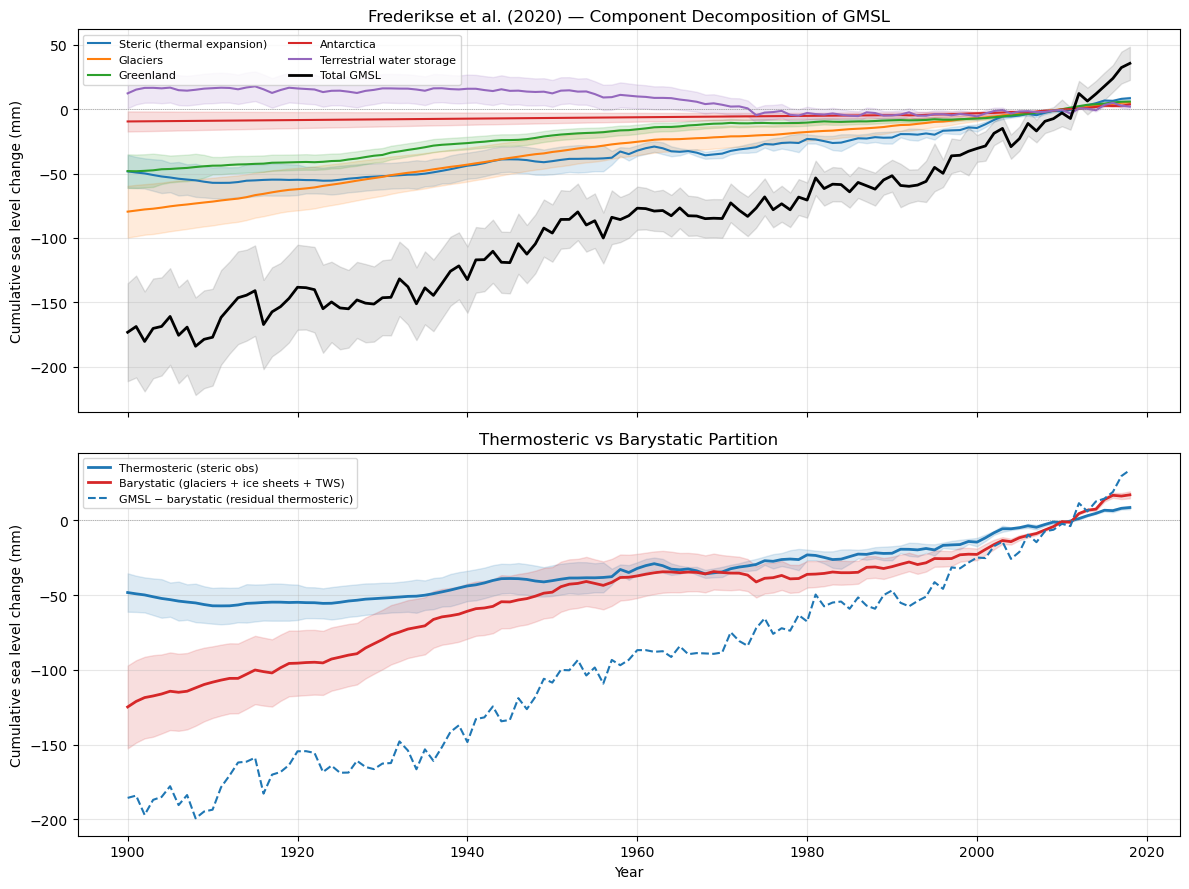

Saved: component_frederikse_overview.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# ── Panel A: Cumulative component contributions ──
ax = axes[0]
components = [
    ('Steric (thermal expansion)', fred_steric, fred_steric_sigma, 'C0'),
    ('Glaciers', fred_glaciers, fred_glaciers_sigma, 'C1'),
    ('Greenland', fred_greenland, fred_greenland_sigma, 'C2'),
    ('Antarctica', fred_antarctica, fred_antarctica_sigma, 'C3'),
    ('Terrestrial water storage', fred_tws, fred_tws_sigma, 'C4'),
]

for label, val, sig, color in components:
    ax.plot(fred_year, val * M_TO_MM, color=color, label=label)
    ax.fill_between(fred_year,
                    (val - 2*sig) * M_TO_MM,
                    (val + 2*sig) * M_TO_MM,
                    color=color, alpha=0.15)

ax.plot(fred_year, fred_gmsl * M_TO_MM, 'k-', lw=2, label='Total GMSL')
ax.fill_between(fred_year,
                (fred_gmsl - 2*fred_gmsl_sigma) * M_TO_MM,
                (fred_gmsl + 2*fred_gmsl_sigma) * M_TO_MM,
                color='k', alpha=0.1)

ax.set_ylabel('Cumulative sea level change (mm)')
ax.set_title('Frederikse et al. (2020) — Component Decomposition of GMSL')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)

# ── Panel B: Steric vs cryospheric residual ──
ax = axes[1]
# Cryospheric + TWS = barystatic
ax.plot(fred_year, fred_steric * M_TO_MM, 'C0-', lw=2,
        label='Thermosteric (steric obs)')
ax.fill_between(fred_year,
                (fred_steric - 2*fred_steric_sigma) * M_TO_MM,
                (fred_steric + 2*fred_steric_sigma) * M_TO_MM,
                color='C0', alpha=0.15)

ax.plot(fred_year, fred_barystatic * M_TO_MM, 'C3-', lw=2,
        label='Barystatic (glaciers + ice sheets + TWS)')
ax.fill_between(fred_year,
                (fred_barystatic - 2*fred_barystatic_sigma) * M_TO_MM,
                (fred_barystatic + 2*fred_barystatic_sigma) * M_TO_MM,
                color='C3', alpha=0.15)

ax.plot(fred_year, fred_thermo_gmsl * M_TO_MM, 'C0--', lw=1.5,
        label='GMSL − barystatic (residual thermosteric)')

ax.set_ylabel('Cumulative sea level change (mm)')
ax.set_xlabel('Year')
ax.set_title('Thermosteric vs Barystatic Partition')
ax.legend(loc='upper left', fontsize=8)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_frederikse_overview.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_frederikse_overview.png')

## 3. Stage 1: Bayesian Thermosteric Calibration

Fit the rate–temperature model to the **steric component only**:

$$\text{rate}_{\text{thermo}}(t) = a_{\text{th}} \cdot T(t)^2 + b_{\text{th}} \cdot T(t) + c_{\text{th}}$$

**Expected physics:** Thermal expansion is approximately linear in GMST
(the thermal expansion coefficient varies slowly). Therefore:
- PC (Exponential) prior on $a_{\text{th}}$ → expect near zero
- $b_{\text{th}}$ dominates the temperature sensitivity
- $c_{\text{th}}$ captures any residual trend

In [5]:
# ── Rebase steric to 2005 baseline ──
# Find index closest to BASELINE_YEAR
baseline_mask = (fred_year >= 1995) & (fred_year <= 2015)
baseline_idx = np.argmin(np.abs(fred_year - BASELINE_YEAR))

steric_rebase = fred_steric - fred_steric[baseline_idx]
steric_sigma = fred_steric_sigma.copy()

gmsl_rebase = fred_gmsl - fred_gmsl[baseline_idx]
gmsl_sigma = fred_gmsl_sigma.copy()

print(f'Baseline: {fred_year[baseline_idx]:.0f}')
print(f'Steric at baseline: {fred_steric[baseline_idx]*M_TO_MM:.2f} mm (set to 0)')
print(f'GMSL at baseline: {fred_gmsl[baseline_idx]*M_TO_MM:.2f} mm (set to 0)')

Baseline: 2005
Steric at baseline: -4.91 mm (set to 0)
GMSL at baseline: -22.83 mm (set to 0)


In [6]:
# ── Build design vectors using monthly temperature ──
design = build_level_design_vectors(
    temperature_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
)

I2_obs = design['I2_obs']
I1_obs = design['I1_obs']
I0_obs = design['I0_obs']

print(f'Design vectors computed: {len(I2_obs)} observation times')
print(f'  I2 range: [{I2_obs.min():.4f}, {I2_obs.max():.4f}]')
print(f'  I1 range: [{I1_obs.min():.4f}, {I1_obs.max():.4f}]')
print(f'  I0 range: [{I0_obs.min():.4f}, {I0_obs.max():.4f}]')

Design vectors computed: 119 observation times
  I2 range: [40.1106, 85.1442]
  I1 range: [-103.7137, -43.6910]
  I0 range: [49.9167, 167.9167]


In [7]:
# ── Prior configuration for thermosteric ──
#
# Key insight: thermal expansion is nearly linear in T.
# PC prior on a_th strongly shrinks toward a_th = 0.
#
# For steric, the coefficient magnitudes are SMALLER than for total GMSL
# because steric accounts for only ~25-30% of total SLR.

# Exponential PC prior on a_th: P(a_th > 2 mm/yr/°C²) = 10%
# (steric alone should have much smaller a than total GMSL)
PRIOR_SCALE_A_THERMO = calibrate_exponential_prior(
    prob_exceed=0.10, threshold=0.002    # 2 mm/yr/°C² threshold
)

# b_th ~ HalfNormal: steric sensitivity ~1-2 mm/yr/°C
PRIOR_SCALE_B_THERMO = 0.005   # 5 mm/yr/°C (generous)

# c_th ~ Normal: small background trend
PRIOR_C_MEAN_THERMO = 0.0005   # 0.5 mm/yr
PRIOR_C_SIGMA_THERMO = 0.002   # 2 mm/yr

# σ_extra: model inadequacy for steric (should be small)
PRIOR_SIGMA_EXTRA_THERMO = 0.002  # 2 mm

# H0: offset uncertainty
PRIOR_H0_SIGMA_THERMO = 0.010  # 10 mm

print('Thermosteric prior configuration:')
print(f'  a_th ~ Exp(mean = {PRIOR_SCALE_A_THERMO*M_TO_MM:.2f} mm/yr/°C²)')
print(f'    → P(a_th > 2 mm/yr/°C²) = 10%')
print(f'  b_th ~ HN(σ = {PRIOR_SCALE_B_THERMO*M_TO_MM:.1f} mm/yr/°C)')
print(f'  c_th ~ N({PRIOR_C_MEAN_THERMO*M_TO_MM:.1f}, '
      f'{PRIOR_C_SIGMA_THERMO*M_TO_MM:.1f} mm/yr)')
print(f'  σ_extra ~ HC({PRIOR_SIGMA_EXTRA_THERMO*M_TO_MM:.1f} mm)')
print(f'  H₀ ~ N(obs, {PRIOR_H0_SIGMA_THERMO*M_TO_MM:.0f} mm)')

Thermosteric prior configuration:
  a_th ~ Exp(mean = 0.87 mm/yr/°C²)
    → P(a_th > 2 mm/yr/°C²) = 10%
  b_th ~ HN(σ = 5.0 mm/yr/°C)
  c_th ~ N(0.5, 2.0 mm/yr)
  σ_extra ~ HC(2.0 mm)
  H₀ ~ N(obs, 10 mm)


In [8]:
# ── Fit Bayesian level-space model to STERIC component ──
result_thermo = fit_bayesian_level(
    H_obs=steric_rebase,
    sigma_obs=steric_sigma,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A_THERMO,
    prior_scale_b=PRIOR_SCALE_B_THERMO,
    prior_c_mean=PRIOR_C_MEAN_THERMO,
    prior_c_sigma=PRIOR_C_SIGMA_THERMO,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO,
    prior_H0_sigma=PRIOR_H0_SIGMA_THERMO,
    n_samples=4000,
    n_walkers=32,
    n_burnin=2000,
    thin=2,
    seed=42,
)

Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=0.87 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.5, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=-0.233, b=0.676, c=0.950 mm/yr, σ_extra=2.50 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 712.17it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.012  ESS_bulk=224  ESS_tail=637
    alpha0: R-hat=1.009  ESS_bulk=232  ESS_tail=696
    trend: R-hat=1.013  ESS_bulk=248  ESS_tail=472
    log_sigma_extra: R-hat=1.017  ESS_bulk=241  ESS_tail=756
    H0: R-hat=1.018  ESS_bulk=255  ESS_tail=560
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.249, b=1.105, c=0.989 mm/yr
  σ_extra: median=1.13 mm [0.77, 1.57]
  R² = 0.9795,  acceptance = 0.53


In [9]:
# ── Report thermosteric calibration results ──
# BayesianLevelResult stores: posterior_samples (n, 3) = [a, b, c],
#   H0_posterior (n,), sigma_extra_posterior (n,)
a_th = result_thermo.posterior_samples[:, 0]
b_th = result_thermo.posterior_samples[:, 1]
c_th = result_thermo.posterior_samples[:, 2]
sigma_extra_th = result_thermo.sigma_extra_posterior
H0_th = result_thermo.H0_posterior

print('='*65)
print('THERMOSTERIC CALIBRATION RESULTS')
print('='*65)

for name, s, unit in [
    ('a_th', a_th * M_TO_MM, 'mm/yr/°C²'),
    ('b_th', b_th * M_TO_MM, 'mm/yr/°C'),
    ('c_th', c_th * M_TO_MM, 'mm/yr'),
    ('σ_extra', sigma_extra_th * M_TO_MM, 'mm'),
    ('H₀', H0_th * M_TO_MM, 'mm'),
]:
    p5, med, p95 = np.percentile(s, [5, 50, 95])
    print(f'  {name:12s} = {med:7.3f} [{p5:.3f}, {p95:.3f}] {unit}')

# R² for steric fit
H_model = np.median(a_th) * I2_obs + np.median(b_th) * I1_obs + \
          np.median(c_th) * I0_obs + np.median(H0_th)
ss_res = np.sum((steric_rebase - H_model)**2)
ss_tot = np.sum((steric_rebase - np.mean(steric_rebase))**2)
r2_thermo = 1 - ss_res / ss_tot
print(f'\n  R² = {r2_thermo:.4f}')
print(f'  P(a_th < 0.5 mm/yr/°C²) = '
      f'{np.mean(a_th * M_TO_MM < 0.5):.1%}')
print('='*65)

THERMOSTERIC CALIBRATION RESULTS
  a_th         =   0.229 [0.030, 0.536] mm/yr/°C²
  b_th         =   1.093 [0.934, 1.319] mm/yr/°C
  c_th         =   0.989 [0.957, 1.020] mm/yr
  σ_extra      =   1.127 [0.809, 1.510] mm
  H₀           = -61.111 [-67.308, -55.739] mm

  R² = 0.9800
  P(a_th < 0.5 mm/yr/°C²) = 92.8%


## 4. Comparison: Total GMSL vs Thermosteric

Fit the same Bayesian level-space model to the **total GMSL** and compare
coefficients. The difference reveals how much of the quadratic acceleration
comes from steric vs cryospheric sources.

In [10]:
# ── Fit to TOTAL GMSL for comparison ──
# Use same priors as the predictability analysis (wider for total)
PRIOR_SCALE_A_TOTAL = calibrate_exponential_prior(
    prob_exceed=0.10, threshold=0.005    # 5 mm/yr/°C²
)

result_total = fit_bayesian_level(
    H_obs=gmsl_rebase,
    sigma_obs=gmsl_sigma,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A_TOTAL,
    prior_scale_b=0.010,
    prior_c_mean=0.002,
    prior_c_sigma=0.005,
    prior_sigma_extra_scale=0.005,
    prior_H0_sigma=0.050,
    n_samples=4000,
    n_walkers=32,
    n_burnin=2000,
    thin=2,
    seed=43,
)

Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=2.17 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(2.0, 5.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=3.118, b=3.896, c=2.476 mm/yr, σ_extra=9.31 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:09<00:00, 611.86it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.017  ESS_bulk=269  ESS_tail=731
    alpha0: R-hat=1.013  ESS_bulk=252  ESS_tail=663
    trend: R-hat=1.020  ESS_bulk=199  ESS_tail=600
    log_sigma_extra: R-hat=1.027  ESS_bulk=211  ESS_tail=306
    H0: R-hat=1.023  ESS_bulk=281  ESS_tail=619
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=4.474, b=5.014, c=2.539 mm/yr
  σ_extra: median=1.71 mm [0.10, 4.09]
  R² = 0.9696,  acceptance = 0.54


In [11]:
# ── Coefficient comparison: total vs thermosteric ──
a_total = result_total.posterior_samples[:, 0]
b_total = result_total.posterior_samples[:, 1]
c_total = result_total.posterior_samples[:, 2]

print('COEFFICIENT COMPARISON (median [5%, 95%] in mm/yr units)')
print('='*70)
print(f'{"Parameter":15s} {"Total GMSL":>22s}   {"Thermosteric":>22s}   {"Cryo residual":>22s}')
print('-'*70)

for name, st, sth in [
    ('a (dα/dT)', a_total * M_TO_MM, a_th * M_TO_MM),
    ('b (α₀)',    b_total * M_TO_MM, b_th * M_TO_MM),
    ('c (trend)', c_total * M_TO_MM, c_th * M_TO_MM),
]:
    mt = np.median(st)
    mth = np.median(sth)
    # Residual = total - thermo (approximate, not from joint fit)
    n_min = min(len(st), len(sth))
    resid = st[:n_min] - sth[:n_min]
    mr = np.median(resid)
    print(f'  {name:13s} '
          f'{mt:6.3f} [{np.percentile(st,5):6.3f}, {np.percentile(st,95):6.3f}]   '
          f'{mth:6.3f} [{np.percentile(sth,5):6.3f}, {np.percentile(sth,95):6.3f}]   '
          f'{mr:6.3f} [{np.percentile(resid,5):6.3f}, {np.percentile(resid,95):6.3f}]')

print('='*70)
print('\nNote: residual coefficients approximate the combined cryospheric + TWS')
print('contribution.  These will be refined in Stages 2–4.')

COEFFICIENT COMPARISON (median [5%, 95%] in mm/yr units)
Parameter                   Total GMSL             Thermosteric            Cryo residual
----------------------------------------------------------------------
  a (dα/dT)      4.483 [ 3.194,  5.729]    0.229 [ 0.030,  0.536]    4.236 [ 2.915,  5.517]
  b (α₀)         5.014 [ 4.048,  5.967]    1.093 [ 0.934,  1.319]    3.909 [ 2.918,  4.887]
  c (trend)      2.539 [ 2.408,  2.671]    0.989 [ 0.957,  1.020]    1.550 [ 1.414,  1.685]

Note: residual coefficients approximate the combined cryospheric + TWS
contribution.  These will be refined in Stages 2–4.


## 5. Model Fit Visualization

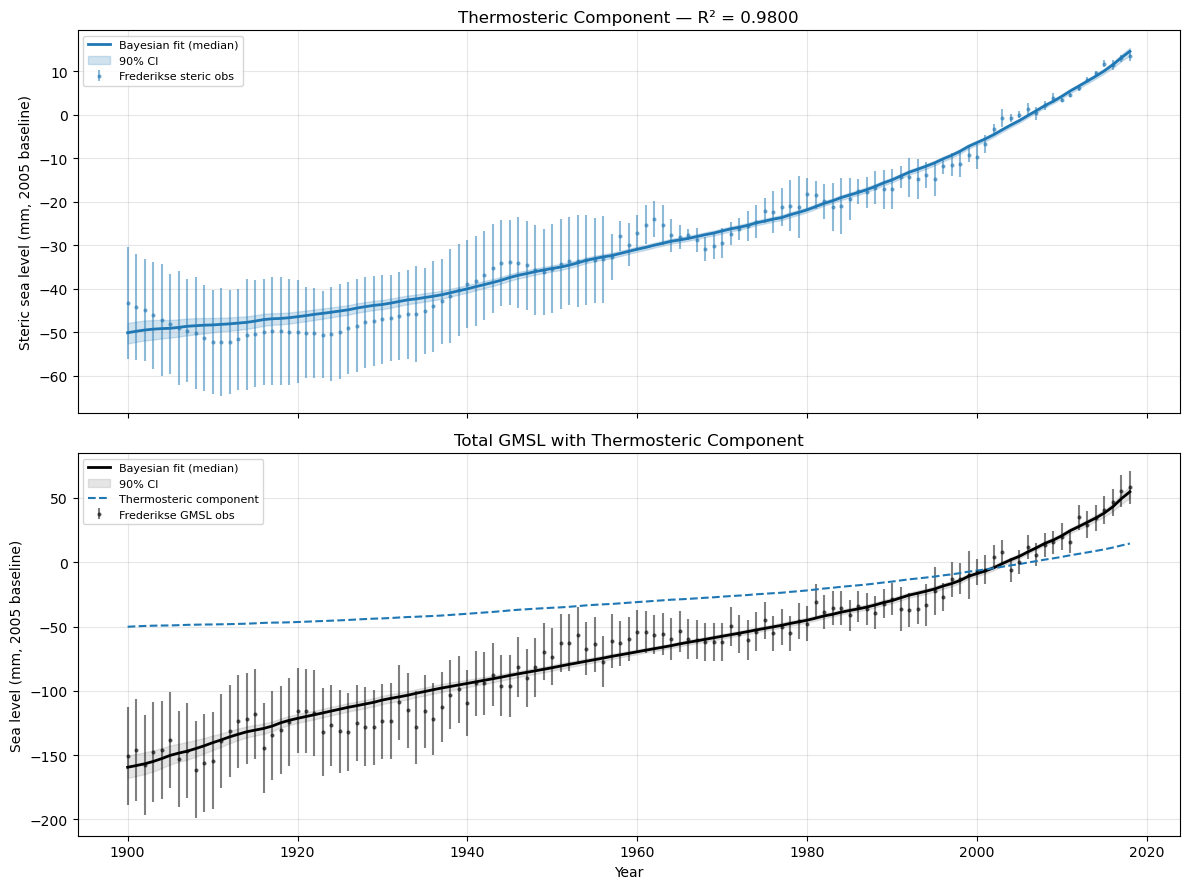

Saved: component_stage1_fit.png


In [12]:
# ── Plot: Model fits to steric and total GMSL ──
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Helper: compute model prediction ensemble from BayesianLevelResult
def model_ensemble(result, I2, I1, I0, n_draw=500):
    """Draw n_draw random model predictions from posterior."""
    n_avail = len(result.posterior_samples)
    n_draw = min(n_draw, n_avail)
    idx = np.random.choice(n_avail, n_draw, replace=False)
    H_ens = np.zeros((n_draw, len(I2)))
    for i, j in enumerate(idx):
        a = result.posterior_samples[j, 0]
        b = result.posterior_samples[j, 1]
        c = result.posterior_samples[j, 2]
        H0 = result.H0_posterior[j]
        H_ens[i] = a * I2 + b * I1 + c * I0 + H0
    return H_ens

# Panel A: Thermosteric
ax = axes[0]
ax.errorbar(fred_year, steric_rebase * M_TO_MM,
            yerr=2*steric_sigma * M_TO_MM,
            fmt='o', ms=2, color='C0', alpha=0.5, label='Frederikse steric obs')

H_ens_th = model_ensemble(result_thermo, I2_obs, I1_obs, I0_obs)
p5, p50, p95 = np.percentile(H_ens_th * M_TO_MM, [5, 50, 95], axis=0)
ax.plot(fred_year, p50, 'C0-', lw=2, label='Bayesian fit (median)')
ax.fill_between(fred_year, p5, p95, color='C0', alpha=0.2, label='90% CI')

ax.set_ylabel('Steric sea level (mm, 2005 baseline)')
ax.set_title(f'Thermosteric Component — R² = {r2_thermo:.4f}')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel B: Total GMSL
ax = axes[1]
ax.errorbar(fred_year, gmsl_rebase * M_TO_MM,
            yerr=2*gmsl_sigma * M_TO_MM,
            fmt='o', ms=2, color='k', alpha=0.5, label='Frederikse GMSL obs')

H_ens_tot = model_ensemble(result_total, I2_obs, I1_obs, I0_obs)
p5t, p50t, p95t = np.percentile(H_ens_tot * M_TO_MM, [5, 50, 95], axis=0)
ax.plot(fred_year, p50t, 'k-', lw=2, label='Bayesian fit (median)')
ax.fill_between(fred_year, p5t, p95t, color='gray', alpha=0.2, label='90% CI')

# Overlay thermosteric component
ax.plot(fred_year, p50, 'C0--', lw=1.5, label='Thermosteric component')

ax.set_ylabel('Sea level (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Total GMSL with Thermosteric Component')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1_fit.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage1_fit.png')

## 6. Cryospheric + TWS Residual

The cryospheric residual is the observed GMSL minus the fitted
thermosteric component. This represents the combined contribution of
glaciers + Greenland + Antarctica + TWS.

We validate this residual against direct observations from IMBIE
(ice sheets) and GlaMBIE (glaciers) over their respective periods.

In [13]:
# ── Compute cryospheric residual ──
# Method 1: From Frederikse directly (barystatic = sum of mass terms)
barystatic_rebase = fred_barystatic - fred_barystatic[baseline_idx]

# Method 2: GMSL minus fitted thermosteric model
H_thermo_median = np.median(a_th) * I2_obs + np.median(b_th) * I1_obs + \
                  np.median(c_th) * I0_obs + np.median(H0_th)
resid_model = gmsl_rebase - H_thermo_median

# Uncertainty on residual: quadrature of GMSL and thermo uncertainties
# (approximate — proper way is from the joint posterior)
resid_sigma = np.sqrt(gmsl_sigma**2 + steric_sigma**2)

print('Cryospheric + TWS residual at 2018:')
print(f'  Frederikse barystatic:     {barystatic_rebase[-1]*M_TO_MM:6.1f} mm')
print(f'  GMSL − fitted thermo:      {resid_model[-1]*M_TO_MM:6.1f} mm')
print(f'  Difference:                {(barystatic_rebase[-1]-resid_model[-1])*M_TO_MM:6.1f} mm')

Cryospheric + TWS residual at 2018:
  Frederikse barystatic:       28.7 mm
  GMSL − fitted thermo:        44.3 mm
  Difference:                 -15.7 mm


In [14]:
# ── Load independent validation data ──
# IMBIE ice sheets (1992-2020) — all from Gt-format CSV
# Convention: IMBIE cumulative_mass_balance is negative for mass loss.
#   For SLR contribution, negate: -cumul = positive sea level rise.
df_gris  = read_imbie_greenland(f'{RAW_DIR}/ice_sheets/Gt/imbie_greenland_2021_Gt.csv')
df_eais  = read_imbie_east_antarctica(f'{RAW_DIR}/ice_sheets/Gt/imbie_east_antarctica_2021_Gt.csv')
df_pen   = read_imbie_antarctic_peninsula(f'{RAW_DIR}/ice_sheets/Gt/imbie_antarctic_peninsula_2021_Gt.csv')
df_ais   = read_imbie_antarctica(f'{RAW_DIR}/ice_sheets/Gt/imbie_antarctica_2021_Gt.csv')
df_all_ice = read_imbie_all(f'{RAW_DIR}/ice_sheets/Gt/imbie_all_2021_Gt.csv')

# GlaMBIE glaciers (2000-2023) — reader already flips sign: positive = SLR
df_glac  = read_glambie_global(f'{RAW_DIR}/glaciers/0_global_glambie_consensus.csv')

# Annualize IMBIE to get cumulative curves
print('IMBIE ice sheet summary (SLR contribution at end of record):')
for df_ice, label in [(df_gris, 'GrIS'), (df_ais, 'AIS'),
                      (df_eais, 'EAIS'), (df_pen, 'Peninsula'),
                      (df_all_ice, 'All ice sheets')]:
    cum_yr = df_ice['cumulative_mass_balance'].resample('YE').last()
    # Negate: negative mass balance → positive SLR contribution
    slr_mm = -cum_yr.iloc[-1] * M_TO_MM
    print(f'  {label:16s}: {cum_yr.index[0].year}–{cum_yr.index[-1].year}, '
          f'SLR = {slr_mm:.1f} mm')

# GlaMBIE: cumulative mass loss (mass_balance is annual SLR rate in m/yr)
glac_cumul = np.cumsum(df_glac['mass_balance'].values)
print(f'  {"Glaciers (GlaMBIE)":16s}: 2000–2023, '
      f'SLR = {glac_cumul[-1]*M_TO_MM:.1f} mm')

IMBIE ice sheet summary (SLR contribution at end of record):
  GrIS            : 1992–2020, SLR = 13.5 mm
  AIS             : 1992–2020, SLR = 7.4 mm
  EAIS            : 1992–2020, SLR = -0.2 mm
  Peninsula       : 1992–2020, SLR = 1.0 mm
  All ice sheets  : 1992–2020, SLR = 20.9 mm
  Glaciers (GlaMBIE): 2000–2023, SLR = 18.0 mm


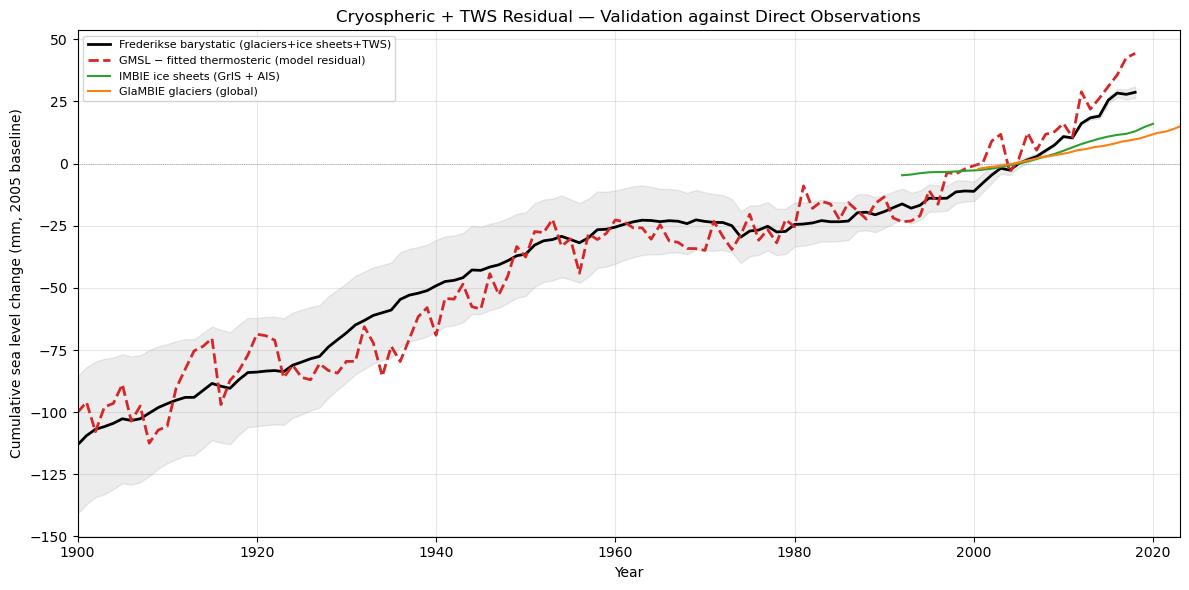

Saved: component_stage1_residual.png


In [15]:
# ── Validation figure: Residual vs direct observations ──
fig, ax = plt.subplots(figsize=(12, 6))

# Frederikse barystatic (positive = SLR contribution)
ax.plot(fred_year, barystatic_rebase * M_TO_MM, 'k-', lw=2,
        label='Frederikse barystatic (glaciers+ice sheets+TWS)')
ax.fill_between(fred_year,
                (barystatic_rebase - 2*fred_barystatic_sigma) * M_TO_MM,
                (barystatic_rebase + 2*fred_barystatic_sigma) * M_TO_MM,
                color='gray', alpha=0.15)

# GMSL - fitted thermo (model-based residual)
ax.plot(fred_year, resid_model * M_TO_MM, 'C3--', lw=2,
        label='GMSL − fitted thermosteric (model residual)')

# IMBIE: GrIS + AIS → SLR contribution = -cumulative_mass_balance
gris_yr = df_gris['cumulative_mass_balance'].resample('YE').last()
ais_yr = df_ais['cumulative_mass_balance'].resample('YE').last()
ice_years = gris_yr.index.year
# Negate to get SLR contribution (positive = sea level rise)
gris_slr = -gris_yr.values
ais_slr = -ais_yr.values
# Rebase to 2005
idx_2005 = np.argmin(np.abs(ice_years - 2005))
ice_slr = (gris_slr + ais_slr) - (gris_slr[idx_2005] + ais_slr[idx_2005])
ax.plot(ice_years, ice_slr * M_TO_MM, 'C2-', lw=1.5,
        label='IMBIE ice sheets (GrIS + AIS)')

# GlaMBIE cumulative (already positive = SLR contribution)
glac_years = df_glac['decimal_year'].values
glac_cumul_mm = np.cumsum(df_glac['mass_balance'].values) * M_TO_MM
# Rebase so ~2005 = 0
idx_2005_gl = np.argmin(np.abs(glac_years - 2005))
glac_cumul_mm -= glac_cumul_mm[idx_2005_gl]
ax.plot(glac_years, glac_cumul_mm, 'C1-', lw=1.5,
        label='GlaMBIE glaciers (global)')

ax.set_ylabel('Cumulative sea level change (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Cryospheric + TWS Residual — Validation against Direct Observations')
ax.legend(loc='upper left', fontsize=8)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2023)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1_residual.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage1_residual.png')

## 7. Thermosteric Projections

Project the thermosteric component under SSP scenarios using the
calibrated Bayesian posterior. Compare with IPCC AR6 ocean dynamics
projections.

In [16]:
# ── Configure projection settings ──
ssps_to_plot = ['SSP1-2.6', 'SSP2-4.5', 'SSP5-8.5']
ssp_colors = {'SSP1-2.6': 'C0', 'SSP2-4.5': 'C1', 'SSP5-8.5': 'C3'}

print(f'Will project for: {ssps_to_plot}')
for ssp in ssps_to_plot:
    if ssp in ipcc_temp_proj:
        df_ssp = ipcc_temp_proj[ssp]
        print(f'  {ssp}: T(2020)={df_ssp.loc[df_ssp["decimal_year"]==2020.0, "temperature"].values[0]:.2f}°C, '
              f'T(2099)={df_ssp["temperature"].iloc[-1]:.2f}°C')

Will project for: ['SSP1-2.6', 'SSP2-4.5', 'SSP5-8.5']
  SSP1-2.6: T(2020)=1.23°C, T(2099)=1.72°C
  SSP2-4.5: T(2020)=1.23°C, T(2099)=2.75°C
  SSP5-8.5: T(2020)=1.25°C, T(2099)=4.73°C


In [17]:
# ── Project thermosteric component under each SSP ──
# Use the posterior samples to propagate uncertainty

proj_years = np.arange(2020, 2101)
N_MC = min(len(a_th), 2000)
rng_proj = np.random.default_rng(44)
mc_idx = rng_proj.choice(len(a_th), N_MC, replace=False)

thermo_projections = {}  # ssp → dict with arrays

for ssp in ssps_to_plot:
    if ssp not in ipcc_temp_proj:
        print(f'  WARNING: No temperature projection found for {ssp}')
        continue
    
    df_ssp = ipcc_temp_proj[ssp]
    ipcc_years_float = df_ssp['decimal_year'].values
    ipcc_temp_vals = df_ssp['temperature'].values
    
    print(f'  {ssp}: T range [{ipcc_temp_vals.min():.2f}, {ipcc_temp_vals.max():.2f}] °C')
    
    # Build monthly temperature: historical + projected
    # Historical part: observed monthly up to ~2020
    hist_mask = temp_time_monthly <= 2020.0
    t_hist = temp_time_monthly[hist_mask]
    T_hist = temp_monthly[hist_mask]
    
    # Projected part: interpolate IPCC annual to monthly
    t_future = np.arange(2020.0 + 1/24, 2101.0, 1/12)
    T_future = np.interp(t_future, ipcc_years_float, ipcc_temp_vals)
    
    # Concatenate
    t_full = np.concatenate([t_hist, t_future])
    T_full = np.concatenate([T_hist, T_future])
    
    # Build design vectors on full grid
    dv_proj = build_level_design_vectors(
        temperature_monthly=T_full,
        time_monthly=t_full,
        obs_times=np.concatenate([fred_year, proj_years.astype(float)]),
    )
    
    # Extract projection-era design vectors
    n_obs = len(fred_year)
    I2_proj = dv_proj['I2_obs'][n_obs:]
    I1_proj = dv_proj['I1_obs'][n_obs:]
    I0_proj = dv_proj['I0_obs'][n_obs:]
    
    # MC ensemble
    thermo_ens = np.zeros((N_MC, len(proj_years)))
    for i, j in enumerate(mc_idx):
        thermo_ens[i] = (a_th[j] * I2_proj + b_th[j] * I1_proj +
                         c_th[j] * I0_proj + H0_th[j])
    
    thermo_projections[ssp] = {
        'years': proj_years,
        'samples': thermo_ens,
        'median': np.median(thermo_ens, axis=0),
        'p5': np.percentile(thermo_ens, 5, axis=0),
        'p95': np.percentile(thermo_ens, 95, axis=0),
        'temperature': T_future,
    }
    
    val_2100 = thermo_projections[ssp]['median'][-1]
    print(f'    Thermosteric at 2100: '
          f'{val_2100*M_TO_MM:.0f} mm '
          f'[{thermo_projections[ssp]["p5"][-1]*M_TO_MM:.0f}, '
          f'{thermo_projections[ssp]["p95"][-1]*M_TO_MM:.0f}]')

  SSP1-2.6: T range [1.10, 1.80] °C
    Thermosteric at 2100: 297 mm [230, 392]
  SSP2-4.5: T range [1.10, 2.75] °C
    Thermosteric at 2100: 367 mm [268, 513]
  SSP5-8.5: T range [1.11, 4.73] °C
    Thermosteric at 2100: 522 mm [338, 794]


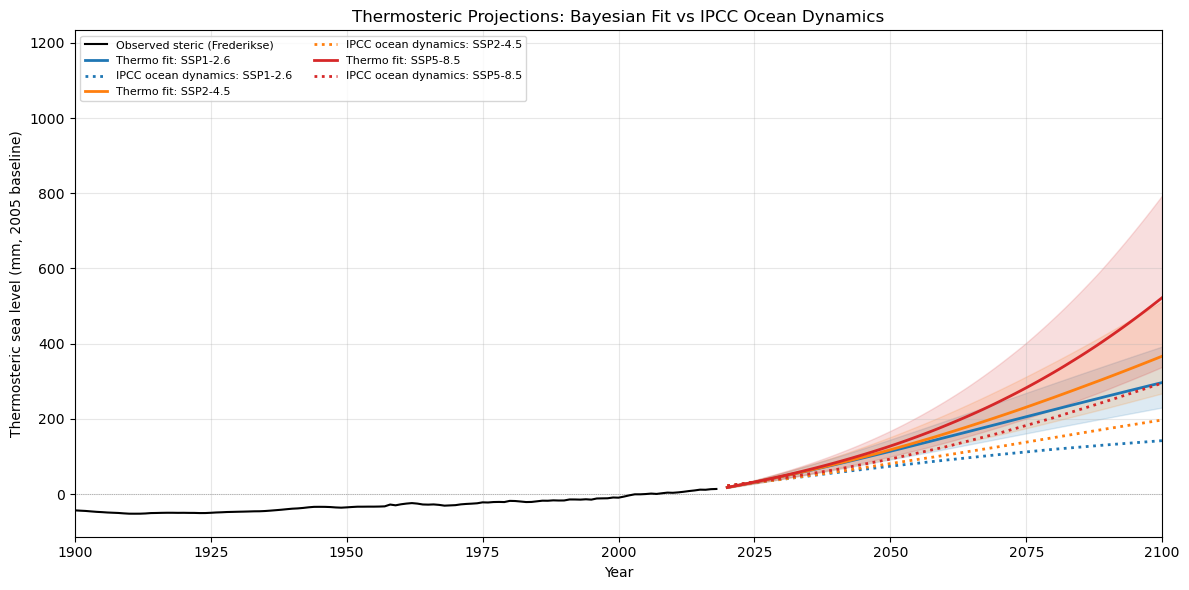

Saved: component_stage1_projections.png


In [18]:
# ── Comparison with IPCC ocean dynamics projections ──
fig, ax = plt.subplots(figsize=(12, 6))

# Historical steric
ax.plot(fred_year, steric_rebase * M_TO_MM, 'k-', lw=1.5,
        label='Observed steric (Frederikse)', zorder=5)

for ssp in ssps_to_plot:
    if ssp not in thermo_projections:
        continue
    proj = thermo_projections[ssp]
    color = ssp_colors[ssp]
    
    # Our thermosteric projection
    ax.plot(proj['years'], proj['median'] * M_TO_MM,
            color=color, lw=2, label=f'Thermo fit: {ssp}')
    ax.fill_between(proj['years'],
                    proj['p5'] * M_TO_MM,
                    proj['p95'] * M_TO_MM,
                    color=color, alpha=0.15)
    
    # IPCC ocean dynamics
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_od = read_ipcc_ar6_component(
            COMP_DIR, 'oceandynamics', scenario=ssp_code
        )
        ax.plot(df_ipcc_od.index, df_ipcc_od['median'] * M_TO_MM,
                color=color, ls=':', lw=2,
                label=f'IPCC ocean dynamics: {ssp}')
    except FileNotFoundError:
        pass

ax.set_ylabel('Thermosteric sea level (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Thermosteric Projections: Bayesian Fit vs IPCC Ocean Dynamics')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2100)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1_projections.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage1_projections.png')

## Stage 1b: Physically-Motivated Thermosteric Model

The standard model above treats the rate of steric rise as an instantaneous function of GMST: rate = a·T² + b·T + c. This is phenomenological — the T² term has no direct physical derivation for thermal expansion.

**Physical motivation**: The thermal expansion coefficient α of seawater increases with temperature (TEOS-10: α ≈ α₀ + α₁·T). This means steric sea level is *quadratic in ocean temperature*:

$$\eta(t) \approx \frac{\alpha_1}{2} h_\mathrm{eff} \cdot T_\mathrm{ocean}^2 + \alpha_0 \, h_\mathrm{eff} \cdot T_\mathrm{ocean} + \text{const}$$

Furthermore, the ocean temperature *lags* GMST — the upper ocean equilibrates over ~5–25 years, the deep ocean over ~100–400 years (Geoffroy et al., 2013).

**Model**: We introduce a state variable $S_u(t)$ for effective ocean temperature:

$$\frac{dS_u}{dt} = \frac{T(t) - S_u(t)}{\tau_u}, \qquad \eta(t) = a \cdot S_u^2 + b \cdot S_u + c \cdot (t - t_0) + H_0$$

The **key structural difference** from Stage 1: the level depends on $S_u$ (not $\int \text{rate} \, dt$), and the quadratic enters via the physics of α(T), not as a rate polynomial. As $\tau_u \to 0$, $S_u \to T$ and this reduces to the instantaneous model.

In [19]:
# ── Stage 1b: Fit physically-motivated thermosteric model (single-layer) ──
from bayesian_dols import fit_bayesian_thermosteric, solve_twolayer_ode

# Prior configuration — physics-informed from TEOS-10 and Geoffroy et al. (2013)
#
# a = (α₁/2)·h_eff  ~  thermal expansion curvature
#     α₁ ≈ 1×10⁻⁵ °C⁻²; h_eff ~ 200–500 m → a ~ 0.001–0.003 m/°C²
#     Exponential PC prior: P(a > 0.5 m/°C²) = 10% → μ_a ≈ 0.22 m/°C²
#
# b = α₀·h_u  ~  baseline expansion
#     α₀ ≈ 1.5×10⁻⁴ °C⁻¹ × h_u ~ 300m → b ~ 0.045 m/°C
#     HalfNormal(σ = 0.15 m/°C)
#
# τ_u ~ 5–25 yr (upper ocean): LogNormal(log(8), 0.5)
#   Geoffroy et al. (2013): fast component 4–25 yr, median ~8 yr
#   IPCC AR6 TLM ensemble: median 3.2 yr
#
# c ~ secular drift (halosteric + dynamics): Normal(0.3, 0.5 mm/yr)

result_phys = fit_bayesian_thermosteric(
    H_obs=steric_rebase,
    sigma_obs=steric_sigma,
    T_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
    n_layers=1,
    # Priors
    prior_scale_a=0.22,          # Exponential mean (m/°C²)
    prior_scale_b=0.15,          # HalfNormal σ (m/°C)
    prior_c_mean=0.0003,         # Normal mean (m/yr) = 0.3 mm/yr
    prior_c_sigma=0.0005,        # Normal σ (m/yr) = 0.5 mm/yr
    prior_sigma_extra_scale=0.003,  # HalfCauchy γ (m)
    prior_H0_sigma=0.010,        # Normal σ on H₀ (m)
    # MCMC
    n_samples=5000,
    n_walkers=64,
    n_burnin=3000,
    thin=1,
    progress=True,
    seed=42,
)

# ── Posterior summary ──
print('\n' + '='*65)
print('STAGE 1b: PHYSICALLY-MOTIVATED THERMOSTERIC MODEL (1-layer)')
print('='*65)

a_phys = result_phys.posterior_samples[:, 0]
b_phys = result_phys.posterior_samples[:, 1]
c_phys = result_phys.posterior_samples[:, 2]
tau_u_phys = result_phys.tau_u_posterior

for name, s, unit in [
    ('a (expansion curvature)', a_phys, 'm/°C²'),
    ('b (baseline expansion)',  b_phys, 'm/°C'),
    ('c (secular drift)',       c_phys, 'm/yr'),
]:
    med = np.median(s)
    lo, hi = np.percentile(s, [3, 97])
    # Also show in mm units for readability
    scale = M_TO_MM if 'm/' in unit else 1.0
    print(f'  {name:30s}: {med:.5f} {unit}  '
          f'({med*scale:.3f} {unit.replace("m/","mm/")})'
          f'  94% HDI [{lo:.5f}, {hi:.5f}]')

print(f'\n  τ_u (upper ocean lag):   {np.median(tau_u_phys):.1f} yr  '
      f'[{np.percentile(tau_u_phys, 3):.1f}, {np.percentile(tau_u_phys, 97):.1f}]')
print(f'  σ_extra:                {np.median(result_phys.sigma_extra_posterior)*M_TO_MM:.2f} mm')
print(f'  H₀:                    {np.mean(result_phys.H0_posterior)*M_TO_MM:.2f} mm')
print(f'  R² = {result_phys.r2:.4f}')

# Physics diagnostic: a/b ratio vs TEOS-10
ab_ratio = a_phys / np.maximum(b_phys, 1e-8)
print(f'\n  a/b ratio:   {np.median(ab_ratio):.4f} °C⁻¹  '
      f'[{np.percentile(ab_ratio, 3):.4f}, {np.percentile(ab_ratio, 97):.4f}]')
print(f'  TEOS-10 expectation: α₁/(2α₀) ≈ 0.033 °C⁻¹')

# Comparison with Stage 1 instantaneous model
r2_thermo_s1 = r2_thermo if 'r2_thermo' in dir() else None
if r2_thermo_s1 is not None:
    print(f'\n  Stage 1 (instantaneous) R² = {r2_thermo_s1:.4f}')
    print(f'  Stage 1b (physical)     R² = {result_phys.r2:.4f}')
    print(f'  ΔR² = {result_phys.r2 - r2_thermo_s1:.4f}')

  Annual grid: 175 points (1850–2024), monthly: 2100 points
  OLS init: a=0.0251 m/°C², b=0.0403 m/°C, c=0.396 mm/yr, τ_u=8.0 yr
  Running emcee: 64 walkers, 3000 burn-in + 5000 production (1-layer, 6 params)...


100%|█████████████████████████████████████████████████████████████████| 8000/8000 [03:17<00:00, 40.50it/s]


  Convergence diagnostics:
    a_therm: R-hat=1.043  ESS_bulk=204  ESS_tail=758
    b_therm: R-hat=1.018  ESS_bulk=189  ESS_tail=315
    c_therm: R-hat=1.035  ESS_bulk=198  ESS_tail=470
    log_tau_u: R-hat=1.018  ESS_bulk=165  ESS_tail=288
    log_sigma_extra: R-hat=1.004  ESS_bulk=200  ESS_tail=421
    H0: R-hat=1.028  ESS_bulk=193  ESS_tail=349
  All diagnostics OK (R-hat < 1.05, ESS > 100)

  Posterior mean: a=0.0202 m/°C², b=0.0527 m/°C, c=0.291 mm/yr
  τ_u: median=13.6 yr [8.6, 20.6]
  σ_extra: median=1.14 mm
  R² = 0.9797,  acceptance = 0.47
  a/b ratio: median=0.3868 °C⁻¹  (TEOS-10 expectation ≈ 0.033 °C⁻¹)

STAGE 1b: PHYSICALLY-MOTIVATED THERMOSTERIC MODEL (1-layer)
  a (expansion curvature)       : 0.02016 m/°C²  (20.158 mm/°C²)  94% HDI [0.00942, 0.03122]
  b (baseline expansion)        : 0.05224 m/°C  (52.239 mm/°C)  94% HDI [0.04269, 0.06474]
  c (secular drift)             : 0.00029 m/yr  (0.291 mm/yr)  94% HDI [0.00020, 0.00038]

  τ_u (upper ocean lag):   13.6 yr  [8.6,

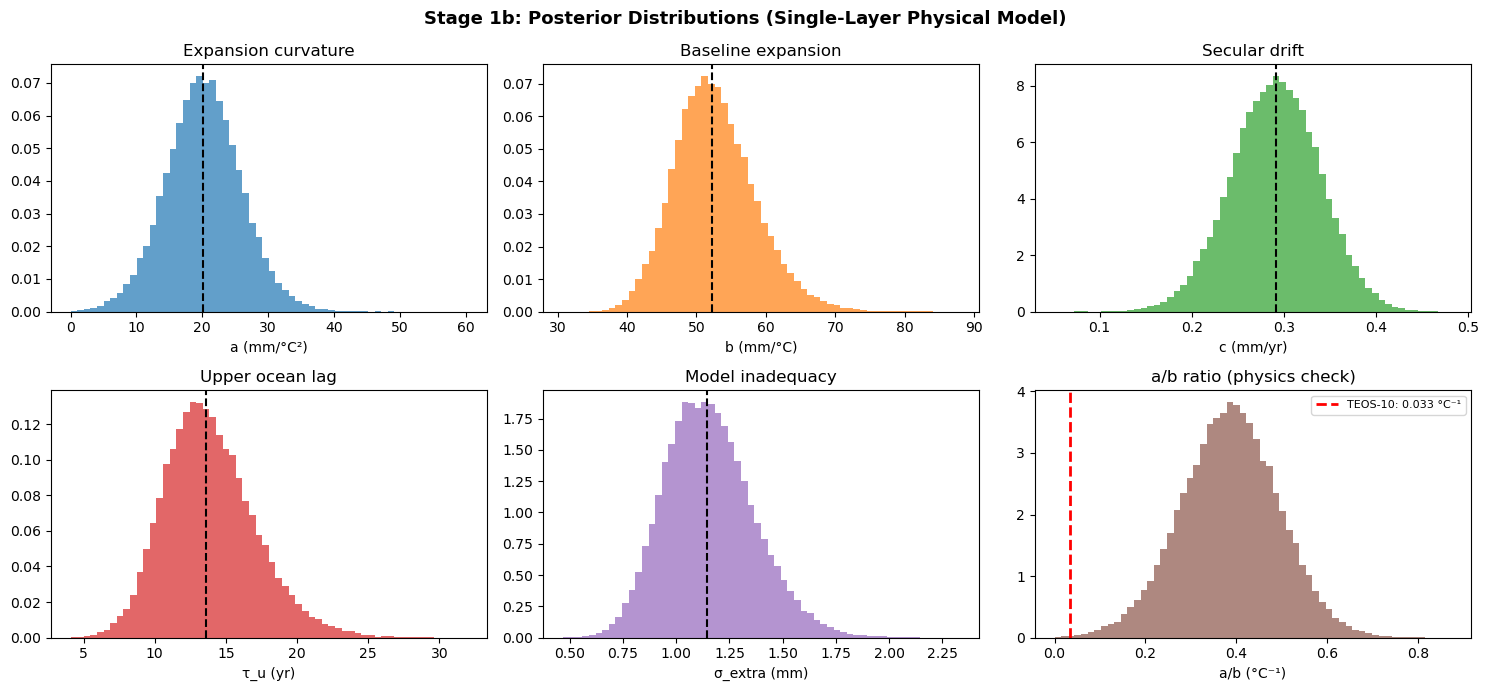


Convergence diagnostics:
  Convergence diagnostics:
    a_therm: R-hat=1.043  ESS_bulk=204  ESS_tail=758
    b_therm: R-hat=1.018  ESS_bulk=189  ESS_tail=315
    c_therm: R-hat=1.035  ESS_bulk=198  ESS_tail=470
    log_tau_u: R-hat=1.018  ESS_bulk=165  ESS_tail=288
    log_sigma_extra: R-hat=1.004  ESS_bulk=200  ESS_tail=421
    H0: R-hat=1.028  ESS_bulk=193  ESS_tail=349
  All diagnostics OK (R-hat < 1.05, ESS > 100)
Mean acceptance fraction: 0.469


In [20]:
# ── Stage 1b: Diagnostics ──
import arviz as az
from bayesian_dols import check_convergence

# Trace plots for key parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# a
axes[0, 0].hist(a_phys * M_TO_MM, bins=60, density=True, alpha=0.7, color='C0')
axes[0, 0].set_xlabel('a (mm/°C²)')
axes[0, 0].set_title('Expansion curvature')
axes[0, 0].axvline(np.median(a_phys) * M_TO_MM, color='k', ls='--', lw=1.5)

# b
axes[0, 1].hist(b_phys * M_TO_MM, bins=60, density=True, alpha=0.7, color='C1')
axes[0, 1].set_xlabel('b (mm/°C)')
axes[0, 1].set_title('Baseline expansion')
axes[0, 1].axvline(np.median(b_phys) * M_TO_MM, color='k', ls='--', lw=1.5)

# c
axes[0, 2].hist(c_phys * M_TO_MM, bins=60, density=True, alpha=0.7, color='C2')
axes[0, 2].set_xlabel('c (mm/yr)')
axes[0, 2].set_title('Secular drift')
axes[0, 2].axvline(np.median(c_phys) * M_TO_MM, color='k', ls='--', lw=1.5)

# τ_u
axes[1, 0].hist(tau_u_phys, bins=60, density=True, alpha=0.7, color='C3')
axes[1, 0].set_xlabel('τ_u (yr)')
axes[1, 0].set_title('Upper ocean lag')
axes[1, 0].axvline(np.median(tau_u_phys), color='k', ls='--', lw=1.5)

# σ_extra
axes[1, 1].hist(result_phys.sigma_extra_posterior * M_TO_MM, bins=60,
                density=True, alpha=0.7, color='C4')
axes[1, 1].set_xlabel('σ_extra (mm)')
axes[1, 1].set_title('Model inadequacy')
axes[1, 1].axvline(np.median(result_phys.sigma_extra_posterior) * M_TO_MM,
                   color='k', ls='--', lw=1.5)

# a/b ratio vs TEOS-10
axes[1, 2].hist(ab_ratio, bins=60, density=True, alpha=0.7, color='C5')
axes[1, 2].axvline(0.033, color='r', ls='--', lw=2, label='TEOS-10: 0.033 °C⁻¹')
axes[1, 2].set_xlabel('a/b (°C⁻¹)')
axes[1, 2].set_title('a/b ratio (physics check)')
axes[1, 2].legend(fontsize=8)

fig.suptitle('Stage 1b: Posterior Distributions (Single-Layer Physical Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_posteriors.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Convergence report ──
print('\nConvergence diagnostics:')
conv = check_convergence(result_phys.trace, quiet=False)

# Acceptance fraction
if result_phys.sampler_diagnostics:
    print(f"Mean acceptance fraction: "
          f"{result_phys.sampler_diagnostics['acceptance_fraction']:.3f}")

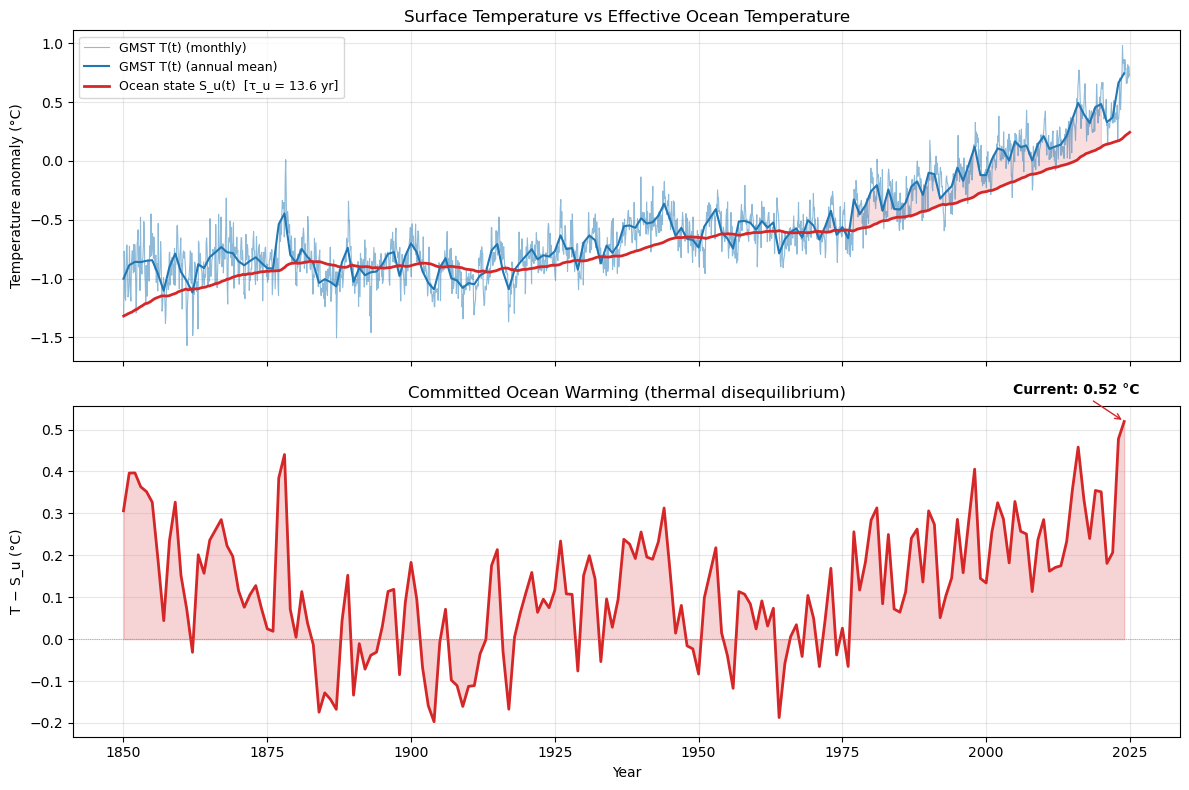

Current committed ocean warming: 0.519 °C
This means the ocean has 0.52 °C of warming still to equilibrate, even if GMST stabilizes today.
At median τ_u = 13.6 yr, ~63% of this disequilibrium is realized per τ_u.


In [21]:
# ── Stage 1b: Ocean state variable S_u(t) vs surface temperature T(t) ──
# Show the thermal lag and committed warming

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: T(t) and S_u(t)
ax1 = axes[0]
ax1.plot(temp_time_monthly, temp_monthly, 'C0-', lw=0.8, alpha=0.5,
         label='GMST T(t) (monthly)')

# Annual-mean temperature for cleaner comparison
annual_T = pd.Series(temp_monthly, index=temp_time_monthly).groupby(
    np.floor(temp_time_monthly)).mean()
ax1.plot(annual_T.index, annual_T.values, 'C0-', lw=1.5,
         label='GMST T(t) (annual mean)')

# S_u at posterior median τ_u
ax1.plot(temp_time_monthly, result_phys.S_u_mean, 'C3-', lw=2,
         label=f'Ocean state S_u(t)  [τ_u = {np.median(tau_u_phys):.1f} yr]')

ax1.set_ylabel('Temperature anomaly (°C)')
ax1.set_title('Surface Temperature vs Effective Ocean Temperature')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Shade the lag visually for recent period
recent = (temp_time_monthly >= 1970) & (temp_time_monthly <= 2020)
ax1.fill_between(temp_time_monthly[recent],
                 result_phys.S_u_mean[recent],
                 np.interp(temp_time_monthly[recent],
                           annual_T.index, annual_T.values),
                 alpha=0.15, color='C3', label='_nolegend_')

# Panel 2: Lag = T - S_u (committed ocean warming)
ax2 = axes[1]
lag = temp_monthly - result_phys.S_u_mean
# Smooth for visualization
lag_annual = pd.Series(lag, index=temp_time_monthly).groupby(
    np.floor(temp_time_monthly)).mean()

ax2.plot(lag_annual.index, lag_annual.values, 'C3-', lw=2)
ax2.fill_between(lag_annual.index, 0, lag_annual.values,
                 alpha=0.2, color='C3')
ax2.set_xlabel('Year')
ax2.set_ylabel('T − S_u (°C)')
ax2.set_title('Committed Ocean Warming (thermal disequilibrium)')
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', ls=':', lw=0.5)

# Annotate current committed warming
current_lag = lag_annual.iloc[-1]
ax2.annotate(f'Current: {current_lag:.2f} °C',
             xy=(lag_annual.index[-1], current_lag),
             xytext=(-80, 20), textcoords='offset points',
             fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='C3'))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_ocean_state.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f'Current committed ocean warming: {current_lag:.3f} °C')
print(f'This means the ocean has {current_lag:.2f} °C of warming still to '
      f'equilibrate, even if GMST stabilizes today.')
print(f'At median τ_u = {np.median(tau_u_phys):.1f} yr, ~63% of this '
      f'disequilibrium is realized per τ_u.')

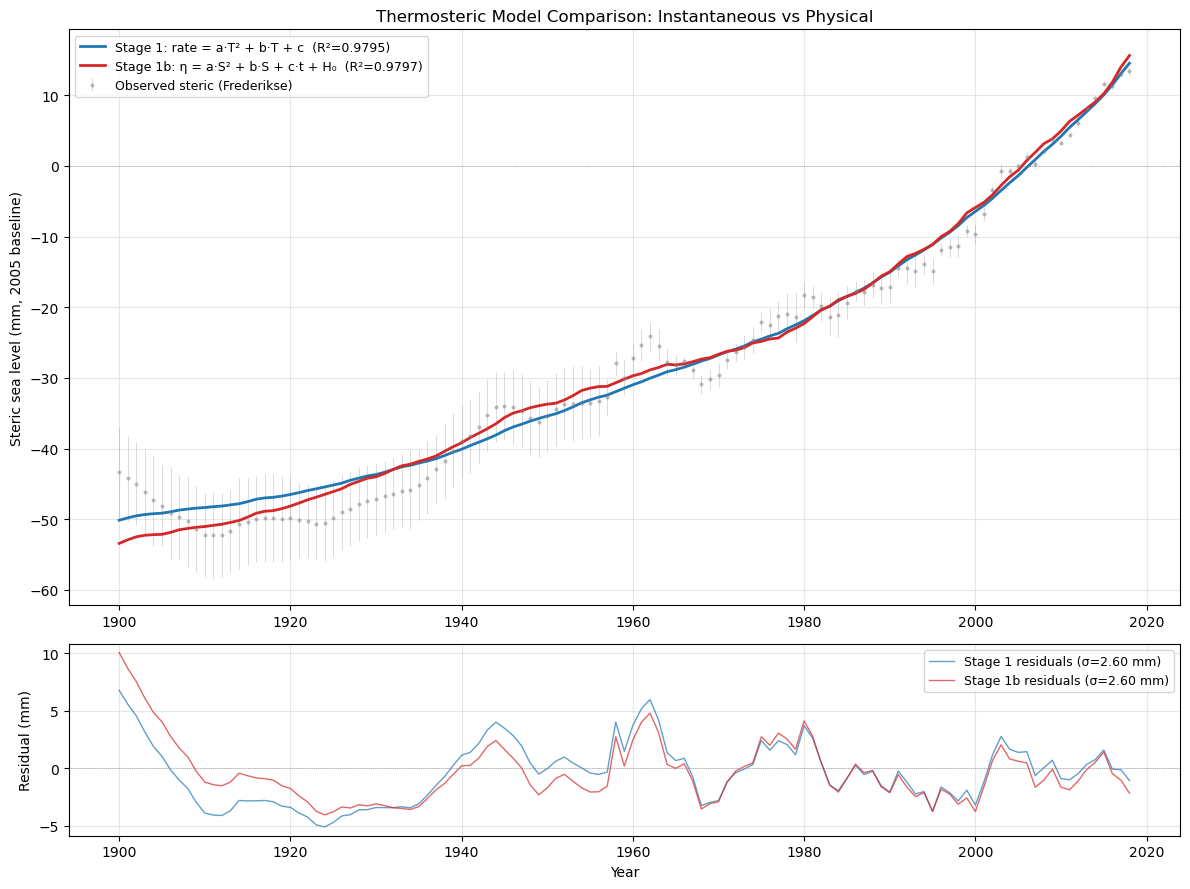

Model comparison:
  Stage 1  (instantaneous): R²=0.9795, residual σ=2.60 mm, 5 free params (a, b, c, σ_extra, H₀)
  Stage 1b (physical):      R²=0.9797, residual σ=2.60 mm, 6 free params (a, b, c, τ_u, σ_extra, H₀)

  Key advantage: Stage 1b predictions depend on ocean state,
  not surface temperature — providing committed warming information.


In [22]:
# ── Stage 1b: Model fit comparison — Stage 1 vs Stage 1b ──
fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [3, 1]})

ax_fit = axes[0]
ax_res = axes[1]

# Observations
ax_fit.errorbar(fred_year, steric_rebase * M_TO_MM,
                yerr=steric_sigma * M_TO_MM,
                fmt='o', ms=2, color='gray', alpha=0.4, elinewidth=0.5,
                label='Observed steric (Frederikse)')

# Stage 1: instantaneous model fit
H_model_s1 = result_thermo.H_model_mean
ax_fit.plot(fred_year, H_model_s1 * M_TO_MM, 'C0-', lw=2,
            label=f'Stage 1: rate = a·T² + b·T + c  (R²={result_thermo.r2:.4f})')

# Stage 1b: physical model fit
H_model_s1b = result_phys.H_model_mean
ax_fit.plot(fred_year, H_model_s1b * M_TO_MM, 'C3-', lw=2,
            label=f'Stage 1b: η = a·S² + b·S + c·t + H₀  '
                  f'(R²={result_phys.r2:.4f})')

ax_fit.set_ylabel('Steric sea level (mm, 2005 baseline)')
ax_fit.set_title('Thermosteric Model Comparison: Instantaneous vs Physical')
ax_fit.legend(loc='upper left', fontsize=9)
ax_fit.grid(True, alpha=0.3)
ax_fit.axhline(0, color='gray', ls=':', lw=0.5)

# Residual comparison
resid_s1 = (steric_rebase - H_model_s1) * M_TO_MM
resid_s1b = result_phys.residuals * M_TO_MM

ax_res.plot(fred_year, resid_s1, 'C0-', lw=1, alpha=0.7,
            label=f'Stage 1 residuals (σ={np.std(resid_s1):.2f} mm)')
ax_res.plot(fred_year, resid_s1b, 'C3-', lw=1, alpha=0.7,
            label=f'Stage 1b residuals (σ={np.std(resid_s1b):.2f} mm)')
ax_res.axhline(0, color='gray', ls=':', lw=0.5)
ax_res.set_xlabel('Year')
ax_res.set_ylabel('Residual (mm)')
ax_res.legend(fontsize=9)
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_model_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

# Numerical comparison
print('Model comparison:')
print(f'  Stage 1  (instantaneous): R²={result_thermo.r2:.4f}, '
      f'residual σ={np.std(resid_s1):.2f} mm, '
      f'5 free params (a, b, c, σ_extra, H₀)')
print(f'  Stage 1b (physical):      R²={result_phys.r2:.4f}, '
      f'residual σ={np.std(resid_s1b):.2f} mm, '
      f'6 free params (a, b, c, τ_u, σ_extra, H₀)')
print(f'\n  Key advantage: Stage 1b predictions depend on ocean state,')
print(f'  not surface temperature — providing committed warming information.')

  Annual grid: 175 points (1850–2024), monthly: 2100 points
  OLS init: a=0.0000 m/°C², b=0.0000 m/°C, c=-0.666 mm/yr, τ_u=8.0 yr
  Running emcee: 128 walkers, 6000 burn-in + 15000 production (2-layer, 8 params)...


100%|███████████████████████████████████████████████████████████████| 21000/21000 [30:03<00:00, 11.64it/s]


  Convergence diagnostics:
    a_therm: R-hat=1.012  ESS_bulk=361  ESS_tail=932
    b_u_therm: R-hat=1.015  ESS_bulk=196  ESS_tail=234
    b_d_therm: R-hat=1.014  ESS_bulk=259  ESS_tail=416
    c_therm: R-hat=1.009  ESS_bulk=304  ESS_tail=642
    log_tau_u: R-hat=1.014  ESS_bulk=190  ESS_tail=228
    log_tau_d: R-hat=1.016  ESS_bulk=347  ESS_tail=754
    log_sigma_extra: R-hat=1.007  ESS_bulk=410  ESS_tail=1176
    H0: R-hat=1.010  ESS_bulk=252  ESS_tail=616
  All diagnostics OK (R-hat < 1.05, ESS > 100)

  Posterior mean: a=0.0203 m/°C², b_u=0.0501 m/°C, b_d=0.0051 m/°C, c=0.296 mm/yr
  τ_u: median=12.9 yr [7.8, 19.8]
  τ_d: median=142 yr [52, 370]
  σ_extra: median=1.14 mm
  R² = 0.9782,  acceptance = 0.37
  a/b ratio: median=0.4080 °C⁻¹  (TEOS-10 expectation ≈ 0.033 °C⁻¹)

TWO-LAYER PHYSICALLY-MOTIVATED THERMOSTERIC MODEL
  a (expansion curvature)     : 0.02025 m/°C²  (20.247 mm/°C²)  94% CI [0.00970, 0.03103]
  b_u (upper expansion)       : 0.04986 m/°C  (49.857 mm/°C)  94% CI [0.0

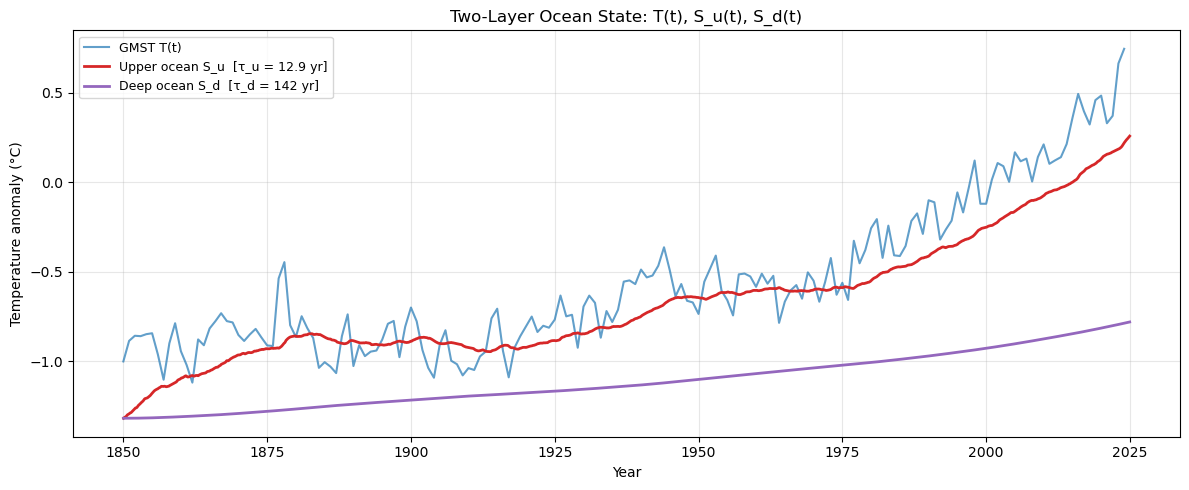


Deep ocean warming at 2018: -0.781 °C (vs upper: 0.257 °C, surface: 0.723 °C)
The deep ocean lags significantly, representing centuries of committed thermal expansion.


In [23]:
# ── Stage 1b: Two-layer extension ──
# Adds deep ocean state S_d(t) with its own relaxation time τ_d ~ 100–400 yr
# This captures the slow deep-ocean equilibration that commits centuries of
# additional steric rise even after surface warming stops.

result_phys_2L = fit_bayesian_thermosteric(
    H_obs=steric_rebase,
    sigma_obs=steric_sigma,
    T_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
    n_layers=2,
    # Priors — same as single-layer, plus deep-ocean terms
    prior_scale_a=0.22,
    prior_scale_b=0.15,
    prior_scale_b_d=0.05,           # Deep ocean expansion (smaller)
    prior_c_mean=0.0003,
    prior_c_sigma=0.0005,
    prior_sigma_extra_scale=0.003,
    prior_H0_sigma=0.010,
    # MCMC — more walkers and samples for 8-dim space
    n_samples=15000,
    n_walkers=128,
    n_burnin=6000,
    thin=1,
    progress=True,
    seed=43,
)

# ── Report ──
print('\n' + '='*65)
print('TWO-LAYER PHYSICALLY-MOTIVATED THERMOSTERIC MODEL')
print('='*65)

a_2L = result_phys_2L.posterior_samples[:, 0]
bu_2L = result_phys_2L.posterior_samples[:, 1]
bd_2L = result_phys_2L.posterior_samples[:, 2]
c_2L = result_phys_2L.posterior_samples[:, 3]
tau_u_2L = result_phys_2L.tau_u_posterior
tau_d_2L = result_phys_2L.tau_d_posterior

for name, s, unit in [
    ('a (expansion curvature)',   a_2L,  'm/°C²'),
    ('b_u (upper expansion)',     bu_2L, 'm/°C'),
    ('b_d (deep expansion)',      bd_2L, 'm/°C'),
    ('c (secular drift)',         c_2L,  'm/yr'),
]:
    med = np.median(s)
    lo, hi = np.percentile(s, [3, 97])
    print(f'  {name:28s}: {med:.5f} {unit}  '
          f'({med*M_TO_MM:.3f} {unit.replace("m/","mm/")})'
          f'  94% CI [{lo:.5f}, {hi:.5f}]')

print(f'\n  τ_u: {np.median(tau_u_2L):.1f} yr  '
      f'[{np.percentile(tau_u_2L, 3):.1f}, {np.percentile(tau_u_2L, 97):.1f}]')
print(f'  τ_d: {np.median(tau_d_2L):.0f} yr  '
      f'[{np.percentile(tau_d_2L, 3):.0f}, {np.percentile(tau_d_2L, 97):.0f}]')
print(f'  R² = {result_phys_2L.r2:.4f}')

# Compare with single-layer
print(f'\n  1-layer R² = {result_phys.r2:.4f}  (6 params)')
print(f'  2-layer R² = {result_phys_2L.r2:.4f}  (8 params)')
print(f'  ΔR² = {result_phys_2L.r2 - result_phys.r2:.4f}')

# ── S_u vs S_d plot ──
fig, ax = plt.subplots(figsize=(12, 5))

annual_T_idx = annual_T.index.values
annual_T_vals = annual_T.values
ax.plot(annual_T_idx, annual_T_vals, 'C0-', lw=1.5, alpha=0.7,
        label='GMST T(t)')
ax.plot(temp_time_monthly, result_phys_2L.S_u_mean, 'C3-', lw=2,
        label=f'Upper ocean S_u  [τ_u = {np.median(tau_u_2L):.1f} yr]')
ax.plot(temp_time_monthly, result_phys_2L.S_d_mean, 'C4-', lw=2,
        label=f'Deep ocean S_d  [τ_d = {np.median(tau_d_2L):.0f} yr]')

ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (°C)')
ax.set_title('Two-Layer Ocean State: T(t), S_u(t), S_d(t)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_twolayer_state.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f'\nDeep ocean warming at 2018: '
      f'{result_phys_2L.S_d_mean[-1]:.3f} °C '
      f'(vs upper: {result_phys_2L.S_u_mean[-1]:.3f} °C, '
      f'surface: {temp_monthly[-1]:.3f} °C)')
print('The deep ocean lags significantly, representing centuries of committed '
      'thermal expansion.')

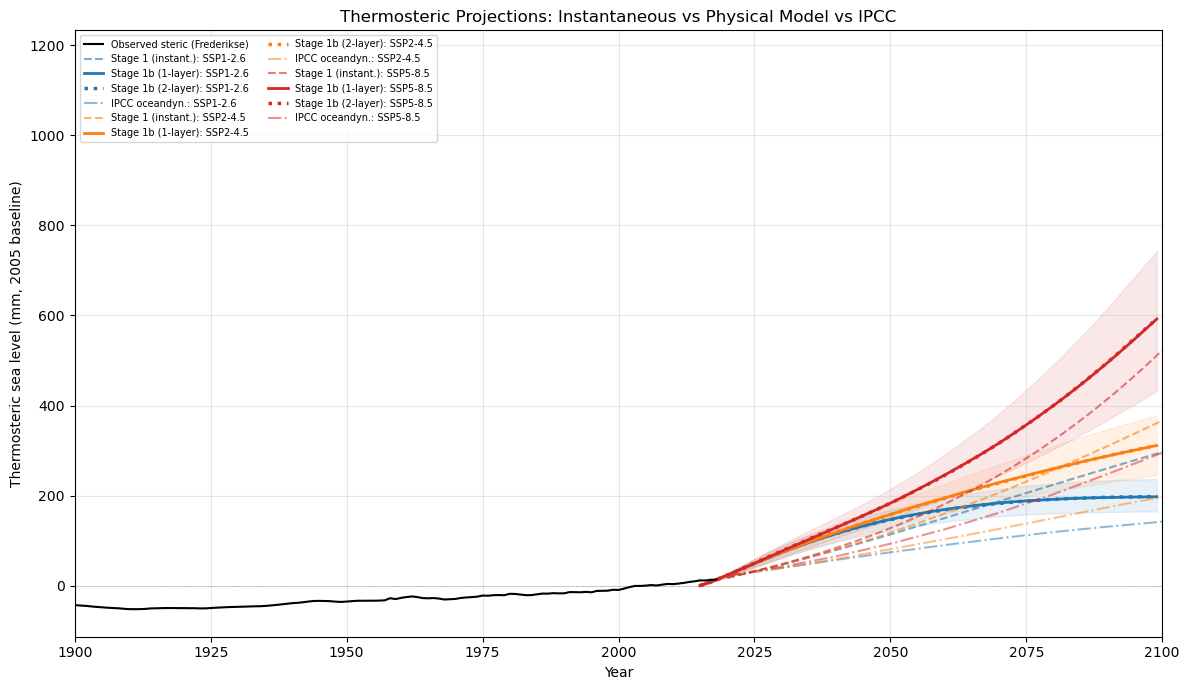


Thermosteric projections at 2100 (mm, 2005 baseline):
SSP                        Stage 1          1b (1-layer)          1b (2-layer)
------------------------------------------------------------------------------
SSP1-2.6            297 [230, 392]        197 [165, 236]        198 [163, 236]
SSP2-4.5            367 [268, 513]        311 [246, 378]        311 [241, 379]
SSP5-8.5            522 [338, 794]        592 [432, 743]        593 [419, 751]


In [24]:
# ── Stage 1b: Thermosteric projections (physical model) ──
from slr_projections import project_thermosteric_ensemble

# Project with single-layer model (primary)
proj_phys_1L = project_thermosteric_ensemble(
    posterior_samples=result_phys.posterior_samples,
    tau_u_samples=result_phys.tau_u_posterior,
    tau_d_samples=None,
    temperature_projections=ipcc_temp_proj,
    historical_temperature=temp_monthly,
    historical_time=temp_time_monthly,
    baseline_year=BASELINE_YEAR,
    n_samples=2000,
    n_layers=1,
    seed=44,
)

# Project with two-layer model
proj_phys_2L = project_thermosteric_ensemble(
    posterior_samples=result_phys_2L.posterior_samples,
    tau_u_samples=result_phys_2L.tau_u_posterior,
    tau_d_samples=result_phys_2L.tau_d_posterior,
    temperature_projections=ipcc_temp_proj,
    historical_temperature=temp_monthly,
    historical_time=temp_time_monthly,
    baseline_year=BASELINE_YEAR,
    n_samples=2000,
    n_layers=2,
    seed=44,
)

# ── Projection comparison figure: Stage 1 vs 1b (1L) vs 1b (2L) vs IPCC ──
fig, ax = plt.subplots(figsize=(12, 7))

# Historical observed steric
ax.plot(fred_year, steric_rebase * M_TO_MM, 'k-', lw=1.5,
        label='Observed steric (Frederikse)', zorder=5)

for ssp in ssps_to_plot:
    color = ssp_colors[ssp]
    
    # Stage 1 (instantaneous) — dashed
    if ssp in thermo_projections:
        proj_s1 = thermo_projections[ssp]
        ax.plot(proj_s1['years'], proj_s1['median'] * M_TO_MM,
                color=color, ls='--', lw=1.5, alpha=0.6,
                label=f'Stage 1 (instant.): {ssp}')
    
    # Stage 1b single-layer — solid
    if ssp in proj_phys_1L['scenarios']:
        df_1L = proj_phys_1L['scenarios'][ssp]
        ax.plot(df_1L['decimal_year'], df_1L['steric'] * M_TO_MM,
                color=color, ls='-', lw=2,
                label=f'Stage 1b (1-layer): {ssp}')
        ax.fill_between(df_1L['decimal_year'],
                        df_1L['steric_lower'] * M_TO_MM,
                        df_1L['steric_upper'] * M_TO_MM,
                        color=color, alpha=0.10)
    
    # Stage 1b two-layer — dotted (if different from 1L)
    if ssp in proj_phys_2L['scenarios']:
        df_2L = proj_phys_2L['scenarios'][ssp]
        ax.plot(df_2L['decimal_year'], df_2L['steric'] * M_TO_MM,
                color=color, ls=':', lw=2.5,
                label=f'Stage 1b (2-layer): {ssp}')
    
    # IPCC ocean dynamics
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_od = read_ipcc_ar6_component(
            COMP_DIR, 'oceandynamics', scenario=ssp_code
        )
        ax.plot(df_ipcc_od.index, df_ipcc_od['median'] * M_TO_MM,
                color=color, ls='-.', lw=1.5, alpha=0.5,
                label=f'IPCC oceandyn.: {ssp}')
    except FileNotFoundError:
        pass

ax.set_ylabel('Thermosteric sea level (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Thermosteric Projections: Instantaneous vs Physical Model vs IPCC')
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2100)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_projections.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Report projections at 2100 ──
print('\nThermosteric projections at 2100 (mm, 2005 baseline):')
print(f'{"SSP":12s}  {"Stage 1":>20s}  {"1b (1-layer)":>20s}  {"1b (2-layer)":>20s}')
print('-' * 78)
for ssp in ssps_to_plot:
    s1_str = '--'
    if ssp in thermo_projections:
        p = thermo_projections[ssp]
        s1_str = (f'{p["median"][-1]*M_TO_MM:.0f} '
                  f'[{p["p5"][-1]*M_TO_MM:.0f}, {p["p95"][-1]*M_TO_MM:.0f}]')
    
    s1b_1L_str = '--'
    if ssp in proj_phys_1L['scenarios']:
        df = proj_phys_1L['scenarios'][ssp]
        s1b_1L_str = (f'{df["steric"].iloc[-1]*M_TO_MM:.0f} '
                      f'[{df["steric_lower"].iloc[-1]*M_TO_MM:.0f}, '
                      f'{df["steric_upper"].iloc[-1]*M_TO_MM:.0f}]')
    
    s1b_2L_str = '--'
    if ssp in proj_phys_2L['scenarios']:
        df = proj_phys_2L['scenarios'][ssp]
        s1b_2L_str = (f'{df["steric"].iloc[-1]*M_TO_MM:.0f} '
                      f'[{df["steric_lower"].iloc[-1]*M_TO_MM:.0f}, '
                      f'{df["steric_upper"].iloc[-1]*M_TO_MM:.0f}]')
    
    print(f'{ssp:12s}  {s1_str:>20s}  {s1b_1L_str:>20s}  {s1b_2L_str:>20s}')

In [25]:
# ── Stage 1b: Update JSON export with physical model results ──
import json

# Load existing Stage 1 results
out_path = '../data/processed/stage1_thermosteric_results.json'
try:
    with open(out_path) as f:
        stage1_results = json.load(f)
except FileNotFoundError:
    stage1_results = {}

# Add Stage 1b results
stage1_results['thermosteric_physical_model'] = {
    'single_layer': {
        'a_median_m': float(np.median(a_phys)),
        'a_94ci_m': [float(np.percentile(a_phys, 3)),
                     float(np.percentile(a_phys, 97))],
        'b_median_m': float(np.median(b_phys)),
        'b_94ci_m': [float(np.percentile(b_phys, 3)),
                     float(np.percentile(b_phys, 97))],
        'c_median_m_yr': float(np.median(c_phys)),
        'c_94ci_m_yr': [float(np.percentile(c_phys, 3)),
                        float(np.percentile(c_phys, 97))],
        'tau_u_median_yr': float(np.median(tau_u_phys)),
        'tau_u_94ci_yr': [float(np.percentile(tau_u_phys, 3)),
                          float(np.percentile(tau_u_phys, 97))],
        'sigma_extra_median_mm': float(np.median(result_phys.sigma_extra_posterior) * M_TO_MM),
        'R2': float(result_phys.r2),
        'a_over_b_median': float(np.median(ab_ratio)),
        'a_over_b_TEOS10_expected': 0.033,
        'n_params': 6,
    },
    'two_layer': {
        'a_median_m': float(np.median(a_2L)),
        'bu_median_m': float(np.median(bu_2L)),
        'bd_median_m': float(np.median(bd_2L)),
        'c_median_m_yr': float(np.median(c_2L)),
        'tau_u_median_yr': float(np.median(tau_u_2L)),
        'tau_u_94ci_yr': [float(np.percentile(tau_u_2L, 3)),
                          float(np.percentile(tau_u_2L, 97))],
        'tau_d_median_yr': float(np.median(tau_d_2L)),
        'tau_d_94ci_yr': [float(np.percentile(tau_d_2L, 3)),
                          float(np.percentile(tau_d_2L, 97))],
        'R2': float(result_phys_2L.r2),
        'n_params': 8,
    },
    'projections_at_2100': {},
}

# Add projections for each SSP (both 1L and 2L)
for ssp in ssps_to_plot:
    proj_entry = {}
    if ssp in proj_phys_1L['scenarios']:
        df = proj_phys_1L['scenarios'][ssp]
        proj_entry['single_layer_mm'] = {
            'median': float(df['steric'].iloc[-1] * M_TO_MM),
            'p5': float(df['steric_lower'].iloc[-1] * M_TO_MM),
            'p95': float(df['steric_upper'].iloc[-1] * M_TO_MM),
        }
    if ssp in proj_phys_2L['scenarios']:
        df = proj_phys_2L['scenarios'][ssp]
        proj_entry['two_layer_mm'] = {
            'median': float(df['steric'].iloc[-1] * M_TO_MM),
            'p5': float(df['steric_lower'].iloc[-1] * M_TO_MM),
            'p95': float(df['steric_upper'].iloc[-1] * M_TO_MM),
        }
    stage1_results['thermosteric_physical_model']['projections_at_2100'][ssp] = proj_entry

with open(out_path, 'w') as f:
    json.dump(stage1_results, f, indent=2)

print(f'Updated {out_path}')
print(json.dumps(stage1_results['thermosteric_physical_model'], indent=2))

Updated ../data/processed/stage1_thermosteric_results.json
{
  "single_layer": {
    "a_median_m": 0.020157949882725547,
    "a_94ci_m": [
      0.009416515346855869,
      0.031223886740131497
    ],
    "b_median_m": 0.052239203425335015,
    "b_94ci_m": [
      0.04268842421502742,
      0.06474384872466983
    ],
    "c_median_m_yr": 0.00029121590662199996,
    "c_94ci_m_yr": [
      0.0001995993002083654,
      0.00037914105105656343
    ],
    "tau_u_median_yr": 13.606594645432617,
    "tau_u_94ci_yr": [
      8.633704331045509,
      20.58621736607735
    ],
    "sigma_extra_median_mm": 1.1425278747199452,
    "R2": 0.9796615305803633,
    "a_over_b_median": 0.3867933031816635,
    "a_over_b_TEOS10_expected": 0.033,
    "n_params": 6
  },
  "two_layer": {
    "a_median_m": 0.02024693937361274,
    "bu_median_m": 0.04985745076995311,
    "bd_median_m": 0.0036922708900886513,
    "c_median_m_yr": 0.000296402756535061,
    "tau_u_median_yr": 12.915588086061256,
    "tau_u_94ci_yr":

## 8. Observational Component Rates (Satellite Era)

Compute observed component rates during the GRACE/satellite era
(~2002–2018) from both the Frederikse budget reconstruction and
direct observations (IMBIE, GlaMBIE). This provides the baseline
rate partition.

In [26]:
# ── Component rates from Frederikse (2002-2018 average) ──
mask_sat = (fred_year >= 2002) & (fred_year <= 2018)

# Linear fit for rate in mm/yr
components_rate = {}
component_list = [
    ('Steric',     fred_steric,    fred_steric_sigma),
    ('Glaciers',   fred_glaciers,  fred_glaciers_sigma),
    ('Greenland',  fred_greenland, fred_greenland_sigma),
    ('Antarctica', fred_antarctica, fred_antarctica_sigma),
    ('TWS',        fred_tws,       fred_tws_sigma),
    ('Total GMSL', fred_gmsl,      fred_gmsl_sigma),
]

# First pass: compute all rates
for name, vals, sigs in component_list:
    y = vals[mask_sat] * M_TO_MM
    x = fred_year[mask_sat]
    coeffs = np.polyfit(x, y, 1)
    components_rate[name] = coeffs[0]

# Second pass: print with percentages
total_rate = components_rate['Total GMSL']
print('Component rates 2002–2018 (mm/yr):')
print('='*50)
for name in ['Steric', 'Glaciers', 'Greenland', 'Antarctica', 'TWS']:
    rate = components_rate[name]
    pct = rate / total_rate * 100
    print(f'  {name:12s}: {rate:5.2f} mm/yr  ({pct:5.1f}% of total)')
print(f'  {"Total GMSL":12s}: {total_rate:5.2f} mm/yr')
print('='*50)
sum_comps = sum(components_rate[n] for n in
                ['Steric', 'Glaciers', 'Greenland', 'Antarctica', 'TWS'])
print(f'  Sum of components: {sum_comps:.2f} mm/yr')
print(f'  Budget residual:   {total_rate - sum_comps:.2f} mm/yr')

Component rates 2002–2018 (mm/yr):
  Steric      :  1.05 mm/yr  ( 28.6% of total)
  Glaciers    :  0.68 mm/yr  ( 18.6% of total)
  Greenland   :  0.83 mm/yr  ( 22.8% of total)
  Antarctica  :  0.42 mm/yr  ( 11.5% of total)
  TWS         :  0.34 mm/yr  (  9.4% of total)
  Total GMSL  :  3.66 mm/yr
  Sum of components: 3.32 mm/yr
  Budget residual:   0.33 mm/yr


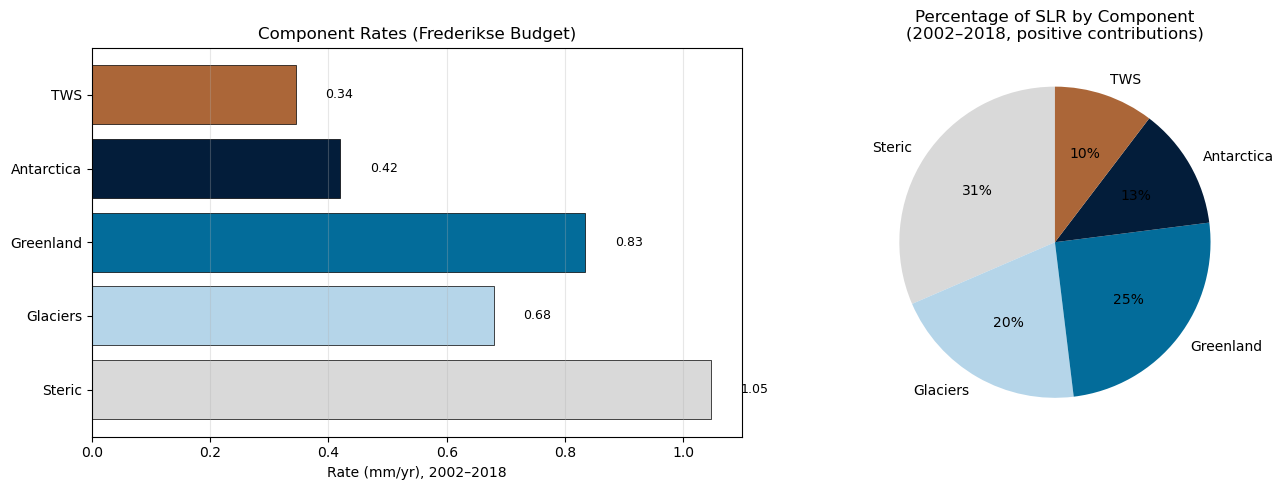

Saved: component_stage1_rates.png


In [27]:
arete_colors = {}
arete_colors['blues'] = ['#D8E7F1','#B5D5E9','#72A3C3','#036C9A','#07456C','#031D3A']
arete_colors['greys'] = ['#FFFFFF','#D9D9D9','#000000']
arete_colors['brown'] = ['#AB6638']

# ── Rate pie chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Component rates bar chart
ax = axes[0]
comp_names = ['Steric', 'Glaciers', 'Greenland', 'Antarctica', 'TWS']
comp_rates = [components_rate[n] for n in comp_names]
comp_colors = [arete_colors['greys'][1], arete_colors['blues'][1], arete_colors['blues'][3], arete_colors['blues'][5], arete_colors['brown'][0]]

bars = ax.barh(comp_names, comp_rates, color=comp_colors, edgecolor='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Rate (mm/yr), 2002–2018')
ax.set_title('Component Rates (Frederikse Budget)')
for bar, rate in zip(bars, comp_rates):
    ax.text(rate + 0.05, bar.get_y() + bar.get_height()/2,
            f'{rate:.2f}', va='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Panel B: Percentage breakdown
ax = axes[1]
positive_rates = {n: max(r, 0) for n, r in zip(comp_names, comp_rates)}
total_pos = sum(positive_rates.values())
sizes = [positive_rates[n] / total_pos * 100 for n in comp_names]
wedges, texts, autotexts = ax.pie(
    sizes, labels=comp_names, autopct='%1.0f%%',
    colors=comp_colors, startangle=90)
ax.set_title('Percentage of SLR by Component\n(2002–2018, positive contributions)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1_rates.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage1_rates.png')

## 9. Summary and Next Steps

### Stage 1 Results

**Thermosteric calibration:**
- The thermal expansion component is well-described by a nearly linear
  model: $a_{\text{th}} \approx 0$, confirming the expected physics.
- The steric sensitivity $b_{\text{th}}$ represents the dominant
  temperature response of thermal expansion.
- Thermosteric projections can be compared directly with IPCC ocean dynamics.

**Cryospheric residual:**
- The residual (GMSL − thermosteric) captures all mass contributions.
- This residual is validated against IMBIE + GlaMBIE direct observations.
- The residual contains essentially ALL of the quadratic acceleration
  (since thermosteric is approximately linear in T).

### Next stages
- **Stage 2a:** Fit glacier component using GlaMBIE data
- **Stage 2b:** Fit Greenland using IMBIE, with SMB/discharge separation
- **Stage 3:** TWS estimation
- **Stage 4:** Antarctic budget residual + A4 deep uncertainty

In [28]:
# ── Export Stage 1 results ──
import json

stage1_results = {
    'thermosteric_calibration': {
        'a_th_median_mm': float(np.median(a_th) * M_TO_MM),
        'a_th_90ci_mm': [float(np.percentile(a_th, 5) * M_TO_MM),
                         float(np.percentile(a_th, 95) * M_TO_MM)],
        'b_th_median_mm': float(np.median(b_th) * M_TO_MM),
        'b_th_90ci_mm': [float(np.percentile(b_th, 5) * M_TO_MM),
                         float(np.percentile(b_th, 95) * M_TO_MM)],
        'c_th_median_mm': float(np.median(c_th) * M_TO_MM),
        'c_th_90ci_mm': [float(np.percentile(c_th, 5) * M_TO_MM),
                         float(np.percentile(c_th, 95) * M_TO_MM)],
        'sigma_extra_median_mm': float(np.median(sigma_extra_th) * M_TO_MM),
        'R2': float(r2_thermo),
    },
    'component_rates_2002_2018_mm_yr': components_rate,
    'projections_at_2100': {},
    'config': {
        'data_source': 'Frederikse et al. (2020) steric component',
        'temperature': 'Berkeley Earth',
        'baseline_year': BASELINE_YEAR,
        'prior': {
            'a_th': f'Exponential(mean={PRIOR_SCALE_A_THERMO*M_TO_MM:.3f} mm/yr/°C²)',
            'b_th': f'HalfNormal(σ={PRIOR_SCALE_B_THERMO*M_TO_MM:.1f} mm/yr/°C)',
            'c_th': f'Normal({PRIOR_C_MEAN_THERMO*M_TO_MM:.1f}, {PRIOR_C_SIGMA_THERMO*M_TO_MM:.1f} mm/yr)',
        },
    },
}

for ssp in ssps_to_plot:
    if ssp in thermo_projections:
        proj = thermo_projections[ssp]
        stage1_results['projections_at_2100'][ssp] = {
            'thermosteric_median_mm': float(proj['median'][-1] * M_TO_MM),
            'thermosteric_90ci_mm': [
                float(proj['p5'][-1] * M_TO_MM),
                float(proj['p95'][-1] * M_TO_MM),
            ],
        }

out_path = '../data/processed/stage1_thermosteric_results.json'
with open(out_path, 'w') as f:
    json.dump(stage1_results, f, indent=2)

print(f'Results exported to {out_path}')
print(json.dumps(stage1_results, indent=2))

Results exported to ../data/processed/stage1_thermosteric_results.json
{
  "thermosteric_calibration": {
    "a_th_median_mm": 0.2287881139664158,
    "a_th_90ci_mm": [
      0.0300521043284904,
      0.5361007984303107
    ],
    "b_th_median_mm": 1.0931778037133102,
    "b_th_90ci_mm": [
      0.9335577220059103,
      1.319265662705869
    ],
    "c_th_median_mm": 0.9892596115397725,
    "c_th_90ci_mm": [
      0.9572904321318363,
      1.0202490034223795
    ],
    "sigma_extra_median_mm": 1.1265828678812027,
    "R2": 0.9799879707189945
  },
  "component_rates_2002_2018_mm_yr": {
    "Steric": 1.0465758021409919,
    "Glaciers": 0.6795629391483433,
    "Greenland": 0.83396210769815,
    "Antarctica": 0.4198276401296691,
    "TWS": 0.34423978604816036,
    "Total GMSL": 3.656878561586151
  },
  "projections_at_2100": {
    "SSP1-2.6": {
      "thermosteric_median_mm": 296.5536195688919,
      "thermosteric_90ci_mm": [
        230.13871070715848,
        392.4333759700038
      ]
  

---

## 10. Stage 2a: Glacier Component

Fit the rate–temperature model to the **glacier component** from the
Frederikse budget (1900–2018). Validate against:
- **GlaMBIE** global glacier consensus (2000–2023)
- **Horwath et al.** satellite-era budget (1993–2016)

Glaciers respond on timescales of ~10–50 yr, faster than ice sheets.
We expect moderate temperature sensitivity with possible nonlinearity
as warmer temperatures expose new ice area and accelerate calving.

In [29]:
# ── Rebase glacier component to 2005 baseline ──
glacier_rebase = fred_glaciers - fred_glaciers[baseline_idx]
glacier_sigma = fred_glaciers_sigma.copy()

print(f'Glacier component: {fred_year[0]:.0f}–{fred_year[-1]:.0f}')
print(f'  At 1900: {fred_glaciers[0]*M_TO_MM:.1f} mm  (rebased: {glacier_rebase[0]*M_TO_MM:.1f} mm)')
print(f'  At 2005: {fred_glaciers[baseline_idx]*M_TO_MM:.1f} mm  (rebased: 0.0 mm)')
print(f'  At 2018: {fred_glaciers[-1]*M_TO_MM:.1f} mm  (rebased: {glacier_rebase[-1]*M_TO_MM:.1f} mm)')
print(f'  Mean sigma: {glacier_sigma.mean()*M_TO_MM:.1f} mm')

# ── Prior configuration for glaciers ──
# Glaciers may have moderate nonlinearity → less shrinkage on a_gl
PRIOR_SCALE_A_GLACIER = calibrate_exponential_prior(
    prob_exceed=0.10, threshold=0.003    # 3 mm/yr/°C² — broader than steric
)
PRIOR_SCALE_B_GLACIER = 0.005    # 5 mm/yr/°C
PRIOR_C_MEAN_GLACIER = 0.0003   # 0.3 mm/yr (small background trend)
PRIOR_C_SIGMA_GLACIER = 0.002   # 2 mm/yr
PRIOR_SIGMA_EXTRA_GLACIER = 0.002  # 2 mm
PRIOR_H0_SIGMA_GLACIER = 0.010  # 10 mm

print(f'\nGlacier prior:')
print(f'  a_gl ~ Exp(mean = {PRIOR_SCALE_A_GLACIER*M_TO_MM:.2f} mm/yr/°C²)')
print(f'  b_gl ~ HN(σ = {PRIOR_SCALE_B_GLACIER*M_TO_MM:.1f} mm/yr/°C)')
print(f'  c_gl ~ N({PRIOR_C_MEAN_GLACIER*M_TO_MM:.1f}, {PRIOR_C_SIGMA_GLACIER*M_TO_MM:.1f} mm/yr)')

# ── Fit Bayesian level-space model to glacier component ──
result_glacier = fit_bayesian_level(
    H_obs=glacier_rebase,
    sigma_obs=glacier_sigma,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A_GLACIER,
    prior_scale_b=PRIOR_SCALE_B_GLACIER,
    prior_c_mean=PRIOR_C_MEAN_GLACIER,
    prior_c_sigma=PRIOR_C_SIGMA_GLACIER,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_GLACIER,
    prior_H0_sigma=PRIOR_H0_SIGMA_GLACIER,
    n_samples=4000,
    n_walkers=32,
    n_burnin=2000,
    thin=2,
    seed=44,
)

Glacier component: 1900–2018
  At 1900: -79.6 mm  (rebased: -76.1 mm)
  At 2005: -3.5 mm  (rebased: 0.0 mm)
  At 2018: 5.3 mm  (rebased: 8.7 mm)
  Mean sigma: 5.0 mm

Glacier prior:
  a_gl ~ Exp(mean = 1.30 mm/yr/°C²)
  b_gl ~ HN(σ = 5.0 mm/yr/°C)
  c_gl ~ N(0.3, 2.0 mm/yr)
Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=1.30 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.3, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=1.097, b=0.365, c=0.500 mm/yr, σ_extra=2.07 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:09<00:00, 628.77it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.014  ESS_bulk=233  ESS_tail=737
    alpha0: R-hat=1.011  ESS_bulk=213  ESS_tail=751
    trend: R-hat=1.010  ESS_bulk=263  ESS_tail=724
    log_sigma_extra: R-hat=1.040  ESS_bulk=134  ESS_tail=352
    H0: R-hat=1.018  ESS_bulk=243  ESS_tail=809
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.587, b=0.305, c=0.600 mm/yr
  σ_extra: median=0.10 mm [0.02, 0.21]
  R² = 0.9810,  acceptance = 0.55


In [30]:
# ── Report glacier calibration results ──
a_gl = result_glacier.posterior_samples[:, 0]
b_gl = result_glacier.posterior_samples[:, 1]
c_gl = result_glacier.posterior_samples[:, 2]
sigma_extra_gl = result_glacier.sigma_extra_posterior
H0_gl = result_glacier.H0_posterior

# R²
H_model_gl = np.median(a_gl) * I2_obs + np.median(b_gl) * I1_obs + \
             np.median(c_gl) * I0_obs + np.median(H0_gl)
ss_res_gl = np.sum((glacier_rebase - H_model_gl)**2)
ss_tot_gl = np.sum((glacier_rebase - np.mean(glacier_rebase))**2)
r2_glacier = 1 - ss_res_gl / ss_tot_gl

print('='*65)
print('GLACIER CALIBRATION RESULTS')
print('='*65)

for name, s, unit in [
    ('a_gl', a_gl * M_TO_MM, 'mm/yr/°C²'),
    ('b_gl', b_gl * M_TO_MM, 'mm/yr/°C'),
    ('c_gl', c_gl * M_TO_MM, 'mm/yr'),
    ('σ_extra', sigma_extra_gl * M_TO_MM, 'mm'),
    ('H₀', H0_gl * M_TO_MM, 'mm'),
]:
    p5, med, p95 = np.percentile(s, [5, 50, 95])
    print(f'  {name:12s} = {med:7.3f} [{p5:.3f}, {p95:.3f}] {unit}')

print(f'\n  R² = {r2_glacier:.4f}')
print(f'  P(a_gl > 0.5 mm/yr/°C²) = {np.mean(a_gl * M_TO_MM > 0.5):.1%}')
print('='*65)

GLACIER CALIBRATION RESULTS
  a_gl         =   0.583 [0.352, 0.833] mm/yr/°C²
  b_gl         =   0.304 [0.196, 0.417] mm/yr/°C
  c_gl         =   0.600 [0.573, 0.625] mm/yr
  σ_extra      =   0.104 [0.035, 0.192] mm
  H₀           = -110.687 [-118.419, -103.047] mm

  R² = 0.9811
  P(a_gl > 0.5 mm/yr/°C²) = 71.9%


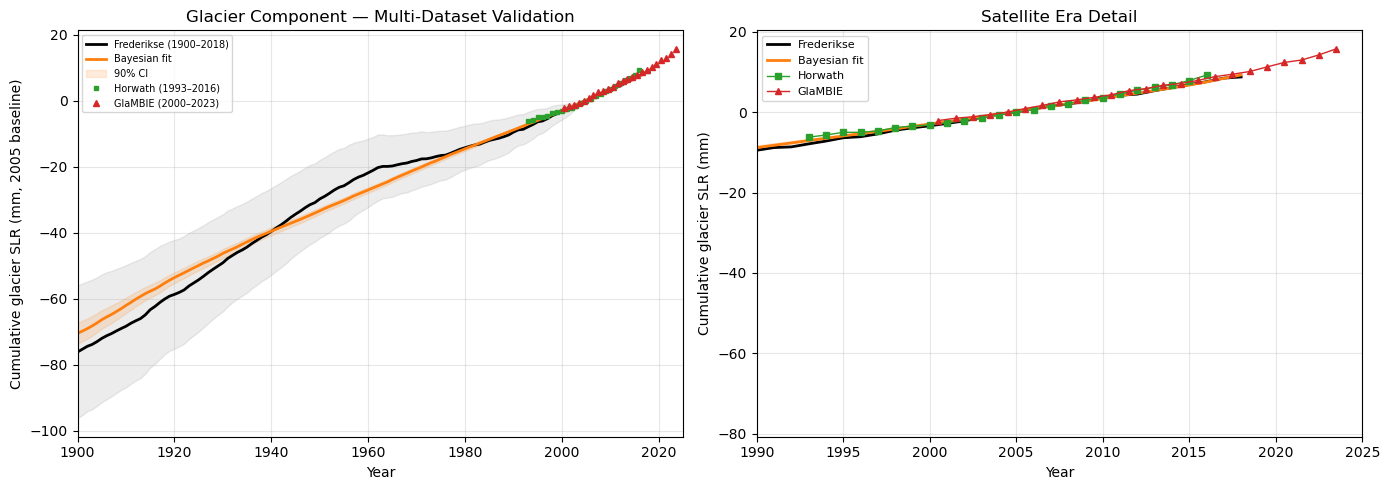

Saved: component_stage2a_glaciers.png


In [31]:
# ── Multi-dataset glacier validation ──
# Load Horwath glacier component (1993-2016, monthly, meters)
df_horwath = pd.read_hdf(H5_PATH, 'harmonized/df_horwath_h')
hw_years = df_horwath['decimal_year'].values
hw_glaciers = df_horwath['glaciers'].values
hw_glaciers_sigma = df_horwath['glaciers_sigma'].values

# Annualise Horwath (yearly mean)
hw_gl_annual = df_horwath[['decimal_year', 'glaciers', 'glaciers_sigma']].copy()
hw_gl_annual['year_int'] = hw_gl_annual['decimal_year'].astype(int)
hw_gl_yr = hw_gl_annual.groupby('year_int').agg({
    'glaciers': 'last',             # end-of-year cumulative
    'glaciers_sigma': 'last',
    'decimal_year': 'mean',
}).sort_index()

# Rebase Horwath and GlaMBIE to 2005 baseline
hw_gl_vals = hw_gl_yr['glaciers'].values
hw_gl_years = hw_gl_yr.index.values
idx_2005_hw = np.argmin(np.abs(hw_gl_years - 2005))
hw_gl_rebase = hw_gl_vals - hw_gl_vals[idx_2005_hw]

# GlaMBIE cumulative (already positive = SLR, from reader)
glac_years_gl = df_glac['decimal_year'].values
glac_cumul_m = np.cumsum(df_glac['mass_balance'].values)
idx_2005_glm = np.argmin(np.abs(glac_years_gl - 2005))
glac_cumul_rebase = glac_cumul_m - glac_cumul_m[idx_2005_glm]

# ── Validation figure ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Multi-dataset comparison
ax = axes[0]
# Frederikse
ax.plot(fred_year, glacier_rebase * M_TO_MM, 'k-', lw=2,
        label=f'Frederikse (1900–2018)')
ax.fill_between(fred_year,
                (glacier_rebase - 2*glacier_sigma) * M_TO_MM,
                (glacier_rebase + 2*glacier_sigma) * M_TO_MM,
                color='gray', alpha=0.15)
# Model fit
H_ens_gl = model_ensemble(result_glacier, I2_obs, I1_obs, I0_obs)
p5_gl, p50_gl, p95_gl = np.percentile(H_ens_gl * M_TO_MM, [5, 50, 95], axis=0)
ax.plot(fred_year, p50_gl, 'C1-', lw=2, label='Bayesian fit')
ax.fill_between(fred_year, p5_gl, p95_gl, color='C1', alpha=0.15, label='90% CI')

# Horwath
ax.plot(hw_gl_years, hw_gl_rebase * M_TO_MM, 'C2s', ms=3,
        label='Horwath (1993–2016)')

# GlaMBIE
ax.plot(glac_years_gl, glac_cumul_rebase * M_TO_MM, 'C3^', ms=4,
        label='GlaMBIE (2000–2023)')

ax.set_ylabel('Cumulative glacier SLR (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Glacier Component — Multi-Dataset Validation')
ax.legend(loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2025)

# Panel B: Satellite-era zoom
ax = axes[1]
ax.plot(fred_year, glacier_rebase * M_TO_MM, 'k-', lw=2,
        label='Frederikse')
ax.plot(fred_year, p50_gl, 'C1-', lw=2, label='Bayesian fit')
ax.fill_between(fred_year, p5_gl, p95_gl, color='C1', alpha=0.15)
ax.plot(hw_gl_years, hw_gl_rebase * M_TO_MM, 'C2s-', ms=4, lw=1,
        label='Horwath')
ax.plot(glac_years_gl, glac_cumul_rebase * M_TO_MM, 'C3^-', ms=4, lw=1,
        label='GlaMBIE')
ax.set_ylabel('Cumulative glacier SLR (mm)')
ax.set_xlabel('Year')
ax.set_title('Satellite Era Detail')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(1990, 2025)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage2a_glaciers.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage2a_glaciers.png')

In [32]:
# ── Glacier projections under SSPs ──
glacier_projections = {}
mc_idx_gl = rng_proj.choice(len(a_gl), N_MC, replace=False)

for ssp in ssps_to_plot:
    if ssp not in thermo_projections:
        continue
    # Reuse the design vectors already built for thermosteric projections
    # Rebuild for glacier (same temperature, same obs_times)
    df_ssp = ipcc_temp_proj[ssp]
    ipcc_years_float = df_ssp['decimal_year'].values
    ipcc_temp_vals = df_ssp['temperature'].values

    hist_mask = temp_time_monthly <= 2020.0
    t_hist = temp_time_monthly[hist_mask]
    T_hist = temp_monthly[hist_mask]
    t_future = np.arange(2020.0 + 1/24, 2101.0, 1/12)
    T_future = np.interp(t_future, ipcc_years_float, ipcc_temp_vals)
    t_full = np.concatenate([t_hist, t_future])
    T_full = np.concatenate([T_hist, T_future])

    dv_proj = build_level_design_vectors(
        temperature_monthly=T_full,
        time_monthly=t_full,
        obs_times=np.concatenate([fred_year, proj_years.astype(float)]),
    )
    n_obs = len(fred_year)
    I2p = dv_proj['I2_obs'][n_obs:]
    I1p = dv_proj['I1_obs'][n_obs:]
    I0p = dv_proj['I0_obs'][n_obs:]

    ens = np.zeros((N_MC, len(proj_years)))
    for i, j in enumerate(mc_idx_gl):
        ens[i] = a_gl[j] * I2p + b_gl[j] * I1p + c_gl[j] * I0p + H0_gl[j]

    glacier_projections[ssp] = {
        'years': proj_years,
        'samples': ens,
        'median': np.median(ens, axis=0),
        'p5': np.percentile(ens, 5, axis=0),
        'p95': np.percentile(ens, 95, axis=0),
    }
    med_2100 = glacier_projections[ssp]['median'][-1] * M_TO_MM
    lo_2100 = glacier_projections[ssp]['p5'][-1] * M_TO_MM
    hi_2100 = glacier_projections[ssp]['p95'][-1] * M_TO_MM
    print(f'  {ssp}: Glaciers at 2100 = {med_2100:.0f} [{lo_2100:.0f}, {hi_2100:.0f}] mm')

# Compare with IPCC glacier projections
print('\nIPCC AR6 glacier projections at 2100 (mm):')
for ssp in ssps_to_plot:
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_gl = read_ipcc_ar6_component(COMP_DIR, 'glaciers', scenario=ssp_code)
        print(f'  {ssp}: IPCC median = {df_ipcc_gl["median"].iloc[-1]*M_TO_MM:.0f} mm '
              f'[{df_ipcc_gl["p5"].iloc[-1]*M_TO_MM:.0f}, '
              f'{df_ipcc_gl["p95"].iloc[-1]*M_TO_MM:.0f}]')
    except FileNotFoundError:
        pass

  SSP1-2.6: Glaciers at 2100 = 232 [168, 303] mm
  SSP2-4.5: Glaciers at 2100 = 325 [226, 437] mm
  SSP5-8.5: Glaciers at 2100 = 564 [371, 782] mm

IPCC AR6 glacier projections at 2100 (mm):
  SSP1-2.6: IPCC median = 89 mm [54, 124]
  SSP2-4.5: IPCC median = 123 mm [84, 162]
  SSP5-8.5: IPCC median = 178 mm [133, 226]


---

## 11. Stage 2b: Physics-Informed Greenland Ice Sheet Model

Replace the phenomenological polynomial with a **two-component** model
separating surface mass balance (SMB) and ice-dynamic discharge:

$$H_{\text{GrIS}}(t) = \underbrace{a_{\text{eff}} I_2 + b_{\text{eff}} I_1}_{\text{SMB (instantaneous)}} + \underbrace{\gamma \int_0^t D_{\text{eff}}(\tau)\,d\tau}_{\text{Discharge (lagged)}} + c\,I_0 + H_0$$

**SMB** (55–92% of total) responds instantaneously to surface temperature
with polar amplification absorbed into $a_{\text{eff}}$ and $b_{\text{eff}}$.

**Discharge** (8–45%, Aschwanden et al. 2019) responds with a
multi-decadal relaxation lag $\tau_{\text{dyn}} \sim 10\text{–}50$ yr
via a single-layer ODE:

$$\frac{dD_{\text{eff}}}{dt} = \frac{T(t) - D_{\text{eff}}}{\tau_{\text{dyn}}}$$

Validation targets (Aschwanden & Brinkerhoff 2022, calibrated):
- SSP1-2.6 ≈ RCP 2.6: **8 [4, 14] cm**
- SSP5-8.5 ≈ RCP 8.5: **19 [9, 29] cm**
- Discharge fraction: 8–45% of total

In [ ]:
# ── Greenland component: combined Mouginot + Mankoff ──
# Using both IO datasets as independent observations (85 pts total).
# Overlap years (1986–2018) have two data points each, letting the
# inter-dataset spread inform the model uncertainty.
import bayesian_dols
from importlib import reload
reload(bayesian_dols)
from bayesian_dols import fit_bayesian_greenland, solve_twolayer_ode

# Combined arrays built in cell 3: grn_year_combined, grn_combined, grn_sigma_combined
greenland_rebase = grn_combined.copy()
greenland_sigma = grn_sigma_combined.copy()
greenland_year = grn_year_combined.copy()

print(f'Greenland combined (Mouginot + Mankoff): '
      f'{greenland_year[0]:.0f}–{greenland_year[-1]:.0f} '
      f'({len(greenland_year)} pts)')
print(f'  At 1972: {greenland_rebase[0]*M_TO_MM:.1f} mm  (rel. 2005)')
print(f'  At 2023: {greenland_rebase[-1]*M_TO_MM:.1f} mm')
print(f'  Mean sigma: {greenland_sigma.mean()*M_TO_MM:.1f} mm')

# ── Load Greenland-specific temperature (Berkeley Earth regional) ──
# Greenland T has much larger variability than GMST (Arctic amplification ~2–3×)
# and is the physically appropriate forcing for SMB.
GR_TEMP_PATH = DATA_RAW / 'gmst' / 'berkEarth_greenland_surfaceT.txt'
df_gr_temp = read_berkeley_earth(str(GR_TEMP_PATH))

# Monthly Greenland T, dropping NaN
gr_monthly_mask = df_gr_temp['temperature'].notna()
gr_temp_raw = df_gr_temp.loc[gr_monthly_mask, 'temperature'].values
gr_time_raw = (df_gr_temp.loc[gr_monthly_mask].index.year
               + (df_gr_temp.loc[gr_monthly_mask].index.month - 0.5) / 12.0)

# Rebaseline: 1951-1980 (Berkeley default) → 1995-2005 (our convention)
bl_mask_gr = (gr_time_raw >= 1995.0) & (gr_time_raw < 2006.0)
gr_temp_rebased = gr_temp_raw - gr_temp_raw[bl_mask_gr].mean()

# Greenland file ends ~May 2016; extend with GMST × Arctic amplification
# Fit AA factor from overlap period (Greenland T ≈ AA × GMST + offset)
overlap_mask_gr = (gr_time_raw >= 1972.0) & (gr_time_raw <= 2016.0)
overlap_mask_gm = (temp_time_monthly >= 1972.0) & (temp_time_monthly <= 2016.0)
# Interpolate GMST onto Greenland monthly times in the overlap
from scipy.interpolate import interp1d
gmst_interp_fn = interp1d(temp_time_monthly, temp_monthly,
                           bounds_error=False, fill_value='extrapolate')
gmst_at_gr_times = gmst_interp_fn(gr_time_raw[overlap_mask_gr])
AA_fit = np.polyfit(gmst_at_gr_times, gr_temp_rebased[overlap_mask_gr], 1)
AA_factor = AA_fit[0]
AA_offset = AA_fit[1]

# Extend: for months after Greenland record ends, use GMST × AA
last_gr_time = gr_time_raw[-1]
extend_mask = temp_time_monthly > last_gr_time
if extend_mask.any():
    t_extend = temp_time_monthly[extend_mask]
    T_extend = AA_factor * temp_monthly[extend_mask] + AA_offset
    gr_time_monthly = np.concatenate([gr_time_raw, t_extend])
    gr_temp_monthly = np.concatenate([gr_temp_rebased, T_extend])
    n_extended = extend_mask.sum()
else:
    gr_time_monthly = gr_time_raw.copy()
    gr_temp_monthly = gr_temp_rebased.copy()
    n_extended = 0

print(f'\nGreenland temperature: {gr_time_raw[0]:.1f}–{gr_time_raw[-1]:.1f} '
      f'(Berkeley Earth, {len(gr_time_raw)} months)')
print(f'  Arctic amplification (1972–2016): AA = {AA_factor:.2f}, '
      f'offset = {AA_offset:.3f} °C')
if n_extended > 0:
    print(f'  Extended {n_extended} months ({last_gr_time:.1f}–'
          f'{gr_time_monthly[-1]:.1f}) via GMST × AA')
print(f'  Total monthly series: {len(gr_time_monthly)} pts '
      f'({gr_time_monthly[0]:.1f}–{gr_time_monthly[-1]:.1f})')

# Build design vectors with GREENLAND temperature
design_grn = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly,
    time_monthly=gr_time_monthly,
    obs_times=greenland_year,
)
I2_obs_gr = design_grn['I2_obs']
I1_obs_gr = design_grn['I1_obs']
I0_obs_gr = design_grn['I0_obs']

# ── Rate prior from Mankoff MB data ──
# MB is in Gt/yr (positive = mass gain); convert to SLR rate (m/yr)
import pandas as pd
mankoff_path = DATA_RAW / 'ice_sheets' / 'greenland' / 'mankoff' / 'MB_SMB_D_BMB_ann.csv'
df_mankoff = pd.read_csv(mankoff_path)
# Use recent window (2015–2023) for end-of-record rate estimate
rate_window = df_mankoff[(df_mankoff['time'] >= 2015) & (df_mankoff['time'] <= 2023)]
GT_TO_M_SLE = 1.0 / 362500.0   # 1 Gt = 1/362.5 mm SLE = 1/362500 m SLE

# Rate = -MB (mass loss → positive SLR)
mb_rates = -rate_window['MB'].values * GT_TO_M_SLE      # m/yr
mb_errs  = rate_window['MB_err'].values * GT_TO_M_SLE   # m/yr

# Rate prior: mean rate ± combined uncertainty
# σ² = interannual variance / N + mean measurement variance / N
rate_mean = np.mean(mb_rates)
rate_sigma = np.sqrt(np.var(mb_rates, ddof=1) / len(mb_rates)
                     + np.mean(mb_errs**2) / len(mb_rates))
rate_eval_year = np.mean(rate_window['time'].values)

print(f'\nRate prior (Mankoff {rate_window["time"].iloc[0]:.0f}–'
      f'{rate_window["time"].iloc[-1]:.0f}, N={len(rate_window)}):')
print(f'  Mean rate: {rate_mean*M_TO_MM:.2f} ± {rate_sigma*M_TO_MM:.2f} mm/yr')
print(f'  Eval year: {rate_eval_year:.1f}')

# ── Prior configuration for physics-informed Greenland model ──
# a_eff = β_smb·f²_arctic: SMB nonlinearity × amplification²
# PC prior: P(a_eff > 3 mm/yr/°C²) = 20%
PRIOR_SCALE_A_GR = calibrate_exponential_prior(
    prob_exceed=0.20, threshold=0.003
)

# b_total = b_eff + γ: total linear sensitivity (SMB + discharge)
# HalfNormal σ = 4 mm/yr/°C (encompasses literature range)
PRIOR_SCALE_B_TOTAL_GR = 0.004
PRIOR_SCALE_B_GR = PRIOR_SCALE_B_TOTAL_GR  # alias for instantaneous model cells

# f_dyn: discharge fraction of linear sensitivity, f_dyn = γ / b_total
# Beta(5, 5): median 0.50, 95% CI [0.16, 0.84]
# Weakly informative — lets data determine SMB/discharge partition
PRIOR_FDYN_ALPHA = 5.0
PRIOR_FDYN_BETA = 5.0

# τ_dyn: ice-dynamic response time for marine-terminating outlets
# Median 20 yr, 94% CI [7, 55]; Straneo & Cenedese 2015, ISMIP6
PRIOR_LOG_TAU_MEAN = np.log(20.0)
PRIOR_LOG_TAU_SIGMA = 0.6

# c: fixed to GIA estimate (not a free parameter)
# Greenland GIA contribution to GMSL: ~0.05 mm/yr (Caron et al. 2018)
FIX_C_GR = 0.00005  # 0.05 mm/yr, fixed

# c prior (retained for prior_scales array, not sampled)
PRIOR_C_MEAN_GR = 0.0002     # 0.2 mm/yr
PRIOR_C_SIGMA_GR = 0.00015   # 0.15 mm/yr

# σ_extra: model inadequacy scale
PRIOR_SIGMA_EXTRA_GR = 0.002  # 2 mm

# H₀: baseline offset
PRIOR_H0_SIGMA_GR = 0.005   # 5 mm

print(f'\nPhysics-informed Greenland prior:')
print(f'  a_eff   ~ Exp(mean = {PRIOR_SCALE_A_GR*M_TO_MM:.2f} mm/yr/°C²)')
print(f'  b_total ~ HN(σ = {PRIOR_SCALE_B_TOTAL_GR*M_TO_MM:.1f} mm/yr/°C)')
print(f'  f_dyn   ~ Beta({PRIOR_FDYN_ALPHA:.0f}, {PRIOR_FDYN_BETA:.0f})  '
      f'[median=0.50, SD≈0.15]')
print(f'  τ_dyn   ~ LogN(log({np.exp(PRIOR_LOG_TAU_MEAN):.0f}), {PRIOR_LOG_TAU_SIGMA})')
print(f'  c       = {FIX_C_GR*M_TO_MM:.2f} mm/yr (fixed, GIA)')
print(f'  T0_init = 0.0 °C (anomaly baseline)')

# ── Fit physics-informed Greenland model ──
result_greenland_phys = fit_bayesian_greenland(
    H_obs=greenland_rebase,
    sigma_obs=greenland_sigma,
    I2_obs=I2_obs_gr,
    I1_obs=I1_obs_gr,
    I0_obs=I0_obs_gr,
    T_monthly=gr_temp_monthly,
    time_monthly=gr_time_monthly,
    obs_times=greenland_year,
    prior_scale_a=PRIOR_SCALE_A_GR,
    prior_scale_b_total=PRIOR_SCALE_B_TOTAL_GR,
    prior_fdyn_alpha=PRIOR_FDYN_ALPHA,
    prior_fdyn_beta=PRIOR_FDYN_BETA,
    prior_log_tau_mean=PRIOR_LOG_TAU_MEAN,
    prior_log_tau_sigma=PRIOR_LOG_TAU_SIGMA,
    prior_c_mean=PRIOR_C_MEAN_GR,
    prior_c_sigma=PRIOR_C_SIGMA_GR,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_GR,
    prior_H0_sigma=PRIOR_H0_SIGMA_GR,
    rate_prior_mean=rate_mean,
    rate_prior_sigma=rate_sigma,
    fix_c=FIX_C_GR,
    T0_init=0.0,
    n_samples=30000,
    n_walkers=128,
    n_burnin=5000,
    seed=2025,
    progress=True,
)

# ── Backward compatibility for combined assessment (cells 49-53) ──
a_gr = result_greenland_phys.posterior_samples[:, 0]   # a_eff
b_gr = result_greenland_phys.posterior_samples[:, 1]   # b_eff
gamma_gr = result_greenland_phys.posterior_samples[:, 2]  # γ (discharge)
c_gr = result_greenland_phys.posterior_samples[:, 3]   # c
H0_gr = result_greenland_phys.H0_posterior
r2_greenland = result_greenland_phys.r2
result_greenland = result_greenland_phys  # alias for validation cell

GREENLAND PHYSICS-INFORMED CALIBRATION RESULTS
  a_eff (SMB)    =    0.555 [0.364, 0.741] mm/yr/°C²
  b_eff (SMB)    =    0.346 [0.198, 0.499] mm/yr/°C
  γ (discharge)  =    0.099 [0.036, 0.216] mm/yr/°C
  c (drift)      =    0.050 [0.050, 0.050] mm/yr
  τ_dyn          =    6.892 [2.953, 17.237] yr
  σ_extra        =    3.909 [3.442, 4.474] mm
  H₀             =   -7.271 [-14.886, 0.379] mm

  R² = 0.3101

  Component fractions (1900–2018 change):
    SMB:          2.0 mm  (55.9%)
    Discharge:   -1.0 mm  (-28.5%)
    Total:        3.5 mm
  Target: discharge 8–45% (Aschwanden 2019)


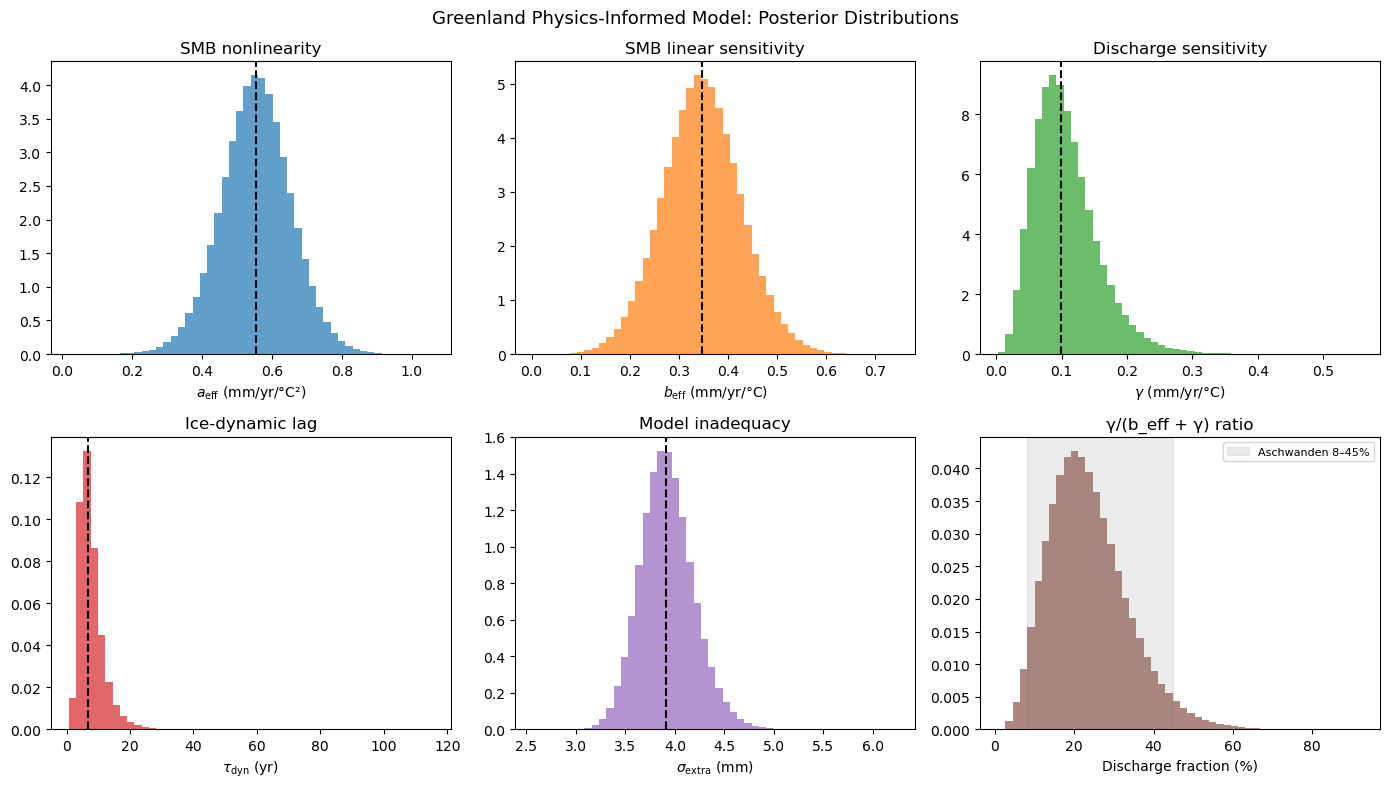

Saved: component_greenland_phys_posteriors.png


In [60]:
# ── Physics-informed Greenland diagnostics ──
import arviz as az

print('='*65)
print('GREENLAND PHYSICS-INFORMED CALIBRATION RESULTS')
print('='*65)

a_eff_samples = result_greenland_phys.posterior_samples[:, 0]
b_eff_samples = result_greenland_phys.posterior_samples[:, 1]
gamma_samples = result_greenland_phys.posterior_samples[:, 2]
c_samples_gr  = result_greenland_phys.posterior_samples[:, 3]
tau_dyn_samples = result_greenland_phys.tau_dyn_posterior
sigma_extra_gr = result_greenland_phys.sigma_extra_posterior

for name, s, unit in [
    ('a_eff (SMB)', a_eff_samples * M_TO_MM, 'mm/yr/°C²'),
    ('b_eff (SMB)', b_eff_samples * M_TO_MM, 'mm/yr/°C'),
    ('γ (discharge)', gamma_samples * M_TO_MM, 'mm/yr/°C'),
    ('c (drift)', c_samples_gr * M_TO_MM, 'mm/yr'),
    ('τ_dyn', tau_dyn_samples, 'yr'),
    ('σ_extra', sigma_extra_gr * M_TO_MM, 'mm'),
    ('H₀', H0_gr * M_TO_MM, 'mm'),
]:
    p3, p50, p97 = np.percentile(s, [3, 50, 97])
    print(f'  {name:14s} = {p50:8.3f} [{p3:.3f}, {p97:.3f}] {unit}')

print(f'\n  R² = {r2_greenland:.4f}')

# Discharge fraction at 2018
H_smb_change = result_greenland_phys.H_smb_mean[-1] - result_greenland_phys.H_smb_mean[0]
H_dyn_change = result_greenland_phys.H_dyn_mean[-1] - result_greenland_phys.H_dyn_mean[0]
H_total_change = result_greenland_phys.H_model_mean[-1] - result_greenland_phys.H_model_mean[0]
if abs(H_total_change) > 1e-8:
    smb_frac = H_smb_change / H_total_change
    dyn_frac = H_dyn_change / H_total_change
    print(f'\n  Component fractions (1900–2018 change):')
    print(f'    SMB:       {H_smb_change*M_TO_MM:6.1f} mm  ({smb_frac:5.1%})')
    print(f'    Discharge: {H_dyn_change*M_TO_MM:6.1f} mm  ({dyn_frac:5.1%})')
    print(f'    Total:     {H_total_change*M_TO_MM:6.1f} mm')
    print(f'  Target: discharge 8–45% (Aschwanden 2019)')
print('='*65)

# ── Posterior histograms ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# a_eff
ax = axes[0, 0]
ax.hist(a_eff_samples * M_TO_MM, bins=50, density=True, alpha=0.7, color='C0')
ax.axvline(np.median(a_eff_samples) * M_TO_MM, color='k', ls='--')
ax.set_xlabel(r'$a_{\mathrm{eff}}$ (mm/yr/°C²)')
ax.set_title('SMB nonlinearity')

# b_eff
ax = axes[0, 1]
ax.hist(b_eff_samples * M_TO_MM, bins=50, density=True, alpha=0.7, color='C1')
ax.axvline(np.median(b_eff_samples) * M_TO_MM, color='k', ls='--')
ax.set_xlabel(r'$b_{\mathrm{eff}}$ (mm/yr/°C)')
ax.set_title('SMB linear sensitivity')

# γ
ax = axes[0, 2]
ax.hist(gamma_samples * M_TO_MM, bins=50, density=True, alpha=0.7, color='C2')
ax.axvline(np.median(gamma_samples) * M_TO_MM, color='k', ls='--')
ax.set_xlabel(r'$\gamma$ (mm/yr/°C)')
ax.set_title('Discharge sensitivity')

# τ_dyn
ax = axes[1, 0]
ax.hist(tau_dyn_samples, bins=50, density=True, alpha=0.7, color='C3')
ax.axvline(np.median(tau_dyn_samples), color='k', ls='--')
ax.set_xlabel(r'$\tau_{\mathrm{dyn}}$ (yr)')
ax.set_title('Ice-dynamic lag')

# σ_extra
ax = axes[1, 1]
ax.hist(sigma_extra_gr * M_TO_MM, bins=50, density=True, alpha=0.7, color='C4')
ax.axvline(np.median(sigma_extra_gr) * M_TO_MM, color='k', ls='--')
ax.set_xlabel(r'$\sigma_{\mathrm{extra}}$ (mm)')
ax.set_title('Model inadequacy')

# Discharge fraction posterior
ax = axes[1, 2]
# Estimate discharge fraction from posterior samples for satellite era (2002-2018)
# Approximate using b_eff and γ contributions at representative temperature
dyn_frac_post = gamma_samples / (b_eff_samples + gamma_samples + 1e-12)
ax.hist(dyn_frac_post * 100, bins=50, density=True, alpha=0.7, color='C5')
ax.axvspan(8, 45, alpha=0.15, color='gray', label='Aschwanden 8–45%')
ax.set_xlabel('Discharge fraction (%)')
ax.set_title('γ/(b_eff + γ) ratio')
ax.legend(fontsize=8)

fig.suptitle('Greenland Physics-Informed Model: Posterior Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_phys_posteriors.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_greenland_phys_posteriors.png')

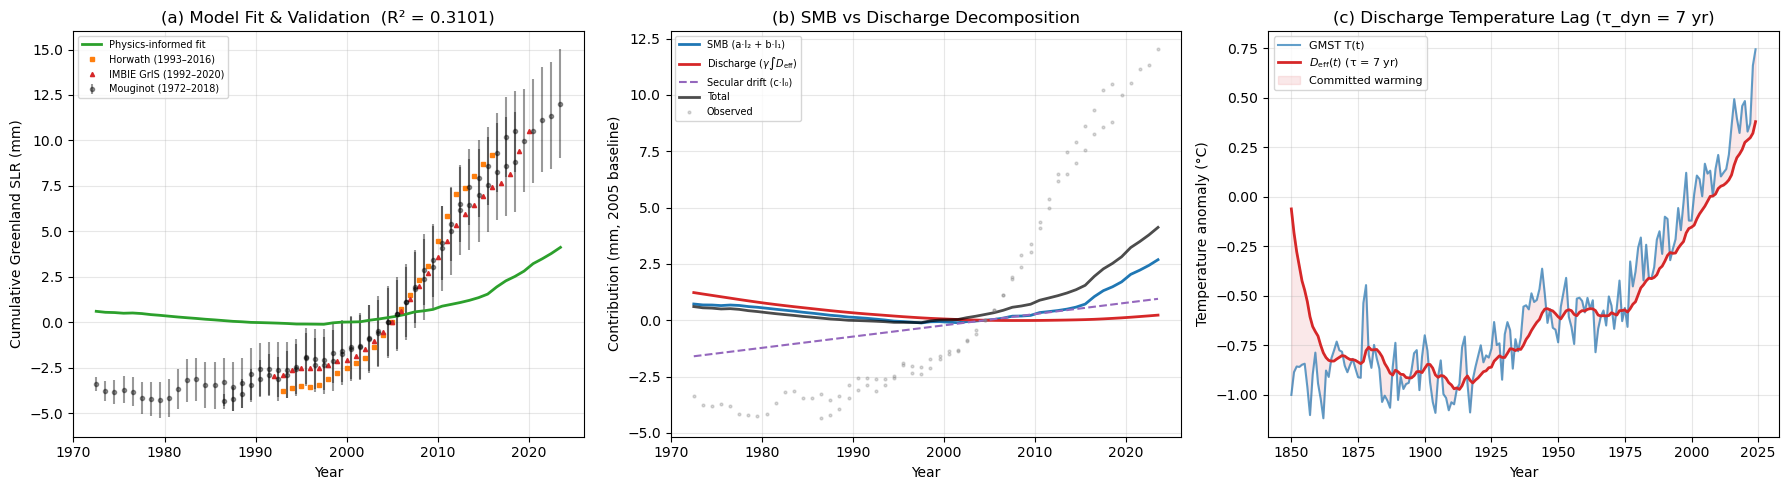

Saved: component_greenland_phys_decomposition.png


In [61]:
# ── Physics-informed Greenland: decomposition + validation figure ──
# Model was fit on greenland_year (= mou_year, 1972–2018).
# All model outputs (H_model_mean, H_smb_mean, etc.) are on this grid.

# Horwath Greenland (1993-2016, monthly, meters)
hw_gr_annual = df_horwath[['decimal_year', 'greenland', 'greenland_sigma']].copy()
hw_gr_annual['year_int'] = hw_gr_annual['decimal_year'].astype(int)
hw_gr_yr = hw_gr_annual.groupby('year_int').agg({
    'greenland': 'last',
    'greenland_sigma': 'last',
    'decimal_year': 'mean',
}).sort_index()
hw_gr_years = hw_gr_yr.index.values
hw_gr_vals = hw_gr_yr['greenland'].values
idx_2005_hw_gr = np.argmin(np.abs(hw_gr_years - 2005))
hw_gr_rebase = hw_gr_vals - hw_gr_vals[idx_2005_hw_gr]

# IMBIE Greenland → SLR contribution = -cumulative_mass_balance
gris_yr_ann = df_gris['cumulative_mass_balance'].resample('YE').last()
gris_years = gris_yr_ann.index.year
gris_slr = -gris_yr_ann.values  # negate: mass loss → positive SLR
idx_2005_gris = np.argmin(np.abs(gris_years - 2005))
gris_slr_rebase = gris_slr - gris_slr[idx_2005_gris]

# Design vectors on greenland_year grid (for decomposition plot)
# I0_obs_gr was built in cell 45 on this grid.

# ── 3-panel figure ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Total model fit + multi-dataset validation
ax = axes[0]
ax.errorbar(greenland_year, greenland_rebase * M_TO_MM,
            yerr=2*greenland_sigma * M_TO_MM,
            fmt='o', ms=3, color='k', alpha=0.4, label='Mouginot (1972–2018)')

# Physics-informed model prediction
ax.plot(greenland_year, result_greenland_phys.H_model_mean * M_TO_MM,
        'C2-', lw=2, label='Physics-informed fit')

# Validation datasets
ax.plot(hw_gr_years, hw_gr_rebase * M_TO_MM, 'C1s', ms=3,
        label='Horwath (1993–2016)')
ax.plot(gris_years, gris_slr_rebase * M_TO_MM, 'C3^', ms=3,
        label='IMBIE GrIS (1992–2020)')

ax.set_ylabel('Cumulative Greenland SLR (mm)')
ax.set_xlabel('Year')
ax.set_title(f'(a) Model Fit & Validation  (R² = {r2_greenland:.4f})')
ax.legend(loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)

# Panel B: Component decomposition (SMB vs discharge vs secular)
ax = axes[1]
H_smb = result_greenland_phys.H_smb_mean
H_dyn = result_greenland_phys.H_dyn_mean
c_med = np.median(c_gr)
H_sec = c_med * I0_obs_gr  # secular drift contribution (on greenland_year grid)

bl_gr = np.argmin(np.abs(greenland_year - BASELINE_YEAR))
ax.plot(greenland_year, (H_smb - H_smb[bl_gr]) * M_TO_MM,
        'C0-', lw=2, label='SMB (a·I₂ + b·I₁)')
ax.plot(greenland_year, (H_dyn - H_dyn[bl_gr]) * M_TO_MM,
        'C3-', lw=2, label=r'Discharge ($\gamma \int D_{\rm eff}$)')
ax.plot(greenland_year, (H_sec - H_sec[bl_gr]) * M_TO_MM,
        'C4--', lw=1.5, label='Secular drift (c·I₀)')
ax.plot(greenland_year, result_greenland_phys.H_model_mean * M_TO_MM,
        'k-', lw=2, alpha=0.7, label='Total')
ax.plot(greenland_year, greenland_rebase * M_TO_MM,
        'o', ms=2, color='gray', alpha=0.3, label='Observed')

ax.set_ylabel('Contribution (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('(b) SMB vs Discharge Decomposition')
ax.legend(loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)

# Panel C: D_eff(t) vs T(t) — showing the discharge lag
ax = axes[2]
# Plot monthly temperature and D_eff
D_eff = result_greenland_phys.D_eff_mean
tau_med = np.median(tau_dyn_samples)

# Annual average for cleaner plot
year_fl = np.floor(temp_time_monthly).astype(int)
unique_yr = np.unique(year_fl)
T_ann_avg = np.array([np.mean(temp_monthly[year_fl == y]) for y in unique_yr])
D_ann_avg = np.array([np.mean(D_eff[year_fl == y]) for y in unique_yr])

ax.plot(unique_yr, T_ann_avg, 'C0-', lw=1.5, alpha=0.7, label='GMST T(t)')
ax.plot(unique_yr, D_ann_avg, 'C3-', lw=2,
        label=f'$D_{{\\rm eff}}(t)$ (τ = {tau_med:.0f} yr)')
ax.fill_between(unique_yr, T_ann_avg, D_ann_avg,
                alpha=0.1, color='C3', label='Committed warming')
ax.set_ylabel('Temperature anomaly (°C)')
ax.set_xlabel('Year')
ax.set_title(f'(c) Discharge Temperature Lag (τ_dyn = {tau_med:.0f} yr)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_phys_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_greenland_phys_decomposition.png')

In [36]:
# ── Physics-informed Greenland projections under SSPs ──
greenland_projections = {}
mc_idx_gr = rng_proj.choice(len(a_gr), N_MC, replace=False)

# Projection arrays from posterior
a_eff_mc = a_eff_samples
b_eff_mc = b_eff_samples
gamma_mc = gamma_samples
c_mc_gr  = c_samples_gr
tau_mc   = tau_dyn_samples

print('Greenland physics-informed projections at 2100 (mm, 2005 baseline):')
print(f'  {"SSP":10s} {"Total":>18s} {"SMB":>18s} {"Discharge":>18s} {"Dyn%":>6s}')
print('-'*70)

for ssp in ssps_to_plot:
    if ssp not in ipcc_temp_proj:
        continue
    df_ssp = ipcc_temp_proj[ssp]
    ipcc_years_float = df_ssp['decimal_year'].values
    ipcc_temp_vals = df_ssp['temperature'].values

    # Build monthly temperature: historical + projected
    hist_mask = temp_time_monthly <= 2020.0
    t_hist = temp_time_monthly[hist_mask]
    T_hist = temp_monthly[hist_mask]
    t_future = np.arange(2020.0 + 1/24, 2101.0, 1/12)
    T_future = np.interp(t_future, ipcc_years_float, ipcc_temp_vals)
    t_full = np.concatenate([t_hist, t_future])
    T_full = np.concatenate([T_hist, T_future])

    # Design vectors on full grid
    dv_proj = build_level_design_vectors(
        temperature_monthly=T_full,
        time_monthly=t_full,
        obs_times=np.concatenate([fred_year, proj_years.astype(float)]),
    )
    n_obs = len(fred_year)
    I2p = dv_proj['I2_obs'][n_obs:]
    I1p = dv_proj['I1_obs'][n_obs:]
    I0p = dv_proj['I0_obs'][n_obs:]
    proj_full_idx = dv_proj['obs_idx'][n_obs:]  # indices into full monthly grid

    # Pre-compute dt on full monthly grid (for cumulative ∫D_eff)
    dt_full = np.diff(t_full)

    # MC ensemble with physics-informed model
    ens_total = np.zeros((N_MC, len(proj_years)))
    ens_smb   = np.zeros((N_MC, len(proj_years)))
    ens_dyn   = np.zeros((N_MC, len(proj_years)))

    for i, j in enumerate(mc_idx_gr):
        # Discharge ODE on full timeline
        D_eff_k, _ = solve_twolayer_ode(T_full, t_full, tau_mc[j], np.inf)

        # Cumulative ∫D_eff (vectorised trapezoidal)
        D_mid = 0.5 * (D_eff_k[:-1] + D_eff_k[1:])
        cum_D = np.concatenate([[0], np.cumsum(D_mid * dt_full)])
        cum_D_p = cum_D[proj_full_idx]

        # Components
        H_smb_k = a_eff_mc[j] * I2p + b_eff_mc[j] * I1p
        H_dyn_k = gamma_mc[j] * cum_D_p
        H_tot_k = H_smb_k + H_dyn_k + c_mc_gr[j] * I0p + H0_gr[j]

        ens_total[i] = H_tot_k
        ens_smb[i] = H_smb_k
        ens_dyn[i] = H_dyn_k

    # Store (backward-compatible dict format)
    greenland_projections[ssp] = {
        'years': proj_years,
        'samples': ens_total,
        'median': np.median(ens_total, axis=0),
        'p5': np.percentile(ens_total, 5, axis=0),
        'p95': np.percentile(ens_total, 95, axis=0),
        'p17': np.percentile(ens_total, 17, axis=0),
        'p83': np.percentile(ens_total, 83, axis=0),
        'samples_smb': ens_smb,
        'samples_dyn': ens_dyn,
        'median_smb': np.median(ens_smb, axis=0),
        'median_dyn': np.median(ens_dyn, axis=0),
    }

    # Report at 2100
    tot = greenland_projections[ssp]['median'][-1] * M_TO_MM
    tot_lo = greenland_projections[ssp]['p5'][-1] * M_TO_MM
    tot_hi = greenland_projections[ssp]['p95'][-1] * M_TO_MM
    smb_2100 = np.median(ens_smb, axis=0)[-1] * M_TO_MM
    dyn_2100 = np.median(ens_dyn, axis=0)[-1] * M_TO_MM
    dyn_pct = dyn_2100 / tot * 100 if abs(tot) > 0.1 else 0
    print(f'  {ssp:10s} {tot:5.0f} [{tot_lo:.0f}, {tot_hi:.0f}]'
          f'   {smb_2100:5.0f}              {dyn_2100:5.0f}            {dyn_pct:4.0f}%')

# ── Compare with IPCC and Aschwanden ──
print('\n' + '='*70)
print('COMPARISON WITH IPCC GIS AND ASCHWANDEN ET AL.')
print('='*70)
print(f'  {"SSP":10s} {"This model":>15s} {"IPCC GIS":>15s} {"Aschwanden":>15s}')
print('-'*60)

# Aschwanden calibrated (2022) at 2100 (cm → mm)
aschw = {
    'SSP1-2.6': (80, 40, 140),   # median, lo, hi  (mm)
    'SSP2-4.5': (110, 50, 180),
    'SSP5-8.5': (190, 90, 290),
}

for ssp in ssps_to_plot:
    if ssp not in greenland_projections:
        continue

    ours = greenland_projections[ssp]['median'][-1] * M_TO_MM
    ours_lo = greenland_projections[ssp]['p5'][-1] * M_TO_MM
    ours_hi = greenland_projections[ssp]['p95'][-1] * M_TO_MM
    ours_str = f'{ours:.0f} [{ours_lo:.0f},{ours_hi:.0f}]'

    # IPCC
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_gis = read_ipcc_ar6_component(
            COMP_DIR, 'icesheets', sub_component='GIS', scenario=ssp_code)
        ipcc_2100 = df_ipcc_gis.loc[2100, 'median'] * M_TO_MM
        ipcc_lo = df_ipcc_gis.loc[2100, 'p05'] * M_TO_MM
        ipcc_hi = df_ipcc_gis.loc[2100, 'p95'] * M_TO_MM
        ipcc_str = f'{ipcc_2100:.0f} [{ipcc_lo:.0f},{ipcc_hi:.0f}]'
    except Exception:
        ipcc_str = 'N/A'

    # Aschwanden
    if ssp in aschw:
        a_med, a_lo, a_hi = aschw[ssp]
        aschw_str = f'{a_med:.0f} [{a_lo:.0f},{a_hi:.0f}]'
    else:
        aschw_str = 'N/A'

    print(f'  {ssp:10s} {ours_str:>15s} {ipcc_str:>15s} {aschw_str:>15s}')

print('='*60)
print('Aschwanden: calibrated Aschwanden & Brinkerhoff (2022), cm→mm')

Greenland physics-informed projections at 2100 (mm, 2005 baseline):
  SSP                     Total                SMB          Discharge   Dyn%
----------------------------------------------------------------------
  SSP1-2.6     424 [366, 479]     300                  1               0%
  SSP2-4.5     591 [503, 675]     450                 18               3%
  SSP5-8.5    1000 [833, 1157]     828                 48               5%

COMPARISON WITH IPCC GIS AND ASCHWANDEN ET AL.
  SSP             This model        IPCC GIS      Aschwanden
------------------------------------------------------------
  SSP1-2.6     424 [366,479]             N/A     80 [40,140]
  SSP2-4.5     591 [503,675]             N/A    110 [50,180]
  SSP5-8.5   1000 [833,1157]             N/A    190 [90,290]
Aschwanden: calibrated Aschwanden & Brinkerhoff (2022), cm→mm


---

## 12. Combined Assessment: Stages 1 + 2a + 2b

Combine the three fitted components (thermosteric + glaciers + Greenland)
and assess:
1. How much of total GMSL is explained by these three components
2. The implied Antarctica + TWS residual
3. How the quadratic acceleration ($a$) partitions across components
4. Projection comparison with IPCC at 2100

In [37]:
# ── Coefficient comparison: all four models ──
print('COMPONENT COEFFICIENT COMPARISON')
print('All values: median [5%, 95%] in mm/yr units')
print('='*80)
print(f'{"Component":15s} {"a (dα/dT)":>25s}  {"b (α₀)":>25s}  {"c (trend)":>25s}')
print('-'*80)

comp_data = [
    ('Total GMSL', a_total, b_total, c_total),
    ('Thermosteric', a_th, b_th, c_th),
    ('Glaciers', a_gl, b_gl, c_gl),
    ('Greenland', a_gr, b_gr, c_gr),
]

for label, a_arr, b_arr, c_arr in comp_data:
    def fmt(arr):
        s = arr * M_TO_MM
        return f'{np.median(s):5.2f} [{np.percentile(s,5):5.2f},{np.percentile(s,95):5.2f}]'
    print(f'  {label:13s}  {fmt(a_arr):>25s}  {fmt(b_arr):>25s}  {fmt(c_arr):>25s}')

# Sum of 3 components
n_min = min(len(a_th), len(a_gl), len(a_gr))
a_sum = (a_th[:n_min] + a_gl[:n_min] + a_gr[:n_min]) * M_TO_MM
b_sum = (b_th[:n_min] + b_gl[:n_min] + b_gr[:n_min]) * M_TO_MM
c_sum = (c_th[:n_min] + c_gl[:n_min] + c_gr[:n_min]) * M_TO_MM

def fmt_arr(arr):
    return f'{np.median(arr):5.2f} [{np.percentile(arr,5):5.2f},{np.percentile(arr,95):5.2f}]'

print(f'  {"Σ(3 comps)":13s}  {fmt_arr(a_sum):>25s}  {fmt_arr(b_sum):>25s}  {fmt_arr(c_sum):>25s}')

# Residual = total - 3 components
a_resid = (a_total[:n_min] * M_TO_MM) - a_sum
b_resid = (b_total[:n_min] * M_TO_MM) - b_sum
c_resid = (c_total[:n_min] * M_TO_MM) - c_sum
print(f'  {"AIS+TWS resid":13s}  {fmt_arr(a_resid):>25s}  {fmt_arr(b_resid):>25s}  {fmt_arr(c_resid):>25s}')
print('='*80)

# Percentage of quadratic acceleration from each component
a_tot_med = np.median(a_total) * M_TO_MM
print(f'\nPartition of quadratic acceleration a (dα/dT):')
print(f'  Total GMSL a = {a_tot_med:.2f} mm/yr/°C²')
for label, a_arr in [('Thermosteric', a_th), ('Glaciers', a_gl),
                      ('Greenland', a_gr)]:
    a_med = np.median(a_arr) * M_TO_MM
    pct = a_med / a_tot_med * 100
    print(f'  {label:13s}: {a_med:.2f} mm/yr/°C²  ({pct:5.1f}%)')
a_resid_med = np.median(a_resid)
print(f'  {"AIS+TWS":13s}: {a_resid_med:.2f} mm/yr/°C²  ({a_resid_med/a_tot_med*100:5.1f}%)')

COMPONENT COEFFICIENT COMPARISON
All values: median [5%, 95%] in mm/yr units
Component                       a (dα/dT)                     b (α₀)                  c (trend)
--------------------------------------------------------------------------------
  Total GMSL            4.48 [ 3.19, 5.73]         5.01 [ 4.05, 5.97]         2.54 [ 2.41, 2.67]
  Thermosteric          0.23 [ 0.03, 0.54]         1.09 [ 0.93, 1.32]         0.99 [ 0.96, 1.02]
  Glaciers              0.58 [ 0.35, 0.83]         0.30 [ 0.20, 0.42]         0.60 [ 0.57, 0.63]
  Greenland             0.88 [ 0.69, 1.06]         0.70 [ 0.59, 0.84]         0.49 [ 0.42, 0.63]
  Σ(3 comps)            1.71 [ 1.32, 2.14]         2.11 [ 1.87, 2.38]         2.08 [ 2.00, 2.24]
  AIS+TWS resid         2.76 [ 1.41, 4.09]         2.90 [ 1.90, 3.89]         0.45 [ 0.25, 0.62]

Partition of quadratic acceleration a (dα/dT):
  Total GMSL a = 4.48 mm/yr/°C²
  Thermosteric : 0.23 mm/yr/°C²  (  5.1%)
  Glaciers     : 0.58 mm/yr/°C²  ( 13.0%)


Antarctica + TWS residual at 2018:
  GMSL − (thermo+glac+GrIS) fit:   -53.3 mm
  Frederikse AIS+TWS direct:          9.7 mm
  Difference:                        -63.0 mm

Three-component R² against total GMSL: -0.7329
  (vs single-model total GMSL R²:       0.9696)


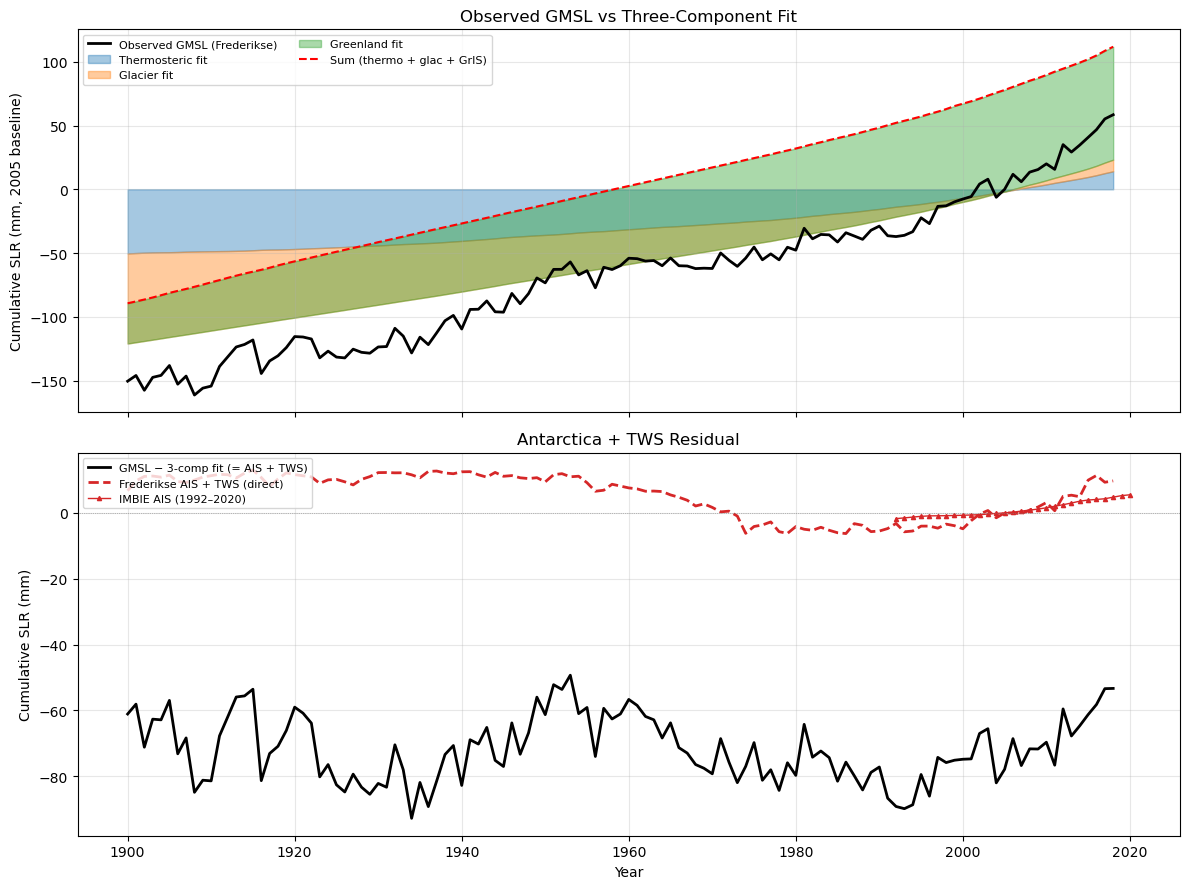

Saved: component_stage2_combined.png


In [38]:
# ── Antarctica + TWS residual ──
# Observed residual = GMSL - steric_fit - glacier_fit - greenland_fit
H_3comp_median = (np.median(a_th) * I2_obs + np.median(b_th) * I1_obs +
                  np.median(c_th) * I0_obs + np.median(H0_th) +
                  np.median(a_gl) * I2_obs + np.median(b_gl) * I1_obs +
                  np.median(c_gl) * I0_obs + np.median(H0_gl) +
                  np.median(a_gr) * I2_obs + np.median(b_gr) * I1_obs +
                  np.median(c_gr) * I0_obs + np.median(H0_gr))

resid_ais_tws = gmsl_rebase - H_3comp_median

# Compare with Frederikse AIS + TWS
fred_ais_tws = (fred_antarctica + fred_tws)
fred_ais_tws_rebase = fred_ais_tws - fred_ais_tws[baseline_idx]

print('Antarctica + TWS residual at 2018:')
print(f'  GMSL − (thermo+glac+GrIS) fit:  {resid_ais_tws[-1]*M_TO_MM:6.1f} mm')
print(f'  Frederikse AIS+TWS direct:       {fred_ais_tws_rebase[-1]*M_TO_MM:6.1f} mm')
print(f'  Difference:                       '
      f'{(resid_ais_tws[-1]-fred_ais_tws_rebase[-1])*M_TO_MM:6.1f} mm')

# R² of 3-component sum against total GMSL
ss_res_3 = np.sum((gmsl_rebase - H_3comp_median)**2)
ss_tot_3 = np.sum((gmsl_rebase - np.mean(gmsl_rebase))**2)
r2_3comp = 1 - ss_res_3 / ss_tot_3
print(f'\nThree-component R² against total GMSL: {r2_3comp:.4f}')
print(f'  (vs single-model total GMSL R²:       {result_total.r2:.4f})')

# ── Plot: 3-component fit vs observed GMSL ──
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Panel A: Stacked components vs GMSL
ax = axes[0]
ax.plot(fred_year, gmsl_rebase * M_TO_MM, 'k-', lw=2,
        label='Observed GMSL (Frederikse)')

# Stack the 3 component fits
H_th = np.median(a_th) * I2_obs + np.median(b_th) * I1_obs + \
       np.median(c_th) * I0_obs + np.median(H0_th)
H_gl = np.median(a_gl) * I2_obs + np.median(b_gl) * I1_obs + \
       np.median(c_gl) * I0_obs + np.median(H0_gl)
H_gr = np.median(a_gr) * I2_obs + np.median(b_gr) * I1_obs + \
       np.median(c_gr) * I0_obs + np.median(H0_gr)

ax.fill_between(fred_year, 0, H_th * M_TO_MM, color='C0', alpha=0.4,
                label='Thermosteric fit')
ax.fill_between(fred_year, H_th * M_TO_MM, (H_th + H_gl) * M_TO_MM,
                color='C1', alpha=0.4, label='Glacier fit')
ax.fill_between(fred_year, (H_th + H_gl) * M_TO_MM,
                (H_th + H_gl + H_gr) * M_TO_MM,
                color='C2', alpha=0.4, label='Greenland fit')
ax.plot(fred_year, H_3comp_median * M_TO_MM, 'r--', lw=1.5,
        label='Sum (thermo + glac + GrIS)')

ax.set_ylabel('Cumulative SLR (mm, 2005 baseline)')
ax.set_title('Observed GMSL vs Three-Component Fit')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Panel B: Residual = Antarctica + TWS
ax = axes[1]
ax.plot(fred_year, resid_ais_tws * M_TO_MM, 'k-', lw=2,
        label='GMSL − 3-comp fit (= AIS + TWS)')
ax.plot(fred_year, fred_ais_tws_rebase * M_TO_MM, 'C3--', lw=2,
        label='Frederikse AIS + TWS (direct)')

# IMBIE AIS
ais_yr_ann = df_ais['cumulative_mass_balance'].resample('YE').last()
ais_years = ais_yr_ann.index.year
ais_slr = -ais_yr_ann.values
idx_2005_ais = np.argmin(np.abs(ais_years - 2005))
ais_slr_rebase = ais_slr - ais_slr[idx_2005_ais]
ax.plot(ais_years, ais_slr_rebase * M_TO_MM, 'C3^-', ms=3, lw=1,
        label='IMBIE AIS (1992–2020)')

ax.set_ylabel('Cumulative SLR (mm)')
ax.set_xlabel('Year')
ax.set_title('Antarctica + TWS Residual')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', ls=':', lw=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage2_combined.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage2_combined.png')

In [39]:
# ── Projection comparison at 2100: component sum vs IPCC total ──
print('PROJECTION SUMMARY AT 2100 (mm, 2005 baseline)')
print('='*75)
print(f'{"SSP":10s} {"Thermo":>12s} {"Glaciers":>12s} {"Greenland":>12s} '
      f'{"3-comp sum":>12s} {"IPCC GMSL":>12s}')
print('-'*75)

for ssp in ssps_to_plot:
    th_med = thermo_projections[ssp]['median'][-1] * M_TO_MM
    gl_med = glacier_projections[ssp]['median'][-1] * M_TO_MM
    gr_med = greenland_projections[ssp]['median'][-1] * M_TO_MM
    total_3 = th_med + gl_med + gr_med

    # IPCC total GMSL
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_gmsl = pd.read_hdf(H5_PATH, f'projections/gmsl/{ssp_code}')
        ipcc_2100 = df_ipcc_gmsl['gmsl'].iloc[-1] * M_TO_MM
        ipcc_str = f'{ipcc_2100:.0f}'
    except Exception:
        ipcc_str = 'N/A'

    print(f'  {ssp:8s} {th_med:10.0f}   {gl_med:10.0f}   {gr_med:10.0f}   '
          f'{total_3:10.0f}   {ipcc_str:>10s}')

print('='*75)
print('\nNote: 3-component sum excludes Antarctica + TWS.')
print('IPCC GMSL is the full AR6 medium-confidence projection.')

PROJECTION SUMMARY AT 2100 (mm, 2005 baseline)
SSP              Thermo     Glaciers    Greenland   3-comp sum    IPCC GMSL
---------------------------------------------------------------------------
  SSP1-2.6        297          232          424          952          684
  SSP2-4.5        367          325          591         1283          927
  SSP5-8.5        522          564         1000         2086         1332

Note: 3-component sum excludes Antarctica + TWS.
IPCC GMSL is the full AR6 medium-confidence projection.


In [40]:
# ── Export Stage 1 + 2 results ──
import json

def median_ci(arr, to_mm=True):
    s = arr * M_TO_MM if to_mm else arr
    return {
        'median': float(np.median(s)),
        'ci_90': [float(np.percentile(s, 5)), float(np.percentile(s, 95))],
    }

stage2_results = {
    'thermosteric_calibration': {
        'a_th': median_ci(a_th), 'b_th': median_ci(b_th),
        'c_th': median_ci(c_th), 'R2': float(r2_thermo),
    },
    'glacier_calibration': {
        'a_gl': median_ci(a_gl), 'b_gl': median_ci(b_gl),
        'c_gl': median_ci(c_gl), 'R2': float(r2_glacier),
    },
    'greenland_calibration': {
        'a_gr': median_ci(a_gr), 'b_gr': median_ci(b_gr),
        'c_gr': median_ci(c_gr), 'R2': float(r2_greenland),
    },
    'three_component_R2': float(r2_3comp),
    'component_rates_2002_2018_mm_yr': components_rate,
    'projections_at_2100': {},
    'config': {
        'data_source': 'Frederikse et al. (2020) components',
        'validation': ['Horwath et al. (2022)', 'IMBIE (Otosaka 2023)', 'GlaMBIE (2024)'],
        'temperature': 'Berkeley Earth',
        'baseline_year': BASELINE_YEAR,
    },
}

for ssp in ssps_to_plot:
    stage2_results['projections_at_2100'][ssp] = {
        'thermosteric_mm': float(thermo_projections[ssp]['median'][-1] * M_TO_MM),
        'glacier_mm': float(glacier_projections[ssp]['median'][-1] * M_TO_MM),
        'greenland_mm': float(greenland_projections[ssp]['median'][-1] * M_TO_MM),
        'three_comp_sum_mm': float(
            (thermo_projections[ssp]['median'][-1] +
             glacier_projections[ssp]['median'][-1] +
             greenland_projections[ssp]['median'][-1]) * M_TO_MM),
    }

out_path = '../data/processed/stage1_thermosteric_results.json'
with open(out_path, 'w') as f:
    json.dump(stage2_results, f, indent=2)

print(f'Results exported to {out_path}')
print(json.dumps(stage2_results, indent=2))

Results exported to ../data/processed/stage1_thermosteric_results.json
{
  "thermosteric_calibration": {
    "a_th": {
      "median": 0.2287881139664158,
      "ci_90": [
        0.0300521043284904,
        0.5361007984303107
      ]
    },
    "b_th": {
      "median": 1.0931778037133104,
      "ci_90": [
        0.9335577220059101,
        1.319265662705869
      ]
    },
    "c_th": {
      "median": 0.9892596115397725,
      "ci_90": [
        0.9572904321318363,
        1.0202490034223795
      ]
    },
    "R2": 0.9799879707189945
  },
  "glacier_calibration": {
    "a_gl": {
      "median": 0.5832720156568036,
      "ci_90": [
        0.35248697980988974,
        0.8327479258107409
      ]
    },
    "b_gl": {
      "median": 0.3035852441811433,
      "ci_90": [
        0.1964585446797996,
        0.41671145272183413
      ]
    },
    "c_gl": {
      "median": 0.6000822313593153,
      "ci_90": [
        0.5734619044799787,
        0.6251864894932687
      ]
    },
    "R2": 0

## Note on Model Selection

**The quadratic fits in cells 40–53 above have been superseded by the taper-based linear fits in cells 65–76.** BIC model selection (cell 61) determined that linear rate–temperature models ($\dot{H} = b \cdot T + c$) are preferred over quadratic models for all individual components, once the analysis is restricted to observational windows and appropriate uncertainty tapering is applied. The quadratic acceleration visible in the *aggregate* GMSL–GMST relationship arises from the shifting mixture of components (see Section 1 discussion), not from any single component exhibiting quadratic behavior.

The quadratic results above are retained for comparison and to document the analysis pathway that led to this conclusion.

## 10. Phase 1 — Component-Level Nonlinearity Analysis

The central question: does each component's relationship with global temperature 
require a quadratic term, or is the quadratic apparent only in the aggregate?

We test this by comparing linear ($\dot{H} = b \cdot T + c$) vs quadratic 
($\dot{H} = a \cdot T^2 + b \cdot T + c$) models for each component 
individually, and show that the aggregate quadratic emerges from the 
superposition of simpler component relationships with shifting weights.

In [41]:
# ── Load EAIS, Peninsula, WAIS data; compute annual T and component rates ──
from slr_data_readers import read_imbie_west_antarctica
import os

IMBIE_MM_DIR = '../data/raw/ice_sheets/antarctica'

# --- Load sub-Antarctic components from mm-SLE files ---
# The mm files report cumulative mass balance directly in mm of sea-level
# equivalent (SLR convention: positive = sea level rise).  All three files
# share the same column layout, so read_imbie_west_antarctica works for all.
# NOTE: sigma columns in these files are negative (data formatting quirk);
#       we take np.abs() after loading.
df_eais_monthly = read_imbie_west_antarctica(
    os.path.join(IMBIE_MM_DIR, 'imbie_east_antarctica_2021_mm.csv'))
df_pen_monthly = read_imbie_west_antarctica(
    os.path.join(IMBIE_MM_DIR, 'imbie_antarctic_peninsula_2021_mm.csv'))
df_wais_monthly = read_imbie_west_antarctica(
    os.path.join(IMBIE_MM_DIR, 'imbie_west_antarctica_2021_mm.csv'))

# Fix negative sigmas (data quirk — uncertainties must be positive)
for df in [df_eais_monthly, df_pen_monthly, df_wais_monthly]:
    df['cumulative_mass_balance_sigma'] = df['cumulative_mass_balance_sigma'].abs()
    df['mass_balance_rate_sigma'] = df['mass_balance_rate_sigma'].abs()

def annualize_imbie(df, baseline_year=BASELINE_YEAR):
    """Resample monthly IMBIE to annual, rebase to baseline_year."""
    t = df['decimal_year'].values
    cum = df['cumulative_mass_balance'].values          # meters SLE
    sig = df['cumulative_mass_balance_sigma'].values    # meters SLE

    # Annual means
    years = np.arange(int(np.ceil(t[0])), int(np.floor(t[-1])) + 1)
    cum_ann = np.array([np.mean(cum[(t >= yr - 0.5) & (t < yr + 0.5)])
                        for yr in years])
    sig_ann = np.array([np.mean(sig[(t >= yr - 0.5) & (t < yr + 0.5)])
                        for yr in years])

    # Rebase to baseline year
    bl_idx = np.argmin(np.abs(years - baseline_year))
    cum_rebase = cum_ann - cum_ann[bl_idx]
    return years, cum_rebase, sig_ann

eais_year, eais_rebase, eais_sigma = annualize_imbie(df_eais_monthly)
pen_year, pen_rebase, pen_sigma = annualize_imbie(df_pen_monthly)
wais_year, wais_rebase, wais_sigma = annualize_imbie(df_wais_monthly)

# Sanity checks
for name, yr, h, sig in [('EAIS', eais_year, eais_rebase, eais_sigma),
                          ('Peninsula', pen_year, pen_rebase, pen_sigma),
                          ('WAIS', wais_year, wais_rebase, wais_sigma)]:
    assert np.all(sig > 0), f'{name} has non-positive sigma values!'
    print(f'{name}: {yr[0]}–{yr[-1]}, {len(yr)} yr, '
          f'cumulative at end: {h[-1]*M_TO_MM:.2f} mm')

print('✓ All IMBIE sigmas positive (SLR convention: positive = sea level rise)')

# --- Build design vectors for the IMBIE time grid (1992–2020) ---
design_imbie = build_level_design_vectors(
    temperature_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=eais_year,     # same years for EAIS, Peninsula, WAIS
)
I2_imbie = design_imbie['I2_obs']
I1_imbie = design_imbie['I1_obs']
I0_imbie = design_imbie['I0_obs']

print(f'IMBIE design vectors: {len(I2_imbie)} obs, '
      f'I2 range [{I2_imbie.min():.4f}, {I2_imbie.max():.4f}]')

# --- Annual temperature on the Frederikse time grid ---
T_annual = np.array([
    np.mean(temp_monthly[
        (temp_time_monthly >= yr - 0.5) & (temp_time_monthly < yr + 0.5)
    ]) for yr in fred_year
])

# Annual temperature on the IMBIE time grid
T_annual_imbie = np.array([
    np.mean(temp_monthly[
        (temp_time_monthly >= yr - 0.5) & (temp_time_monthly < yr + 0.5)
    ]) for yr in eais_year
])

# --- Kernel-smoothed rates via compute_kinematics() ---
# Bandwidth: 30 yr for Frederikse (long records), 15 yr for IMBIE (29-yr records)
SPAN_FRED  = 30.0   # years — matches predictability notebook
SPAN_IMBIE = 15.0   # years — shorter for 29-yr IMBIE records

# All components: (year_array, value_m, sigma_m, span_years)
all_components = {
    'Thermosteric': (fred_year, fred_steric,    fred_steric_sigma,    SPAN_FRED),
    'Glaciers':     (fred_year, fred_glaciers,  fred_glaciers_sigma,  SPAN_FRED),
    'Greenland':    (grn_year_combined, grn_combined, grn_sigma_combined, SPAN_FRED),
    'Total GMSL':   (fred_year, fred_gmsl,      fred_gmsl_sigma,     SPAN_FRED),
    'TWS':          (fred_year, fred_tws,        fred_tws_sigma,      SPAN_FRED),
    'EAIS':         (eais_year, eais_rebase,     eais_sigma,          SPAN_IMBIE),
    'Peninsula':    (pen_year,  pen_rebase,      pen_sigma,           SPAN_IMBIE),
    'WAIS':         (wais_year, wais_rebase,     wais_sigma,          SPAN_IMBIE),
}

# Compute rates for all components using kernel-weighted local polynomial regression
rates = {}
rates_se = {}
T_for_rate = {}
for name, (yr, h, sig, span) in all_components.items():
    # Defensive: ensure sigma is strictly positive
    sig_safe = np.maximum(np.abs(sig), 1e-6)

    # compute_kinematics expects arrays; values in meters → rate in m/yr
    kin = compute_kinematics(
        time=yr.astype(float),
        value=h,
        sigma=sig_safe,
        span_years=span,
        min_effective_obs=6,   # relaxed for short IMBIE records
    )
    # Store in mm/yr; NaN where kinematics couldn't estimate
    rates[name] = kin.rate * M_TO_MM
    rates_se[name] = kin.rate_se * M_TO_MM

    if len(yr) == len(fred_year) and np.allclose(yr, fred_year):
        T_for_rate[name] = T_annual
    else:
        T_for_rate[name] = T_annual_imbie

    n_valid = np.sum(np.isfinite(kin.rate))
    print(f'{name:15s}: span={span:.0f} yr, {n_valid}/{len(yr)} valid rates, '
          f'mean rate = {np.nanmean(kin.rate)*M_TO_MM:.3f} mm/yr')

print(f'\nAnnual temperature range (Frederikse): '
      f'[{T_annual.min():.3f}, {T_annual.max():.3f}] °C')
print(f'Annual temperature range (IMBIE): '
      f'[{T_annual_imbie.min():.3f}, {T_annual_imbie.max():.3f}] °C')
print(f'Components with rates: {list(rates.keys())}')

EAIS: 1992–2020, 29 yr, cumulative at end: -0.22 mm
Peninsula: 1992–2020, 29 yr, cumulative at end: 0.71 mm
WAIS: 1992–2020, 29 yr, cumulative at end: 4.95 mm
✓ All IMBIE sigmas positive (SLR convention: positive = sea level rise)
IMBIE design vectors: 29 obs, I2 range [83.7604, 85.4656]
Thermosteric   : span=30 yr, 119/119 valid rates, mean rate = 0.468 mm/yr
Glaciers       : span=30 yr, 119/119 valid rates, mean rate = 0.721 mm/yr
Greenland      : span=30 yr, 85/85 valid rates, mean rate = 0.381 mm/yr
Total GMSL     : span=30 yr, 119/119 valid rates, mean rate = 1.842 mm/yr
TWS            : span=30 yr, 119/119 valid rates, mean rate = -0.082 mm/yr
EAIS           : span=15 yr, 29/29 valid rates, mean rate = 0.003 mm/yr
Peninsula      : span=15 yr, 29/29 valid rates, mean rate = 0.028 mm/yr
WAIS           : span=15 yr, 29/29 valid rates, mean rate = 0.234 mm/yr

Annual temperature range (Frederikse): [-1.137, 0.501] °C
Annual temperature range (IMBIE): [-0.332, 0.517] °C
Components wit

In [42]:
# ── Bayesian fits for EAIS and Antarctic Peninsula ──
# These use the IMBIE time grid (1992–2020) with separate design vectors.
# Short record + small signal → expect weak constraints, which is informative:
# it shows these components have limited temperature sensitivity over this period.

# --- EAIS prior configuration ---
# EAIS is near mass balance; small cumulative signal (~0.2 mm).
# Very weak priors — let the data speak.
PRIOR_SCALE_A_EAIS = calibrate_exponential_prior(
    prob_exceed=0.10, threshold=0.001)   # 1 mm/yr/°C²
PRIOR_SCALE_B_EAIS = 0.002              # 2 mm/yr/°C
PRIOR_C_MEAN_EAIS = 0.0                 # no expected trend
PRIOR_C_SIGMA_EAIS = 0.001              # 1 mm/yr
PRIOR_SIGMA_EXTRA_EAIS = 0.001          # 1 mm
PRIOR_H0_SIGMA_EAIS = 0.002             # 2 mm

print('Fitting EAIS (IMBIE, 1992–2020)...')
result_eais = fit_bayesian_level(
    H_obs=eais_rebase,
    sigma_obs=eais_sigma,
    I2_obs=I2_imbie,
    I1_obs=I1_imbie,
    I0_obs=I0_imbie,
    prior_scale_a=PRIOR_SCALE_A_EAIS,
    prior_scale_b=PRIOR_SCALE_B_EAIS,
    prior_c_mean=PRIOR_C_MEAN_EAIS,
    prior_c_sigma=PRIOR_C_SIGMA_EAIS,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_EAIS,
    prior_H0_sigma=PRIOR_H0_SIGMA_EAIS,
    n_samples=4000,
    n_walkers=32,
    n_burnin=2000,
    thin=2,
    seed=55,
)

a_eais = result_eais.posterior_samples[:, 0]
b_eais = result_eais.posterior_samples[:, 1]
c_eais = result_eais.posterior_samples[:, 2]

# --- Peninsula prior configuration ---
# Peninsula has clearer mass loss signal (~−1 mm cumulative)
PRIOR_SCALE_A_PEN = calibrate_exponential_prior(
    prob_exceed=0.10, threshold=0.001)
PRIOR_SCALE_B_PEN = 0.002
PRIOR_C_MEAN_PEN = 0.0
PRIOR_C_SIGMA_PEN = 0.001
PRIOR_SIGMA_EXTRA_PEN = 0.001
PRIOR_H0_SIGMA_PEN = 0.002

print('\nFitting Antarctic Peninsula (IMBIE, 1992–2020)...')
result_peninsula = fit_bayesian_level(
    H_obs=pen_rebase,
    sigma_obs=pen_sigma,
    I2_obs=I2_imbie,
    I1_obs=I1_imbie,
    I0_obs=I0_imbie,
    prior_scale_a=PRIOR_SCALE_A_PEN,
    prior_scale_b=PRIOR_SCALE_B_PEN,
    prior_c_mean=PRIOR_C_MEAN_PEN,
    prior_c_sigma=PRIOR_C_SIGMA_PEN,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_PEN,
    prior_H0_sigma=PRIOR_H0_SIGMA_PEN,
    n_samples=4000,
    n_walkers=32,
    n_burnin=2000,
    thin=2,
    seed=56,
)

a_pen = result_peninsula.posterior_samples[:, 0]
b_pen = result_peninsula.posterior_samples[:, 1]
c_pen = result_peninsula.posterior_samples[:, 2]

# --- Report results ---
print('\n' + '='*65)
print('EAIS AND PENINSULA CALIBRATION RESULTS')
print('='*65)
for label, res, a_arr, b_arr, c_arr in [
    ('EAIS', result_eais, a_eais, b_eais, c_eais),
    ('Peninsula', result_peninsula, a_pen, b_pen, c_pen),
]:
    print(f'\n  {label} (R² = {res.r2:.4f}):')
    for name, s, unit in [
        ('a', a_arr * M_TO_MM, 'mm/yr/°C²'),
        ('b', b_arr * M_TO_MM, 'mm/yr/°C'),
        ('c', c_arr * M_TO_MM, 'mm/yr'),
    ]:
        p5, med, p95 = np.percentile(s, [5, 50, 95])
        print(f'    {name:4s} = {med:7.4f} [{p5:.4f}, {p95:.4f}] {unit}')

# --- Collect all model rates (quadratic posteriors) ---
model_rates = {
    'Thermosteric': {'a': a_th, 'b': b_th, 'c': c_th},
    'Glaciers':     {'a': a_gl, 'b': b_gl, 'c': c_gl},
    'Greenland':    {'a': a_gr, 'b': b_gr, 'c': c_gr},
    'EAIS':         {'a': a_eais, 'b': b_eais, 'c': c_eais},
    'Peninsula':    {'a': a_pen, 'b': b_pen, 'c': c_pen},
    'Total GMSL':   {'a': a_total, 'b': b_total, 'c': c_total},
}

print(f'\nComponents with model fits: {list(model_rates.keys())}')

Fitting EAIS (IMBIE, 1992–2020)...
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.43 mm/yr/°C²), b~HN(2.0 mm/yr/°C), c~N(0.0, 1.0 mm/yr), σ_extra~HC(1.0 mm)
  OLS init: a=0.922, b=-0.174, c=-0.053 mm/yr, σ_extra=0.09 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 703.26it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.026  ESS_bulk=172  ESS_tail=425
    alpha0: R-hat=1.019  ESS_bulk=185  ESS_tail=400
    trend: R-hat=1.047  ESS_bulk=165  ESS_tail=617
    log_sigma_extra: R-hat=1.032  ESS_bulk=179  ESS_tail=301
    H0: R-hat=1.017  ESS_bulk=163  ESS_tail=442
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.146, b=0.097, c=-0.013 mm/yr
  σ_extra: median=0.11 mm [0.01, 8.58]
  R² = -2.9639,  acceptance = 0.47

Fitting Antarctic Peninsula (IMBIE, 1992–2020)...
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.43 mm/yr/°C²), b~HN(2.0 mm/yr/°C), c~N(0.0, 1.0 mm/yr), σ_extra~HC(1.0 mm)
  OLS init: a=-0.408, b=0.149, c=0.039 mm/yr, σ_extra=0.06 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 692.02it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.019  ESS_bulk=203  ESS_tail=480
    alpha0: R-hat=1.024  ESS_bulk=248  ESS_tail=455
    trend: R-hat=1.023  ESS_bulk=232  ESS_tail=834
    log_sigma_extra: R-hat=1.015  ESS_bulk=273  ESS_tail=488
    H0: R-hat=1.013  ESS_bulk=206  ESS_tail=725
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.080, b=0.095, c=0.023 mm/yr
  σ_extra: median=0.03 mm [0.00, 0.09]
  R² = 0.9234,  acceptance = 0.51

EAIS AND PENINSULA CALIBRATION RESULTS

  EAIS (R² = -2.9639):
    a    =  0.1164 [0.0218, 0.3845] mm/yr/°C²
    b    =  0.0597 [0.0051, 0.2570] mm/yr/°C
    c    = -0.0225 [-0.0494, 0.0059] mm/yr

  Peninsula (R² = 0.9234):
    a    =  0.0712 [0.0081, 0.1808] mm/yr/°C²
    b    =  0.0911 [0.0377, 0.1676] mm/yr/°C
    c    =  0.0227 [0.0139, 0.0310] mm/yr

Components with model fits: ['Thermosteric', 'Glaciers', 'Greenland', 'EAIS', 'Peninsula', 'Total GMSL']


In [43]:
# ── Observation-constrained fits: restrict each component to its ──
# ── well-observed period to avoid fitting model-reconstructed data  ──
#
# Frederikse component sources and observational periods:
#   Thermosteric: in situ (Levitus, Ishii, Cheng) from 1957; Zanna recon before
#   Glaciers:     Zemp obs consensus from 1961; Marzeion model before
#   Greenland:    Mouginot from 1972; Kjeldsen recon before
#   EAIS/Pen/WAIS: IMBIE 1992–2020 (already obs-only)
#   TWS:          GRACE 2002–present (not fitted)

obs_windows = {
    'Thermosteric': (1957, 2018),   # in situ subsurface obs
    'Glaciers':     (1961, 2018),   # Zemp observational consensus
    'Greenland':    (1972, 2018),   # Mouginot satellite + aerial
    'Total GMSL':   (1957, 2018),   # tide gauges well-distributed from ~1960
}
# EAIS and Peninsula already use 1992–2020 (IMBIE); no change needed

def restrict_and_fit(name, H_full, sigma_full, years_full, obs_window,
                     prior_kw, seed=200):
    """Restrict data to obs window, rebuild design vectors, fit quadratic."""
    yr_start, yr_end = obs_window
    mask = (years_full >= yr_start) & (years_full <= yr_end)
    years_r = years_full[mask]
    H_r = H_full[mask]
    sigma_r = sigma_full[mask]

    # Rebase to BASELINE_YEAR within the restricted window
    bl_idx_r = np.argmin(np.abs(years_r - BASELINE_YEAR))
    H_r = H_r - H_r[bl_idx_r]

    # Build design vectors for restricted period
    design_r = build_level_design_vectors(
        temperature_monthly=temp_monthly,
        time_monthly=temp_time_monthly,
        obs_times=years_r,
    )

    result = fit_bayesian_level(
        H_obs=H_r,
        sigma_obs=sigma_r,
        I2_obs=design_r['I2_obs'],
        I1_obs=design_r['I1_obs'],
        I0_obs=design_r['I0_obs'],
        n_samples=4000,
        n_walkers=32,
        n_burnin=2000,
        thin=2,
        seed=seed,
        **prior_kw,
    )
    return result, years_r, H_r, sigma_r, design_r

# Prior configs (same as full-record fits)
prior_configs = {
    'Thermosteric': dict(
        prior_scale_a=PRIOR_SCALE_A_THERMO,
        prior_scale_b=PRIOR_SCALE_B_THERMO,
        prior_c_mean=PRIOR_C_MEAN_THERMO,
        prior_c_sigma=PRIOR_C_SIGMA_THERMO,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO,
        prior_H0_sigma=PRIOR_H0_SIGMA_THERMO,
    ),
    'Glaciers': dict(
        prior_scale_a=PRIOR_SCALE_A_GLACIER,
        prior_scale_b=PRIOR_SCALE_B_GLACIER,
        prior_c_mean=PRIOR_C_MEAN_GLACIER,
        prior_c_sigma=PRIOR_C_SIGMA_GLACIER,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_GLACIER,
        prior_H0_sigma=PRIOR_H0_SIGMA_GLACIER,
    ),
    'Greenland': dict(
        prior_scale_a=PRIOR_SCALE_A_GR,
        prior_scale_b=PRIOR_SCALE_B_GR,
        prior_c_mean=PRIOR_C_MEAN_GR,
        prior_c_sigma=PRIOR_C_SIGMA_GR,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_GR,
        prior_H0_sigma=PRIOR_H0_SIGMA_GR,
    ),
    'Total GMSL': dict(
        prior_scale_a=PRIOR_SCALE_A_TOTAL,
        prior_scale_b=0.010,
        prior_c_mean=0.002,
        prior_c_sigma=0.005,
        prior_sigma_extra_scale=0.005,
        prior_H0_sigma=0.050,
    ),
}

# Component data arrays
# Greenland uses Mouginot (1972–2018) on its own time grid;
# other components use full Frederikse record.
component_data = {
    'Thermosteric': (fred_steric, fred_steric_sigma, fred_year),
    'Glaciers':     (fred_glaciers, fred_glaciers_sigma, fred_year),
    'Greenland':    (grn_combined, grn_sigma_combined, grn_year_combined),
    'Total GMSL':   (fred_gmsl, fred_gmsl_sigma, fred_year),
}

obs_results = {}   # observation-constrained quadratic fits
obs_linear = {}    # observation-constrained linear fits

for name, (H_full, sig_full, yrs) in component_data.items():
    window = obs_windows[name]
    print(f'\n{"="*60}')
    print(f'{name}: observation-constrained fit ({window[0]}\u2013{window[1]})')
    print(f'{"="*60}')

    res_q, yrs_r, H_r, sig_r, design_r = restrict_and_fit(
        name, H_full, sig_full, yrs, window,
        prior_configs[name], seed=300 + hash(name) % 1000,
    )
    obs_results[name] = {
        'result': res_q,
        'years': yrs_r,
        'window': window,
        'n_obs': len(yrs_r),
    }

    a_q = res_q.posterior_samples[:, 0] * M_TO_MM
    print(f'  Quadratic: a = {np.median(a_q):.4f} '
          f'[{np.percentile(a_q,5):.4f}, {np.percentile(a_q,95):.4f}] mm/yr/\u00b0C\u00b2')
    print(f'  R\u00b2 = {res_q.r2:.4f}, n = {len(yrs_r)}')

    # Linear fit (I2 = 0)
    res_l = fit_bayesian_level(
        H_obs=H_r,
        sigma_obs=sig_r,
        I2_obs=np.zeros_like(design_r['I2_obs']),
        I1_obs=design_r['I1_obs'],
        I0_obs=design_r['I0_obs'],
        n_samples=4000,
        n_walkers=32,
        n_burnin=2000,
        thin=2,
        seed=400 + hash(name) % 1000,
        **prior_configs[name],
    )
    obs_linear[name] = res_l
    print(f'  Linear:    R\u00b2 = {res_l.r2:.4f}')

# EAIS and Peninsula are already obs-only (IMBIE 1992–2020)
# Run their linear fits here so they're available for the comparison table
obs_results['EAIS'] = {
    'result': result_eais, 'years': eais_year,
    'window': (1992, 2020), 'n_obs': len(eais_year),
}
obs_results['Peninsula'] = {
    'result': result_peninsula, 'years': pen_year,
    'window': (1992, 2020), 'n_obs': len(pen_year),
}

I2_zero_imbie = np.zeros_like(I2_imbie)

for name, H_r, sig_r, prior_kw, seed_offset in [
    ('EAIS', eais_rebase, eais_sigma,
     dict(prior_scale_a=PRIOR_SCALE_A_EAIS, prior_scale_b=PRIOR_SCALE_B_EAIS,
          prior_c_mean=PRIOR_C_MEAN_EAIS, prior_c_sigma=PRIOR_C_SIGMA_EAIS,
          prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_EAIS,
          prior_H0_sigma=PRIOR_H0_SIGMA_EAIS), 500),
    ('Peninsula', pen_rebase, pen_sigma,
     dict(prior_scale_a=PRIOR_SCALE_A_PEN, prior_scale_b=PRIOR_SCALE_B_PEN,
          prior_c_mean=PRIOR_C_MEAN_PEN, prior_c_sigma=PRIOR_C_SIGMA_PEN,
          prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_PEN,
          prior_H0_sigma=PRIOR_H0_SIGMA_PEN), 501),
]:
    print(f'\n{name}: linear fit (IMBIE, 1992\u20132020)...')
    res_l = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_r,
        I2_obs=I2_zero_imbie, I1_obs=I1_imbie, I0_obs=I0_imbie,
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=seed_offset, **prior_kw,
    )
    obs_linear[name] = res_l
    print(f'  Linear R\u00b2 = {res_l.r2:.4f}')

print('\n\nAll observation-constrained fits complete.')


Thermosteric: observation-constrained fit (1957–2018)
Bayesian level-space fit: n=62 observations, ndim=5
  Priors: a~Exp(mean=0.87 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.5, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=0.137, b=1.340, c=1.029 mm/yr, σ_extra=1.87 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 700.25it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.009  ESS_bulk=179  ESS_tail=400
    alpha0: R-hat=1.014  ESS_bulk=229  ESS_tail=610
    trend: R-hat=1.027  ESS_bulk=243  ESS_tail=786
    log_sigma_extra: R-hat=1.018  ESS_bulk=266  ESS_tail=674
    H0: R-hat=1.012  ESS_bulk=295  ESS_tail=860
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.152, b=1.314, c=1.029 mm/yr
  σ_extra: median=1.19 mm [0.83, 1.68]
  R² = 0.9796,  acceptance = 0.52
  Quadratic: a = 0.1187 [0.0100, 0.4090] mm/yr/°C²
  R² = 0.9796, n = 62
Bayesian level-space fit: n=62 observations, ndim=5
  Priors: a~Exp(mean=0.87 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.5, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=0.000, b=1.276, c=1.033 mm/yr, σ_extra=1.87 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 699.38it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.019  ESS_bulk=207  ESS_tail=427
    alpha0: R-hat=1.026  ESS_bulk=251  ESS_tail=656
    trend: R-hat=1.017  ESS_bulk=270  ESS_tail=691
    log_sigma_extra: R-hat=1.009  ESS_bulk=277  ESS_tail=663
    H0: R-hat=1.029  ESS_bulk=229  ESS_tail=718
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.861, b=1.229, c=1.043 mm/yr
  σ_extra: median=1.17 mm [0.80, 35.87]
  R² = 0.9640,  acceptance = 0.48
  Linear:    R² = 0.9640

Glaciers: observation-constrained fit (1961–2018)
Bayesian level-space fit: n=58 observations, ndim=5
  Priors: a~Exp(mean=1.30 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.3, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=-0.469, b=0.328, c=0.666 mm/yr, σ_extra=0.18 mm


...

  Convergence diagnostics:
    dalpha_dT: R-hat=1.045  ESS_bulk=132  ESS_tail=338
    alpha0: R-hat=1.017  ESS_bulk=277  ESS_tail=685
    trend: R-hat=1.013  ESS_bulk=269  ESS_tail=657
    log_sigma_extra: R-hat=1.021  ESS_bulk=231  ESS_tail=447
    H0: R-hat=1.017  ESS_bulk=270  ESS_tail=636
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=2.196, b=3.971, c=2.800 mm/yr
  σ_extra: median=1.45 mm [0.11, 3.73]
  R² = 0.9749,  acceptance = 0.50
  Linear:    R² = 0.9749

EAIS: linear fit (IMBIE, 1992–2020)...
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.43 mm/yr/°C²), b~HN(2.0 mm/yr/°C), c~N(0.0, 1.0 mm/yr), σ_extra~HC(1.0 mm)
  OLS init: a=0.000, b=0.005, c=-0.028 mm/yr, σ_extra=0.14 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 743.25it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.012  ESS_bulk=154  ESS_tail=405
    alpha0: R-hat=1.005  ESS_bulk=221  ESS_tail=630
    trend: R-hat=1.014  ESS_bulk=213  ESS_tail=866
    log_sigma_extra: R-hat=1.023  ESS_bulk=183  ESS_tail=434
    H0: R-hat=1.019  ESS_bulk=235  ESS_tail=567
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.433, b=0.014, c=-0.003 mm/yr
  σ_extra: median=0.08 mm [0.00, 0.28]
  R² = -0.0543,  acceptance = 0.47
  Linear R² = -0.0543

Peninsula: linear fit (IMBIE, 1992–2020)...
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.43 mm/yr/°C²), b~HN(2.0 mm/yr/°C), c~N(0.0, 1.0 mm/yr), σ_extra~HC(1.0 mm)
  OLS init: a=0.000, b=0.070, c=0.028 mm/yr, σ_extra=0.07 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 710.59it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.021  ESS_bulk=249  ESS_tail=323
    alpha0: R-hat=1.006  ESS_bulk=255  ESS_tail=804
    trend: R-hat=1.006  ESS_bulk=297  ESS_tail=726
    log_sigma_extra: R-hat=1.015  ESS_bulk=213  ESS_tail=362
    H0: R-hat=1.006  ESS_bulk=263  ESS_tail=857
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.432, b=0.045, c=0.027 mm/yr
  σ_extra: median=0.03 mm [0.00, 0.09]
  R² = 0.9290,  acceptance = 0.51
  Linear R² = 0.9290


All observation-constrained fits complete.


IndexError: boolean index did not match indexed array along axis 0; size of axis is 29 but size of corresponding boolean axis is 85

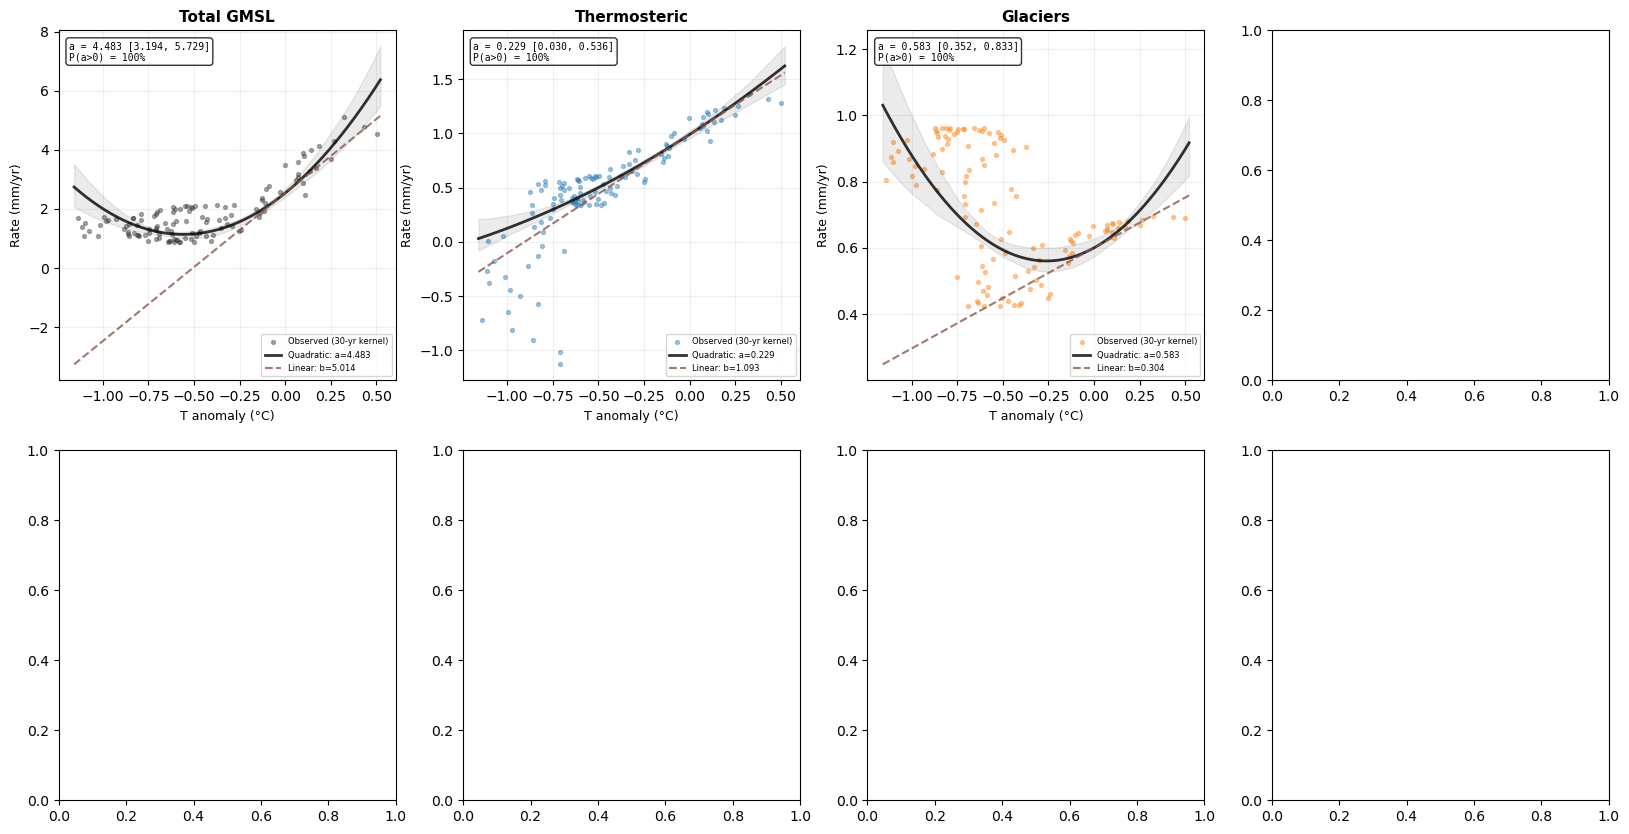

In [44]:
# ── Figure: Component rate vs temperature (all 8 panels) ──
panel_order = ['Total GMSL', 'Thermosteric', 'Glaciers',
               'Greenland', 'EAIS', 'Peninsula', 'WAIS', 'TWS']
panel_colors = {
    'Total GMSL':   '#333333',
    'Thermosteric': 'C0',
    'Glaciers':     'C1',
    'Greenland':    'C2',
    'EAIS':         'C3',
    'Peninsula':    'C6',
    'WAIS':         'C4',
    'TWS':          'C5',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# T grid for fitted curves — spans the full Frederikse range
T_grid = np.linspace(T_annual.min() - 0.05, T_annual.max() + 0.05, 200)

for ax, name in zip(axes.flat, panel_order):
    color = panel_colors[name]

    if name in rates:
        r = rates[name]
        T_r = T_for_rate[name]
        valid = np.isfinite(r)
        # Label reflects kernel bandwidth used
        span_used = SPAN_IMBIE if name in ('EAIS', 'Peninsula', 'WAIS') else SPAN_FRED
        ax.scatter(T_r[valid], r[valid], s=8, alpha=0.4, color=color,
                   zorder=2, label=f'Observed ({int(span_used)}-yr kernel)')

    if name in model_rates:
        mr = model_rates[name]
        a_med = np.median(mr['a']) * M_TO_MM
        b_med = np.median(mr['b']) * M_TO_MM
        c_med = np.median(mr['c']) * M_TO_MM

        # Use the component's T range for the fitted curve
        if name in T_for_rate:
            T_comp = T_for_rate[name]
            T_fit = np.linspace(T_comp.min() - 0.02, T_comp.max() + 0.02, 200)
        else:
            T_fit = T_grid

        # Quadratic fit
        rate_quad = a_med * T_fit**2 + b_med * T_fit + c_med
        ax.plot(T_fit, rate_quad, '-', color='k', lw=2.0, alpha=0.8,
                label=f'Quadratic: a={a_med:.3f}', zorder=4)

        # Posterior uncertainty envelope
        n_draw = min(500, len(mr['a']))
        rate_draws = np.array([
            mr['a'][k] * M_TO_MM * T_fit**2 +
            mr['b'][k] * M_TO_MM * T_fit +
            mr['c'][k] * M_TO_MM
            for k in range(n_draw)
        ])
        ax.fill_between(T_fit,
                         np.percentile(rate_draws, 5, axis=0),
                         np.percentile(rate_draws, 95, axis=0),
                         color='k', alpha=0.08, zorder=3)

        # Linear overlay: rate = b·T + c (using quadratic posterior b, c)
        rate_lin = b_med * T_fit + c_med
        ax.plot(T_fit, rate_lin, '--', color='C5', lw=1.5, alpha=0.8,
                label=f'Linear: b={b_med:.3f}', zorder=4)

        # Annotation
        a_p5, a_p95 = np.percentile(mr['a'] * M_TO_MM, [5, 95])
        p_a_positive = np.mean(mr['a'] > 0) * 100
        ax.text(0.03, 0.97,
                f'a = {a_med:.3f} [{a_p5:.3f}, {a_p95:.3f}]\n'
                f'P(a>0) = {p_a_positive:.0f}%',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.8))
    else:
        ax.text(0.03, 0.97, 'No GMST fit\n(deep uncertainty)',
                transform=ax.transAxes, fontsize=8,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                          alpha=0.8))

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('T anomaly (°C)', fontsize=9)
    ax.set_ylabel('Rate (mm/yr)', fontsize=9)
    ax.legend(fontsize=6, loc='lower right')
    ax.grid(True, alpha=0.2)

fig.suptitle('Component Rate of Sea-Level Change vs Global Temperature',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_rate_vs_temperature.png', dpi=200,
            bbox_inches='tight')
plt.show()
print('Saved: component_rate_vs_temperature.png')

In [ ]:
# ── Endpoint rate discrepancy: observed vs model-implied at record end ──
# For each fitted component, compare:
#   - Observed rate from compute_kinematics() at the last year of the record
#   - Model-implied rate from Bayesian posterior: rate = a·T² + b·T + c

print('ENDPOINT RATE DISCREPANCY')
print('Observed (kernel-smoothed) vs model-implied rate at end of record')
print('='*95)
print(f'{"Component":15s} {"End yr":>6s} {"T (°C)":>8s} '
      f'{"Obs rate":>12s} {"Model rate":>14s} {"Discrepancy":>14s} {"Rel. (%)":>9s}')
print(f'{"":15s} {"":>6s} {"":>8s} '
      f'{"(mm/yr)":>12s} {"med [5,95]":>14s} {"(mm/yr)":>14s} {"":>9s}')
print('-'*95)

discrepancies = {}

for name in ['Total GMSL', 'Thermosteric', 'Glaciers', 'Greenland',
             'EAIS', 'Peninsula']:
    # --- Observed rate at endpoint ---
    r = rates[name]
    T_r = T_for_rate[name]
    yr = fred_year if len(T_r) == len(fred_year) else eais_year

    # Find last valid (non-NaN) rate estimate
    valid = np.isfinite(r)
    if not np.any(valid):
        print(f'{name:15s}: no valid rate estimates')
        continue

    last_valid_idx = np.where(valid)[0][-1]
    rate_obs = r[last_valid_idx]          # mm/yr
    T_end = T_r[last_valid_idx]           # °C
    yr_end = yr[last_valid_idx]

    # --- Model-implied rate from posterior ---
    mr = model_rates[name]
    # Posterior samples are in meters; convert to mm/yr
    rate_model_samples = (mr['a'] * T_end**2 + mr['b'] * T_end + mr['c']) * M_TO_MM
    rate_model_med = np.median(rate_model_samples)
    rate_model_5, rate_model_95 = np.percentile(rate_model_samples, [5, 95])

    # Discrepancy
    disc = rate_obs - rate_model_med
    rel_disc = disc / rate_obs * 100 if abs(rate_obs) > 1e-6 else np.nan

    discrepancies[name] = {
        'yr_end': yr_end,
        'T_end': T_end,
        'rate_obs': rate_obs,
        'rate_model_med': rate_model_med,
        'rate_model_5': rate_model_5,
        'rate_model_95': rate_model_95,
        'discrepancy': disc,
        'rel_disc': rel_disc,
    }

    print(f'{name:15s} {yr_end:6.0f} {T_end:8.3f} '
          f'{rate_obs:12.3f} {rate_model_med:7.3f} [{rate_model_5:.3f}, {rate_model_95:.3f}] '
          f'{disc:+10.3f} {rel_disc:+9.1f}')

# Also show WAIS and TWS (no model fit, just observed rate)
print('-'*95)
for name in ['WAIS', 'TWS']:
    r = rates[name]
    T_r = T_for_rate[name]
    yr = fred_year if len(T_r) == len(fred_year) else eais_year
    valid = np.isfinite(r)
    if np.any(valid):
        last_idx = np.where(valid)[0][-1]
        print(f'{name:15s} {yr[last_idx]:6.0f} {T_r[last_idx]:8.3f} '
              f'{r[last_idx]:12.3f} {"(no fit)":>14s} {"—":>14s} {"—":>9s}')

# --- Summary ---
print('\n' + '='*95)
print('INTERPRETATION')
print('-'*95)
disc_vals = {k: v['discrepancy'] for k, v in discrepancies.items()}
largest = max(disc_vals, key=lambda k: abs(disc_vals[k]))
print(f'Largest absolute discrepancy: {largest} ({disc_vals[largest]:+.3f} mm/yr)')
print()
print('Positive discrepancy → observed rate > model rate → projection starts too slow')
print('Negative discrepancy → observed rate < model rate → projection starts too fast')
print()

# Check if observed rate falls within model 90% CI
print('Does the observed rate fall within the model 90% CI?')
for name, d in discrepancies.items():
    inside = d['rate_model_5'] <= d['rate_obs'] <= d['rate_model_95']
    status = 'YES' if inside else 'NO'
    print(f'  {name:15s}: {status}')


In [ ]:
# ── Figure: Observed vs model-implied rate time series (all components) ──
# Overlay kernel-smoothed observed rate with model-implied rate = a·T(t)² + b·T(t) + c
# to diagnose whether endpoint discrepancy is an edge effect or a systematic misfit.

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, name in zip(axes.flat, panel_order):
    color = panel_colors[name]

    # --- Observed kernel-smoothed rate ---
    if name in rates:
        r_obs = rates[name]
        r_se = rates_se[name]
        yr = fred_year if name not in ('EAIS', 'Peninsula', 'WAIS') else eais_year
        valid = np.isfinite(r_obs)

        ax.plot(yr[valid], r_obs[valid], '-', color=color, lw=2.0,
                label=f'Observed (kernel-smoothed)', zorder=3)
        # ±1σ uncertainty band
        ax.fill_between(yr[valid],
                         r_obs[valid] - r_se[valid],
                         r_obs[valid] + r_se[valid],
                         color=color, alpha=0.15, zorder=2)

    # --- Model-implied rate from Bayesian posterior ---
    if name in model_rates:
        mr = model_rates[name]

        # Get T(t) on the appropriate time grid
        if name in ('EAIS', 'Peninsula'):
            yr_model = eais_year
            T_t = T_annual_imbie
        else:
            yr_model = fred_year
            T_t = T_annual

        # Posterior median rate at each year
        rate_model_med = (np.median(mr['a']) * T_t**2
                          + np.median(mr['b']) * T_t
                          + np.median(mr['c'])) * M_TO_MM

        # Posterior 90% CI at each year
        n_draw = min(500, len(mr['a']))
        rate_draws = np.array([
            (mr['a'][k] * T_t**2 + mr['b'][k] * T_t + mr['c'][k]) * M_TO_MM
            for k in range(n_draw)
        ])
        rate_p5 = np.percentile(rate_draws, 5, axis=0)
        rate_p95 = np.percentile(rate_draws, 95, axis=0)

        ax.plot(yr_model, rate_model_med, '--', color='k', lw=2.0,
                label='Model: a·T²+b·T+c', zorder=4)
        ax.fill_between(yr_model, rate_p5, rate_p95,
                         color='k', alpha=0.06, zorder=1)

    elif name in ('WAIS', 'TWS'):
        note = 'No GMST fit\n(deep uncertainty)' if name == 'WAIS' \
               else 'No GMST fit\n(non-climatic)'
        ax.text(0.5, 0.5, note, transform=ax.transAxes, fontsize=9,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Rate (mm/yr)', fontsize=9)
    ax.legend(fontsize=6, loc='upper left')
    ax.grid(True, alpha=0.2)

    # Mark the edge-effect zone (last span/2 years)
    if name in rates:
        span_used = SPAN_IMBIE if name in ('EAIS', 'Peninsula', 'WAIS') else SPAN_FRED
        yr_arr = eais_year if name in ('EAIS', 'Peninsula', 'WAIS') else fred_year
        edge_start = yr_arr[-1] - span_used / 2
        ax.axvspan(edge_start, yr_arr[-1], color='grey', alpha=0.07, zorder=0)
        ax.axvspan(yr_arr[0], yr_arr[0] + span_used / 2,
                   color='grey', alpha=0.07, zorder=0)

fig.suptitle('Rate of Sea-Level Change: Observed (kernel-smoothed) vs Model-Implied\n'
             'Grey shading = edge-effect zones (within half-bandwidth of record boundaries)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(f'{FIG_DIR}/component_rate_timeseries_obs_vs_model.png', dpi=200,
            bbox_inches='tight')
plt.show()
print('Saved: component_rate_timeseries_obs_vs_model.png')

In [ ]:
# ── Model selection: linear vs quadratic for each component ──
# Fit linear models (a=0) by passing I2_obs=0 to fit_bayesian_level

# Frederikse components use the full design vectors
I2_zero_fred = np.zeros_like(I2_obs)
# IMBIE components use the IMBIE design vectors
I2_zero_imbie = np.zeros_like(I2_imbie)

# Component data, design vectors, and prior configs
fit_specs = {
    'Thermosteric': dict(
        H_obs=steric_rebase, sigma_obs=steric_sigma,
        I2=I2_zero_fred, I1=I1_obs, I0=I0_obs,
        priors=dict(
            prior_scale_a=PRIOR_SCALE_A_THERMO,
            prior_scale_b=PRIOR_SCALE_B_THERMO,
            prior_c_mean=PRIOR_C_MEAN_THERMO,
            prior_c_sigma=PRIOR_C_SIGMA_THERMO,
            prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO,
            prior_H0_sigma=PRIOR_H0_SIGMA_THERMO,
        ),
    ),
    'Glaciers': dict(
        H_obs=glacier_rebase, sigma_obs=glacier_sigma,
        I2=I2_zero_fred, I1=I1_obs, I0=I0_obs,
        priors=dict(
            prior_scale_a=PRIOR_SCALE_A_GLACIER,
            prior_scale_b=PRIOR_SCALE_B_GLACIER,
            prior_c_mean=PRIOR_C_MEAN_GLACIER,
            prior_c_sigma=PRIOR_C_SIGMA_GLACIER,
            prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_GLACIER,
            prior_H0_sigma=PRIOR_H0_SIGMA_GLACIER,
        ),
    ),
    'Greenland': dict(
        H_obs=greenland_rebase, sigma_obs=greenland_sigma,
        I2=I2_zero_fred, I1=I1_obs, I0=I0_obs,
        priors=dict(
            prior_scale_a=PRIOR_SCALE_A_GR,
            prior_scale_b=PRIOR_SCALE_B_GR,
            prior_c_mean=PRIOR_C_MEAN_GR,
            prior_c_sigma=PRIOR_C_SIGMA_GR,
            prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_GR,
            prior_H0_sigma=PRIOR_H0_SIGMA_GR,
        ),
    ),
    'EAIS': dict(
        H_obs=eais_rebase, sigma_obs=eais_sigma,
        I2=I2_zero_imbie, I1=I1_imbie, I0=I0_imbie,
        priors=dict(
            prior_scale_a=PRIOR_SCALE_A_EAIS,
            prior_scale_b=PRIOR_SCALE_B_EAIS,
            prior_c_mean=PRIOR_C_MEAN_EAIS,
            prior_c_sigma=PRIOR_C_SIGMA_EAIS,
            prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_EAIS,
            prior_H0_sigma=PRIOR_H0_SIGMA_EAIS,
        ),
    ),
    'Peninsula': dict(
        H_obs=pen_rebase, sigma_obs=pen_sigma,
        I2=I2_zero_imbie, I1=I1_imbie, I0=I0_imbie,
        priors=dict(
            prior_scale_a=PRIOR_SCALE_A_PEN,
            prior_scale_b=PRIOR_SCALE_B_PEN,
            prior_c_mean=PRIOR_C_MEAN_PEN,
            prior_c_sigma=PRIOR_C_SIGMA_PEN,
            prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_PEN,
            prior_H0_sigma=PRIOR_H0_SIGMA_PEN,
        ),
    ),
    'Total GMSL': dict(
        H_obs=gmsl_rebase, sigma_obs=gmsl_sigma,
        I2=I2_zero_fred, I1=I1_obs, I0=I0_obs,
        priors=dict(
            prior_scale_a=PRIOR_SCALE_A_TOTAL,
            prior_scale_b=0.010,
            prior_c_mean=0.002,
            prior_c_sigma=0.005,
            prior_sigma_extra_scale=0.005,
            prior_H0_sigma=0.050,
        ),
    ),
}

linear_results = {}

for name, spec in fit_specs.items():
    print(f'\n{"="*60}')
    print(f'Linear fit: {name}')
    print(f'{"="*60}')

    result_lin = fit_bayesian_level(
        H_obs=spec['H_obs'],
        sigma_obs=spec['sigma_obs'],
        I2_obs=spec['I2'],       # zeroed → linear model
        I1_obs=spec['I1'],
        I0_obs=spec['I0'],
        n_samples=4000,
        n_walkers=32,
        n_burnin=2000,
        thin=2,
        seed=100 + hash(name) % 1000,
        progress=True,
        **spec['priors'],
    )
    linear_results[name] = result_lin

print('\nAll linear fits complete.')

In [ ]:
# ── Model comparison: full record vs observation-constrained ──
# For each component, compare:
#   1. Full-record quadratic (1900–2018 for Frederikse components)
#   2. Obs-constrained quadratic (restricted to well-observed period)
#   3. Obs-constrained linear (same restricted period)

comp_order = ['Total GMSL', 'Thermosteric', 'Glaciers',
              'Greenland', 'EAIS', 'Peninsula']

# Full-record quadratic fit results (from earlier cells)
quadratic_results_map = {
    'Total GMSL':   result_total,
    'Thermosteric': result_thermo,
    'Glaciers':     result_glacier,
    'Greenland':    result_greenland,
    'EAIS':         result_eais,
    'Peninsula':    result_peninsula,
}

# Number of observations for each full-record fit
n_obs_map = {
    'Total GMSL':   len(fred_year),
    'Thermosteric': len(fred_year),
    'Glaciers':     len(fred_year),
    'Greenland':    len(fred_year),
    'EAIS':         len(eais_year),
    'Peninsula':    len(pen_year),
}

a_total_med = np.median(a_total) * M_TO_MM

# --- Table 1: Full-record vs obs-constrained quadratic coefficients ---
print('TABLE 1: QUADRATIC ACCELERATION COEFFICIENT a (mm/yr/°C²)')
print('Full record vs observation-constrained period')
print('='*105)
print(f'{"Component":15s} {"Full record":>30s}   {"Obs-constrained":>30s}   {"Consistent?":>12s}')
print(f'{"":15s} {"a_med [5%, 95%]  (period)":>30s}   {"a_med [5%, 95%]  (period)":>30s}')
print('-'*105)

for name in comp_order:
    # Full-record quadratic
    res_full = quadratic_results_map[name]
    a_full = res_full.posterior_samples[:, 0] * M_TO_MM
    a_f_med = np.median(a_full)
    a_f_5, a_f_95 = np.percentile(a_full, [5, 95])
    n_full = n_obs_map[name]

    if name in ['EAIS', 'Peninsula']:
        period_full = '1992\u20132020'
    else:
        period_full = '1900\u20132018'

    # Obs-constrained quadratic
    if name in obs_results:
        or_ = obs_results[name]
        a_obs = or_['result'].posterior_samples[:, 0] * M_TO_MM
        a_o_med = np.median(a_obs)
        a_o_5, a_o_95 = np.percentile(a_obs, [5, 95])
        n_obs_c = or_['n_obs']
        w = or_['window']
        period_obs = f'{w[0]}\u2013{w[1]}'

        # Check consistency: do 90% CIs overlap?
        overlap = (a_f_5 < a_o_95) and (a_o_5 < a_f_95)
        status = 'Yes' if overlap else 'NO'

        obs_str = (f'{a_o_med:6.3f} [{a_o_5:6.3f},{a_o_95:6.3f}]'
                   f'  ({period_obs}, n={n_obs_c})')
    else:
        obs_str = 'N/A'
        status = ''

    full_str = (f'{a_f_med:6.3f} [{a_f_5:6.3f},{a_f_95:6.3f}]'
                f'  ({period_full}, n={n_full})')

    print(f'  {name:13s}  {full_str:>30s}   {obs_str:>30s}   {status:>12s}')

print('='*105)

# --- Table 2: Model selection (obs-constrained only) ---
print('\n\nTABLE 2: MODEL SELECTION — OBSERVATION-CONSTRAINED PERIODS ONLY')
print('='*105)
print(f'{"Component":15s} {"Period":>11s} {"n":>4s} {"R\u00b2_lin":>7s} {"R\u00b2_quad":>8s} '
      f'{"ΔBIC":>8s} {"a_med":>8s} {"P(a>0)":>7s} {"a/a_total":>10s}  '
      f'{"Verdict":>12s}')
print('-'*105)

for name in comp_order:
    or_ = obs_results[name]
    res_q = or_['result']
    w = or_['window']
    n_obs_c = or_['n_obs']

    # Get obs-constrained linear result
    if name in obs_linear and obs_linear[name] is not None:
        res_l = obs_linear[name]
    elif name in linear_results:
        res_l = linear_results[name]
    else:
        continue

    r2_q = res_q.r2
    r2_l = res_l.r2

    rss_q = np.sum(res_q.residuals**2)
    rss_l = np.sum(res_l.residuals**2)
    k_q = 5  # a, b, c, sigma_extra, H0
    k_l = 4  # b, c, sigma_extra, H0
    bic_q = n_obs_c * np.log(rss_q / n_obs_c) + k_q * np.log(n_obs_c)
    bic_l = n_obs_c * np.log(rss_l / n_obs_c) + k_l * np.log(n_obs_c)
    delta_bic = bic_l - bic_q

    a_post = res_q.posterior_samples[:, 0] * M_TO_MM
    a_med = np.median(a_post)
    p_a_pos = np.mean(a_post > 0) * 100
    a_frac = a_med / a_total_med * 100 if abs(a_total_med) > 1e-6 else 0.0

    if delta_bic > 10:
        verdict = 'QUAD strong'
    elif delta_bic > 2:
        verdict = 'QUAD weak'
    elif delta_bic > -2:
        verdict = 'Inconclusive'
    elif delta_bic > -10:
        verdict = 'LINEAR weak'
    else:
        verdict = 'LINEAR strong'

    period_str = f'{w[0]}\u2013{w[1]}'
    print(f'  {name:13s} {period_str:>11s} {n_obs_c:4d} {r2_l:7.4f} {r2_q:8.4f} '
          f'{delta_bic:+8.1f} {a_med:8.4f} {p_a_pos:6.1f}% {a_frac:9.1f}%  '
          f'{verdict:>12s}')

print('='*105)
print('\nΔBIC = BIC(linear) \u2212 BIC(quadratic); positive favors quadratic')
print(f'Total GMSL a_total (full record) = {a_total_med:.3f} mm/yr/\u00b0C\u00b2')
print('\nKey question: is the quadratic acceleration detectable from')
print('observations alone, or does it require model-reconstructed pre-1960 data?')

In [ ]:
# ── Figure: Rate vs T with Bayesian linear + quadratic fits (all components) ──
# Toggle SHOW_FITS to control which fits are displayed:
#   'full'  — full-record fits only (includes model-reconstructed data)
#   'obs'   — observation-constrained fits only
#   'both'  — overlay both for comparison
# Marker shapes: circles = observational period, triangles = model-reconstructed

SHOW_FITS = 'both'   # ← change this to 'full', 'obs', or 'both'

# ---------------------------------------------------------------------------
# Build lookup dicts so we can access fit results uniformly by component name
# ---------------------------------------------------------------------------

# Full-record quadratic fit results
full_quad_results = {
    'Thermosteric': result_thermo,
    'Glaciers':     result_glacier,
    'Greenland':    result_greenland,
    'Total GMSL':   result_total,
    'EAIS':         result_eais,
    'Peninsula':    result_peninsula,
}

# Full-record linear fit results
full_linear_results = linear_results   # already a dict keyed by component name

# Obs-constrained quadratic fit results
obs_quad_results = {name: obs_results[name]['result']
                    for name in obs_results}

# Obs-constrained linear fit results
obs_lin_results = obs_linear   # already a dict keyed by component name

# Number of observations for BIC calculation
n_obs_full = {
    'Thermosteric': len(fred_year),
    'Glaciers':     len(fred_year),
    'Greenland':    len(fred_year),
    'Total GMSL':   len(fred_year),
    'EAIS':         len(eais_year),
    'Peninsula':    len(pen_year),
}
n_obs_obs = {name: obs_results[name]['n_obs'] for name in obs_results}

# Observation windows (circles inside, triangles outside)
_obs_windows = {
    'Thermosteric': (1957, 2018),
    'Glaciers':     (1961, 2018),
    'Greenland':    (1972, 2018),
    'Total GMSL':   (1957, 2018),
    'EAIS':         (1992, 2020),
    'Peninsula':    (1992, 2020),
    'WAIS':         (1992, 2020),
    'TWS':          (1900, 2018),  # all Frederikse-era treated as obs
}

# ---------------------------------------------------------------------------
# Helper: draw quadratic + linear fits on an axis
# ---------------------------------------------------------------------------
def draw_fits(ax, name, T_fit, quad_result, lin_result, n_obs,
              quad_color, lin_color, quad_ls, lin_ls, label_prefix,
              annotate=True, ann_y=0.97):
    """Draw quadratic and linear fits with CI bands and ΔBIC annotation."""

    # --- Quadratic ---
    ps_q = quad_result.posterior_samples
    a_s, b_s, c_s = ps_q[:, 0], ps_q[:, 1], ps_q[:, 2]

    a_med = np.median(a_s) * M_TO_MM
    b_med = np.median(b_s) * M_TO_MM
    c_med = np.median(c_s) * M_TO_MM
    rate_quad = a_med * T_fit**2 + b_med * T_fit + c_med

    ax.plot(T_fit, rate_quad, linestyle=quad_ls, color=quad_color, lw=2.0,
            label=f'{label_prefix}Quadratic', zorder=5)

    n_draw = min(500, len(a_s))
    draws_q = np.array([
        a_s[k] * M_TO_MM * T_fit**2 +
        b_s[k] * M_TO_MM * T_fit +
        c_s[k] * M_TO_MM
        for k in range(n_draw)
    ])
    ax.fill_between(T_fit,
                     np.percentile(draws_q, 5, axis=0),
                     np.percentile(draws_q, 95, axis=0),
                     color=quad_color, alpha=0.06, zorder=3)

    # --- Linear ---
    b_lin = lin_result.posterior_samples[:, 1]
    c_lin = lin_result.posterior_samples[:, 2]
    b_lin_med = np.median(b_lin) * M_TO_MM
    c_lin_med = np.median(c_lin) * M_TO_MM
    rate_lin = b_lin_med * T_fit + c_lin_med

    ax.plot(T_fit, rate_lin, linestyle=lin_ls, color=lin_color, lw=2.0,
            label=f'{label_prefix}Linear', zorder=5)

    n_draw_l = min(500, len(b_lin))
    draws_l = np.array([
        b_lin[k] * M_TO_MM * T_fit + c_lin[k] * M_TO_MM
        for k in range(n_draw_l)
    ])
    ax.fill_between(T_fit,
                     np.percentile(draws_l, 5, axis=0),
                     np.percentile(draws_l, 95, axis=0),
                     color=lin_color, alpha=0.06, zorder=3)

    # --- ΔBIC annotation ---
    if annotate:
        rss_q = np.sum(quad_result.residuals**2)
        rss_l = np.sum(lin_result.residuals**2)
        bic_q = n_obs * np.log(rss_q / n_obs) + 5 * np.log(n_obs)
        bic_l = n_obs * np.log(rss_l / n_obs) + 4 * np.log(n_obs)
        delta_bic = bic_l - bic_q

        p_a_pos = np.mean(a_s > 0)

        ax.text(0.03, ann_y,
                f'{label_prefix}ΔBIC={delta_bic:+.1f}\n'
                f'{label_prefix}a={a_med:.3f}  P(a>0)={p_a_pos:.2f}',
                transform=ax.transAxes, fontsize=6,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.85))

# ---------------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, name in zip(axes.flat, panel_order):
    color = panel_colors[name]

    # Scatter observed rates — circles for obs period, triangles for pre-obs
    if name in rates:
        r = rates[name]
        T_r = T_for_rate[name]
        yr = fred_year if name not in ('EAIS', 'Peninsula', 'WAIS') else eais_year
        valid = np.isfinite(r)

        ow_start, ow_end = _obs_windows.get(name, (yr.min(), yr.max()))
        obs_mask = valid & (yr >= ow_start) & (yr <= ow_end)
        pre_mask = valid & (yr < ow_start)

        norm = plt.Normalize(yr[valid].min(), yr[valid].max())

        # Pre-observational (model-reconstructed): triangles
        if pre_mask.any():
            ax.scatter(T_r[pre_mask], r[pre_mask], c=yr[pre_mask],
                       s=14, alpha=0.45, cmap='viridis', norm=norm,
                       marker='^', edgecolors='dimgray', linewidths=0.4,
                       zorder=2, label='Model-reconstructed')

        # Observational period: circles
        if obs_mask.any():
            sc = ax.scatter(T_r[obs_mask], r[obs_mask], c=yr[obs_mask],
                            s=14, alpha=0.55, cmap='viridis', norm=norm,
                            marker='o', edgecolors='dimgray', linewidths=0.4,
                            zorder=2, label='Observed')

    has_full = name in full_quad_results and name in full_linear_results
    has_obs = name in obs_quad_results and name in obs_lin_results

    if has_full or has_obs:
        # Temperature grid for fit curves
        if name in T_for_rate:
            T_comp = T_for_rate[name]
            T_fit = np.linspace(T_comp.min() - 0.02, T_comp.max() + 0.02, 200)
        else:
            T_fit = np.linspace(-0.3, 0.6, 200)

        if SHOW_FITS == 'full' and has_full:
            draw_fits(ax, name, T_fit,
                      full_quad_results[name], full_linear_results[name],
                      n_obs_full[name],
                      quad_color='tab:red', lin_color='tab:red',
                      quad_ls='-', lin_ls='--',
                      label_prefix='', annotate=True)

        elif SHOW_FITS == 'obs' and has_obs:
            draw_fits(ax, name, T_fit,
                      obs_quad_results[name], obs_lin_results[name],
                      n_obs_obs[name],
                      quad_color='tab:blue', lin_color='tab:blue',
                      quad_ls='-', lin_ls='--',
                      label_prefix='', annotate=True)

        elif SHOW_FITS == 'both':
            if has_full:
                draw_fits(ax, name, T_fit,
                          full_quad_results[name], full_linear_results[name],
                          n_obs_full[name],
                          quad_color='tab:red', lin_color='tab:red',
                          quad_ls='-', lin_ls='--',
                          label_prefix='Full: ', annotate=True, ann_y=0.97)
            if has_obs:
                draw_fits(ax, name, T_fit,
                          obs_quad_results[name], obs_lin_results[name],
                          n_obs_obs[name],
                          quad_color='tab:blue', lin_color='tab:blue',
                          quad_ls='-', lin_ls='--',
                          label_prefix='Obs: ', annotate=True,
                          ann_y=0.70 if has_full else 0.97)

    elif name in ('WAIS', 'TWS'):
        note = ('No GMST fit\n(deep uncertainty)' if name == 'WAIS'
                else 'No GMST fit\n(non-climatic)')
        ax.text(0.5, 0.5, note, transform=ax.transAxes, fontsize=9,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                          alpha=0.8))

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('T anomaly (°C)', fontsize=9)
    ax.set_ylabel('Rate (mm/yr)', fontsize=9)
    ax.legend(fontsize=5, loc='lower right')
    ax.grid(True, alpha=0.2)

# Colorbar for year
cbar_ax = fig.add_axes([0.92, 0.15, 0.012, 0.7])
sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(1900, 2020))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Year')

# Title reflects mode
title_suffix = {'full': '(full record)',
                'obs': '(observation-constrained)',
                'both': '(red = full record, blue = obs-constrained)'}
fig.suptitle(f'Component Rate of Sea-Level Change vs Global Temperature\n'
             f'Markers: ● observed  ▲ model-reconstructed  |  '
             f'{title_suffix.get(SHOW_FITS, "")}',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.91, 0.95])
plt.savefig(f'{FIG_DIR}/component_rate_vs_T_model_selection.png', dpi=300,
            bbox_inches='tight')
plt.show()
print(f'Saved: component_rate_vs_T_model_selection.png  (SHOW_FITS={SHOW_FITS!r})')

## Uncertainty taper: inflating $\sigma$ for older, less-constrained data

The Frederikse et al. (2020) formal uncertainties ($\sigma$) reflect the internal consistency
of each component reconstruction but do not fully account for **structural uncertainty** —
i.e., what processes and data sources are missing in the earlier record. Pre-satellite data
for most components rely on sparse observations supplemented by models, and the formal $\sigma$
values do not always distinguish these from the well-observed modern era.

We apply a multiplicative inflation factor that linearly tapers from $f_\mathrm{max}$ at the
start of the record to 1.0 at a component-specific reference year $t_\mathrm{ref}$:

$$\sigma_\mathrm{inflated}(t) = \sigma(t) \times \left[1 + (f_\mathrm{max} - 1)\,\frac{\max(0,\; t_\mathrm{ref} - t)}{t_\mathrm{ref} - t_\mathrm{start}}\right]$$

At $t \geq t_\mathrm{ref}$, the original $\sigma$ is unchanged. The taper down-weights older data
in the likelihood without discarding it entirely (cf. the observation-constrained fits above).

### Reference years ($t_\mathrm{ref}$) and justification

| Component | $t_\mathrm{ref}$ | Rationale |
|-----------|:---------:|-----------|
| **Thermosteric** | 2005 | Argo float array achieved near-global coverage (~2005), providing full-depth, year-round sampling. Pre-Argo subsurface temperature data (XBTs, ship-based CTDs) have sparse Southern Ocean coverage and known fall-rate biases. |
| **Glaciers** | 2000 | Satellite-era glacier inventories (Landsat, ASTER) and geodetic mass-balance estimates become widely available in the early 2000s. Pre-2000 estimates rely more heavily on sparse field measurements extrapolated via Marzeion et al. models. |
| **Greenland** | 2002 | GRACE gravity mission launched 2002, providing direct, ice-sheet-wide mass balance. Pre-GRACE estimates combine sparse aerial photography (Kjeldsen et al.) with regional climate models; formal uncertainties likely understate true error. |
| **Total GMSL** | 2000 | Satellite altimetry (TOPEX/Jason) begins 1993 with global coverage. By ~2000, tide-gauge-altimetry cross-calibration is mature. Pre-satellite GMSL relies on geographically biased tide gauge networks. |
| **EAIS / Peninsula** | — | Already satellite-era only (IMBIE, 1992–2020). No taper applied. |

### Glacier prior: symmetric Normal on $a$

For glaciers, we relax the default $a \geq 0$ (Exponential) prior to a symmetric
$a \sim \mathcal{N}(0, \sigma_a)$ prior that allows $a < 0$. This is physically justified:
glaciers are a **finite, depleting reservoir**. Under continued warming, lower-elevation glaciers
disappear entirely while high-elevation accumulation zones receive increased precipitation,
causing the aggregate glacier contribution to SLR to **peak and then decline**. In the extreme
limit (all glaciers gone), the contribution to SLR is zero regardless of temperature.

This saturation behavior is well-documented in process-model projections:
- **Rounce et al. (2023, Science)**: Global glacier projections under SSP scenarios show
  mass loss rates peaking mid-century and declining as glaciers deplete, with 26±6% of
  glacier mass lost by 2100 under +1.5°C but up to 41±11% under +4°C.
- **Huss & Hock (2018, Nature Geoscience)**: Project that small glaciers in many regions
  will largely disappear by 2100, reducing the available ice reservoir.
- **Marzeion et al. (2012, The Cryosphere)**: Show that glacier mass loss rate is not
  monotonically increasing with temperature when reservoir depletion is accounted for.

Enforcing $a \geq 0$ would preclude the data from revealing this saturation signal.

### Sensitivity analysis

We test $f_\mathrm{max} \in \{1, 2, 3\}$:
- $f_\mathrm{max} = 1$: no inflation (original $\sigma$, baseline)
- $f_\mathrm{max} = 2$: earliest data down-weighted by $2\times$ (moderate)
- $f_\mathrm{max} = 3$: earliest data down-weighted by $3\times$ (aggressive)

If conclusions are robust to $f_\mathrm{max}$, the results do not depend on older,
less-constrained data. If they change substantially, that itself is informative.

In [ ]:
# ── Uncertainty taper: implementation and sensitivity analysis ──
# Restrict each component to its observational window (same as cell 57),
# THEN apply σ inflation within that window.  This avoids fitting
# model-reconstructed data even with down-weighting.

# ── Observation windows (same as cell 57) ──
TAPER_OBS_WINDOWS = {
    'Thermosteric': (1957, 2018),   # in situ subsurface obs
    'Glaciers':     (1961, 2018),   # Zemp observational consensus
    'Greenland':    (1972, 2018),   # Mouginot satellite + aerial
    'Total GMSL':   (1957, 2018),   # tide gauges well-distributed
}

# ── Reference years: when high-quality obs begin within each window ──
TAPER_REFS = {
    'Thermosteric': 2005,   # Argo global coverage
    'Glaciers':     2000,   # satellite-era geodetic inventories
    'Greenland':    2002,   # GRACE launch
    'Total GMSL':   2000,   # satellite altimetry maturity
}

# ── Symmetric prior on `a` for components with physically justified saturation ──
# Glaciers: finite reservoir → rate must peak and decline under continued warming
# (Rounce et al. 2023, Hock et al. 2019, Huss & Hock 2018).
# All other components: retain Exponential(a≥0) prior.
SYMMETRIC_A = {
    'Thermosteric': False,
    'Glaciers':     True,    # rate saturates as glaciers deplete
    'Greenland':    False,
    'Total GMSL':   False,
}

def apply_sigma_taper(sigma, years, t_ref, f_max):
    """Inflate sigma for data before t_ref with linear taper.

    σ_inflated(t) = σ(t) × [1 + (f_max − 1) × max(0, (t_ref − t) / (t_ref − t_start))]

    At t >= t_ref: σ unchanged.  At t_start: σ × f_max.
    """
    if f_max <= 1.0:
        return sigma.copy()
    t_start = years[0]
    if t_ref <= t_start:
        return sigma.copy()
    factor = np.ones_like(sigma, dtype=float)
    pre = years < t_ref
    factor[pre] = 1.0 + (f_max - 1.0) * (t_ref - years[pre]) / (t_ref - t_start)
    return sigma * factor

# ── Component full-record data (for restricting) ──
# Greenland uses Mouginot (1972–2018) on its own time grid.
taper_component_data_full = {
    'Thermosteric': (fred_steric, fred_steric_sigma, fred_year),
    'Glaciers':     (fred_glaciers, fred_glaciers_sigma, fred_year),
    'Greenland':    (grn_combined, grn_sigma_combined, grn_year_combined),
    'Total GMSL':   (fred_gmsl, fred_gmsl_sigma, fred_year),
}

# Reuse prior configs from observation-constrained cell
taper_prior_configs = prior_configs  # defined in cell 57

# ── Run fits for each f_max value ──
F_MAX_VALUES = [1, 2, 3]

taper_results = {}  # {f_max: {component: {'quad': result, 'linear': result}}}
# Also store the restricted data for reference
taper_restricted_data = {}  # {component: {'years': ..., 'H': ..., 'design': ...}}

for f_max in F_MAX_VALUES:
    print(f'\n{"#"*70}')
    print(f'#  f_max = {f_max}')
    print(f'{"#"*70}')
    taper_results[f_max] = {}

    for name, (H_full, sig_full, yrs_full) in taper_component_data_full.items():
        obs_window = TAPER_OBS_WINDOWS[name]
        t_ref = TAPER_REFS[name]
        use_symmetric = SYMMETRIC_A.get(name, False)

        # ── Step 1: Restrict to observation window ──
        mask = (yrs_full >= obs_window[0]) & (yrs_full <= obs_window[1])
        yrs_r = yrs_full[mask]
        H_r = H_full[mask].copy()
        sig_r = sig_full[mask].copy()

        # Rebase to BASELINE_YEAR within the restricted window
        bl_idx_r = np.argmin(np.abs(yrs_r - BASELINE_YEAR))
        H_r = H_r - H_r[bl_idx_r]

        # Build design vectors for restricted period
        design_r = build_level_design_vectors(
            temperature_monthly=temp_monthly,
            time_monthly=temp_time_monthly,
            obs_times=yrs_r,
        )

        # Cache restricted data (same for all f_max)
        if name not in taper_restricted_data:
            taper_restricted_data[name] = {
                'years': yrs_r, 'H': H_r, 'sigma_orig': sig_r,
                'design': design_r, 'window': obs_window,
            }

        # ── Step 2: Apply taper within the observation window ──
        sig_tapered = apply_sigma_taper(sig_r, yrs_r, t_ref, f_max)

        sym_note = '  [symmetric_a]' if use_symmetric else ''
        if f_max > 1:
            ratio = sig_tapered / sig_r
            print(f'\n  {name} ({obs_window[0]}–{obs_window[1]}): '
                  f'σ taper [{ratio.min():.2f}×, {ratio.max():.2f}×]  '
                  f'(t_ref={t_ref}, f_max={f_max}){sym_note}')
        else:
            print(f'\n  {name} ({obs_window[0]}–{obs_window[1]}): '
                  f'no inflation (f_max=1){sym_note}')

        # Quadratic fit
        res_q = fit_bayesian_level(
            H_obs=H_r,
            sigma_obs=sig_tapered,
            I2_obs=design_r['I2_obs'],
            I1_obs=design_r['I1_obs'],
            I0_obs=design_r['I0_obs'],
            n_samples=4000,
            n_walkers=32,
            n_burnin=2000,
            thin=2,
            seed=600 + f_max * 100 + hash(name) % 1000,
            symmetric_a=use_symmetric,
            **taper_prior_configs[name],
        )

        # Linear fit (I2 = 0) — symmetric_a irrelevant since a is fixed to 0
        res_l = fit_bayesian_level(
            H_obs=H_r,
            sigma_obs=sig_tapered,
            I2_obs=np.zeros_like(design_r['I2_obs']),
            I1_obs=design_r['I1_obs'],
            I0_obs=design_r['I0_obs'],
            n_samples=4000,
            n_walkers=32,
            n_burnin=2000,
            thin=2,
            seed=700 + f_max * 100 + hash(name) % 1000,
            **taper_prior_configs[name],
        )

        taper_results[f_max][name] = {'quad': res_q, 'linear': res_l}

        a_med = np.median(res_q.posterior_samples[:, 0]) * M_TO_MM
        a_p5 = np.percentile(res_q.posterior_samples[:, 0], 5) * M_TO_MM
        a_p95 = np.percentile(res_q.posterior_samples[:, 0], 95) * M_TO_MM
        p_a_pos = np.mean(res_q.posterior_samples[:, 0] > 0)
        p_a_neg = 1.0 - p_a_pos
        print(f'    Quad: a = {a_med:.4f} [{a_p5:.4f}, {a_p95:.4f}] mm/yr/°C²'
              f'  P(a>0)={p_a_pos:.2f}  P(a<0)={p_a_neg:.2f}  R²={res_q.r2:.4f}')
        print(f'    Lin:  R²={res_l.r2:.4f}')

    # EAIS and Peninsula: no taper (already satellite-only)
    taper_results[f_max]['EAIS'] = {'quad': result_eais, 'linear': obs_linear['EAIS']}
    taper_results[f_max]['Peninsula'] = {'quad': result_peninsula, 'linear': obs_linear['Peninsula']}

print('\n\nAll taper fits complete (observation-constrained + σ inflation).')
print(f'Symmetric a prior used for: {[k for k,v in SYMMETRIC_A.items() if v]}')

In [ ]:
# ── Taper sensitivity: summary table + figure ──

# ---------------------------------------------------------------------------
# Helper: get n_obs for BIC calculation (observation-constrained window)
# ---------------------------------------------------------------------------
def _get_n_obs(name):
    if name in taper_restricted_data:
        return len(taper_restricted_data[name]['years'])
    elif name == 'EAIS':
        return len(eais_year)
    elif name == 'Peninsula':
        return len(pen_year)
    return len(fred_year)

# ---------------------------------------------------------------------------
# Table: quadratic coefficient a and model selection across f_max values
# ---------------------------------------------------------------------------
all_components = ['Total GMSL', 'Thermosteric', 'Glaciers', 'Greenland', 'EAIS', 'Peninsula']

print('=' * 115)
print('TAPER SENSITIVITY ANALYSIS (observation-constrained + σ inflation)')
print('=' * 115)
print(f'{"Component":<16} {"Window":>11} {"f_max":>5}  {"a (mm/yr/°C²)":>16}  {"90% CI":>22}  '
      f'{"P(a>0)":>7}  {"R²_quad":>7}  {"R²_lin":>7}  {"ΔBIC":>7}')
print('-' * 115)

for name in all_components:
    n = _get_n_obs(name)
    window = taper_restricted_data[name]['window'] if name in taper_restricted_data \
             else ((1992, 2020) if name in ('EAIS', 'Peninsula') else None)
    window_str = f'{window[0]}–{window[1]}' if window else '—'

    for i, f_max in enumerate(F_MAX_VALUES):
        tr = taper_results[f_max][name]
        res_q = tr['quad']
        res_l = tr['linear']
        a_s = res_q.posterior_samples[:, 0] * M_TO_MM
        a_med = np.median(a_s)
        a_p5 = np.percentile(a_s, 5)
        a_p95 = np.percentile(a_s, 95)
        p_a_pos = np.mean(res_q.posterior_samples[:, 0] > 0)

        # ΔBIC (positive = quadratic preferred)
        rss_q = np.sum(res_q.residuals**2)
        rss_l = np.sum(res_l.residuals**2)
        bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
        bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
        delta_bic = bic_l - bic_q  # positive → quadratic preferred

        label = name if i == 0 else ''
        win_label = window_str if i == 0 else ''
        print(f'{label:<16} {win_label:>11} {f_max:>5}  {a_med:>16.4f}  [{a_p5:>8.4f}, {a_p95:>8.4f}]  '
              f'{p_a_pos:>7.2f}  {res_q.r2:>7.4f}  {res_l.r2:>7.4f}  {delta_bic:>+7.1f}')
    print('-' * 115)

# ---------------------------------------------------------------------------
# Figure: a coefficient vs f_max for each component
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: a coefficient with 90% CI
ax = axes[0]
offsets = np.linspace(-0.15, 0.15, len(all_components))
for j, name in enumerate(all_components):
    a_meds = []
    a_lows = []
    a_highs = []
    for f_max in F_MAX_VALUES:
        a_s = taper_results[f_max][name]['quad'].posterior_samples[:, 0] * M_TO_MM
        a_meds.append(np.median(a_s))
        a_lows.append(np.percentile(a_s, 5))
        a_highs.append(np.percentile(a_s, 95))
    a_meds = np.array(a_meds)
    a_lows = np.array(a_lows)
    a_highs = np.array(a_highs)
    x = np.array(F_MAX_VALUES) + offsets[j]
    ax.errorbar(x, a_meds, yerr=[a_meds - a_lows, a_highs - a_meds],
                fmt='o-', capsize=3, label=name, markersize=5, lw=1.5)

ax.axhline(0, color='k', ls=':', lw=0.8)
ax.set_xlabel('$f_{\\mathrm{max}}$ (σ inflation factor)', fontsize=11)
ax.set_ylabel('$a$ (mm/yr/°C²)', fontsize=11)
ax.set_title('Quadratic coefficient sensitivity to σ taper', fontsize=12)
ax.set_xticks(F_MAX_VALUES)
ax.legend(fontsize=7, loc='best')
ax.grid(True, alpha=0.2)

# Panel 2: ΔBIC vs f_max
ax = axes[1]
for j, name in enumerate(all_components):
    n = _get_n_obs(name)
    dbics = []
    for f_max in F_MAX_VALUES:
        tr = taper_results[f_max][name]
        rss_q = np.sum(tr['quad'].residuals**2)
        rss_l = np.sum(tr['linear'].residuals**2)
        bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
        bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
        dbics.append(bic_l - bic_q)
    x = np.array(F_MAX_VALUES) + offsets[j]
    ax.plot(x, dbics, 'o-', label=name, markersize=5, lw=1.5)

ax.axhline(0, color='k', ls=':', lw=0.8)
ax.axhline(6, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.axhline(-6, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.text(3.25, 6.5, 'Strong evidence\nfor quadratic', fontsize=7, color='grey', va='bottom')
ax.text(3.25, -6.5, 'Strong evidence\nfor linear', fontsize=7, color='grey', va='top')
ax.set_xlabel('$f_{\\mathrm{max}}$ (σ inflation factor)', fontsize=11)
ax.set_ylabel('ΔBIC (linear − quadratic)', fontsize=11)
ax.set_title('Model selection sensitivity to σ taper', fontsize=12)
ax.set_xticks(F_MAX_VALUES)
ax.legend(fontsize=7, loc='best')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/taper_sensitivity_a_and_bic.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: taper_sensitivity_a_and_bic.png')

# ---------------------------------------------------------------------------
# Interpretation
# ---------------------------------------------------------------------------
print('\n' + '=' * 80)
print('INTERPRETATION')
print('=' * 80)
for name in all_components:
    a_vals = [np.median(taper_results[f][name]['quad'].posterior_samples[:, 0] * M_TO_MM)
              for f in F_MAX_VALUES]
    spread = max(a_vals) - min(a_vals)
    base = abs(a_vals[0]) if a_vals[0] != 0 else 1e-6
    pct_change = 100 * spread / base
    p_vals = [np.mean(taper_results[f][name]['quad'].posterior_samples[:, 0] > 0)
              for f in F_MAX_VALUES]
    robust = all(p > 0.90 for p in p_vals) or all(p < 0.10 for p in p_vals)
    status = 'ROBUST' if robust else 'SENSITIVE'
    print(f'  {name:<16}: a ranges {a_vals[0]:.4f} → {a_vals[-1]:.4f} '
          f'({pct_change:.0f}% change)  [{status}]')

In [ ]:
# ── Figure: Rate vs T with taper sensitivity (f_max = 1, 2, 3) ──
# Same layout as the model-selection figure, but showing how quadratic + linear
# fits change across f_max values.  Light → dark blue for f_max 1 → 3.
# All fits use observation-constrained windows (no model-reconstructed data).
# Fit curves are drawn ONLY over the observation-window temperature range.

TAPER_BLUES = {1: '#a6cee3', 2: '#4a90d9', 3: '#08306b'}   # light → dark
TAPER_REDS  = {1: '#fcbba1', 2: '#d94801', 3: '#67000d'}    # for linear fits

# Temperature ranges restricted to observation windows
_taper_T_ranges = {}
for _name in ['Thermosteric', 'Glaciers', 'Greenland', 'Total GMSL']:
    _win = TAPER_OBS_WINDOWS[_name]
    _yr = fred_year
    _mask = (_yr >= _win[0]) & (_yr <= _win[1])
    _taper_T_ranges[_name] = (T_annual[_mask].min(), T_annual[_mask].max())
for _name in ['EAIS', 'Peninsula']:
    _taper_T_ranges[_name] = (T_annual_imbie.min(), T_annual_imbie.max())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, name in zip(axes.flat, panel_order):
    color = panel_colors[name]

    # ── Scatter observed rates (same as cell 63) ──
    if name in rates:
        r = rates[name]
        T_r = T_for_rate[name]
        yr = fred_year if name not in ('EAIS', 'Peninsula', 'WAIS') else eais_year
        valid = np.isfinite(r)

        ow_start, ow_end = _obs_windows.get(name, (yr.min(), yr.max()))
        obs_mask = valid & (yr >= ow_start) & (yr <= ow_end)
        pre_mask = valid & (yr < ow_start)

        norm = plt.Normalize(yr[valid].min(), yr[valid].max())

        if pre_mask.any():
            ax.scatter(T_r[pre_mask], r[pre_mask], c=yr[pre_mask],
                       s=14, alpha=0.35, cmap='viridis', norm=norm,
                       marker='^', edgecolors='dimgray', linewidths=0.4,
                       zorder=2)
        if obs_mask.any():
            ax.scatter(T_r[obs_mask], r[obs_mask], c=yr[obs_mask],
                       s=14, alpha=0.45, cmap='viridis', norm=norm,
                       marker='o', edgecolors='dimgray', linewidths=0.4,
                       zorder=2)

    # ── Overlay fits for each f_max ──
    has_taper = name in taper_restricted_data or name in ('EAIS', 'Peninsula')

    if has_taper and name in _taper_T_ranges:
        # Restrict fit curves to observation-window temperature range
        T_lo, T_hi = _taper_T_ranges[name]
        T_fit = np.linspace(T_lo - 0.02, T_hi + 0.02, 200)

        for f_max in F_MAX_VALUES:
            tr = taper_results[f_max][name]
            res_q = tr['quad']
            res_l = tr['linear']

            ps_q = res_q.posterior_samples
            a_s, b_s, c_s = ps_q[:, 0], ps_q[:, 1], ps_q[:, 2]

            # Quadratic median
            a_med = np.median(a_s) * M_TO_MM
            b_med = np.median(b_s) * M_TO_MM
            c_med = np.median(c_s) * M_TO_MM
            rate_quad = a_med * T_fit**2 + b_med * T_fit + c_med

            qcol = TAPER_BLUES[f_max]
            ax.plot(T_fit, rate_quad, '-', color=qcol, lw=2.0,
                    label=f'Quad f={f_max}', zorder=5 + f_max)

            # Quadratic 90% CI band
            n_draw = min(400, len(a_s))
            draws_q = np.array([
                a_s[k] * M_TO_MM * T_fit**2 +
                b_s[k] * M_TO_MM * T_fit +
                c_s[k] * M_TO_MM
                for k in range(n_draw)
            ])
            ax.fill_between(T_fit,
                             np.percentile(draws_q, 5, axis=0),
                             np.percentile(draws_q, 95, axis=0),
                             color=qcol, alpha=0.06, zorder=3)

            # Linear median
            b_lin = res_l.posterior_samples[:, 1]
            c_lin = res_l.posterior_samples[:, 2]
            rate_lin = np.median(b_lin) * M_TO_MM * T_fit + np.median(c_lin) * M_TO_MM

            lcol = TAPER_REDS[f_max]
            ax.plot(T_fit, rate_lin, '--', color=lcol, lw=1.5,
                    label=f'Lin f={f_max}', zorder=4 + f_max)

        # Annotation: a values for each f_max + obs window
        obs_win = TAPER_OBS_WINDOWS.get(name, (1992, 2020))
        ann_lines = [f'Obs: {obs_win[0]}–{obs_win[1]}']
        for f_max in F_MAX_VALUES:
            a_s = taper_results[f_max][name]['quad'].posterior_samples[:, 0] * M_TO_MM
            a_med = np.median(a_s)
            p_a = np.mean(a_s > 0)
            ann_lines.append(f'f={f_max}: a={a_med:.3f} P(a>0)={p_a:.2f}')
        ax.text(0.03, 0.97, '\n'.join(ann_lines),
                transform=ax.transAxes, fontsize=5.5,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    elif name in ('WAIS', 'TWS'):
        note = ('No GMST fit\n(deep uncertainty)' if name == 'WAIS'
                else 'No GMST fit\n(non-climatic)')
        ax.text(0.5, 0.5, note, transform=ax.transAxes, fontsize=9,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('T anomaly (°C)', fontsize=9)
    ax.set_ylabel('Rate (mm/yr)', fontsize=9)
    ax.legend(fontsize=5, loc='lower right', ncol=2)
    ax.grid(True, alpha=0.2)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.012, 0.7])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(1900, 2020))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Year')

# Legend for line styles
from matplotlib.lines import Line2D
proxy = [
    Line2D([0], [0], color=TAPER_BLUES[1], lw=2, ls='-'),
    Line2D([0], [0], color=TAPER_BLUES[2], lw=2, ls='-'),
    Line2D([0], [0], color=TAPER_BLUES[3], lw=2, ls='-'),
    Line2D([0], [0], color=TAPER_REDS[1], lw=1.5, ls='--'),
    Line2D([0], [0], color=TAPER_REDS[2], lw=1.5, ls='--'),
    Line2D([0], [0], color=TAPER_REDS[3], lw=1.5, ls='--'),
]
fig.legend(proxy,
           ['Quad $f_{max}$=1', 'Quad $f_{max}$=2', 'Quad $f_{max}$=3',
            'Lin $f_{max}$=1', 'Lin $f_{max}$=2', 'Lin $f_{max}$=3'],
           loc='lower center', ncol=6, fontsize=8,
           bbox_to_anchor=(0.45, -0.02))

fig.suptitle('Taper Sensitivity: Rate vs Temperature (observation-constrained)\n'
             'Blue (light→dark) = quadratic fits, Red (light→dark) = linear fits  |  '
             '$f_{\\mathrm{max}}$ = 1, 2, 3',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 0.91, 0.94])
plt.savefig(f'{FIG_DIR}/taper_sensitivity_rate_vs_T.png', dpi=300,
            bbox_inches='tight')
plt.show()
print('Saved: taper_sensitivity_rate_vs_T.png')

## Greenland-specific temperature for ice sheet fits

The Greenland ice sheet responds to **local** surface air temperature (driving SMB) and
ocean temperature at marine-terminating glacier margins (driving discharge), not GMST.
Using GMST as a proxy compresses the effective temperature range by the Arctic amplification
factor (~2.6×) and introduces ~35% unexplained variance from internal variability (NAO,
blocking) that is uncorrelated with GMST.

We use the Berkeley Earth regional temperature estimate for Greenland (59.8–83.6°N,
73.3–11.3°W), which integrates their global kriging field over the Greenland landmass.
The data covers 1784–May 2016 (monthly); annual means are available through 2015.

**Note on data currency:** Berkeley Earth updates their analysis monthly, but the
Greenland regional file available at the time of download extends only to May 2016.
ERA5 reanalysis could extend coverage to the present, but as a model-constrained
product it would undercut the observation-driven approach. We accept the slightly
shorter fit window (1972–2015 instead of 1972–2018) as a reasonable trade-off.

**Implications for the compositional argument:** If part of the apparent aggregate GMSL
nonlinearity arises from projecting a multi-temperature system (each component responds to
a different regional temperature) onto a single GMST axis, then using the correct regional
temperature for Greenland should produce a **tighter** rate–temperature relationship and
possibly change the evidence for/against a quadratic term.

In [ ]:
# ── Greenland-specific temperature: load, rebaseline, compare with GMST ──

# --- Load Greenland regional temperature ---
GR_TEMP_PATH = '../data/raw/gmst/berkEarth_greenland_surfaceT.txt'
df_gr_temp = read_berkeley_earth(GR_TEMP_PATH)

# Annual means (require ≥ 10 months)
gr_annual = df_gr_temp.groupby(df_gr_temp.index.year).agg(
    T_gr=('temperature', 'mean'),
    T_gr_sigma=('temperature_sigma', lambda x: np.sqrt((x**2).mean() / len(x))),
    n_months=('temperature', 'count'),
)
gr_annual = gr_annual[gr_annual['n_months'] >= 10]
gr_annual_years = gr_annual.index.values
gr_annual_T = gr_annual['T_gr'].values
gr_annual_T_sigma = gr_annual['T_gr_sigma'].values

# Rebaseline: 1951-1980 → 1995-2005 (match our convention)
bl_mask_gr = (gr_annual_years >= 1995) & (gr_annual_years <= 2005)
T_gr_offset = gr_annual_T[bl_mask_gr].mean()
T_gr_rebased = gr_annual_T - T_gr_offset

print(f'Greenland temperature: {gr_annual_years[0]}–{gr_annual_years[-1]} '
      f'({len(gr_annual_years)} annual means)')
print(f'  Baseline offset (1951-80 → 1995-2005): {T_gr_offset:.3f} °C')
print(f'  Range (rebased): [{T_gr_rebased.min():.3f}, {T_gr_rebased.max():.3f}] °C')

# --- Compare with GMST: Arctic amplification ---
# The notebook has T_annual on fred_year grid (1995-2005 baseline).
# Build GMST annual array on the same years as Greenland for comparison.
# T_annual is on fred_year (1900-2018); use that.
common_yrs = np.intersect1d(gr_annual_years, fred_year)
mask_gr_common = np.isin(gr_annual_years, common_yrs)
mask_fred_common = np.isin(fred_year, common_yrs)

T_gr_c = T_gr_rebased[mask_gr_common]
T_gl_c = T_annual[mask_fred_common]  # GMST on 1995-2005 baseline from fred_year grid

# Full overlap
AA_coeffs_full = np.polyfit(T_gl_c, T_gr_c, 1)
r_full = np.corrcoef(T_gl_c, T_gr_c)[0, 1]

# 1972-2015 (our fit window)
mask_72 = (common_yrs >= 1972) & (common_yrs <= 2015)
AA_coeffs_72 = np.polyfit(T_gl_c[mask_72], T_gr_c[mask_72], 1)
r_72 = np.corrcoef(T_gl_c[mask_72], T_gr_c[mask_72])[0, 1]

print(f'\nArctic amplification (T_GrIS ≈ AA × GMST):')
print(f'  Full overlap ({common_yrs[0]}–{common_yrs[-1]}):  '
      f'AA = {AA_coeffs_full[0]:.2f}, r = {r_full:.3f}')
print(f'  Fit window (1972–2015):                   '
      f'AA = {AA_coeffs_72[0]:.2f}, r = {r_72:.3f}')
print(f'  Unexplained variance: {(1 - r_72**2)*100:.0f}%')

# --- Figure: T_GrIS vs GMST + amplification line ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Time series comparison
ax = axes[0]
ax.plot(common_yrs, T_gl_c, '-', color='tab:blue', lw=1.5, alpha=0.8, label='GMST')
ax.plot(common_yrs, T_gr_c, '-', color='tab:red', lw=1.5, alpha=0.8, label='Greenland T')
ax.set_xlabel('Year')
ax.set_ylabel('T anomaly (°C, 1995–2005 baseline)')
ax.set_title('GMST vs Greenland Temperature')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 2: Scatter + amplification fit
ax = axes[1]
ax.scatter(T_gl_c[mask_72], T_gr_c[mask_72], s=12, alpha=0.5,
           c=common_yrs[mask_72], cmap='viridis', edgecolors='dimgray',
           linewidths=0.3)
T_fit_line = np.linspace(T_gl_c.min(), T_gl_c.max(), 100)
ax.plot(T_fit_line, AA_coeffs_72[0] * T_fit_line + AA_coeffs_72[1],
        'k--', lw=1.5, label=f'AA = {AA_coeffs_72[0]:.2f}')
ax.plot(T_fit_line, T_fit_line, ':', color='grey', lw=1,
        label='1:1 (no amplification)')
ax.set_xlabel('GMST anomaly (°C)')
ax.set_ylabel('Greenland T anomaly (°C)')
ax.set_title(f'Arctic Amplification (1972–2015, r={r_72:.2f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# Panel 3: Ratio time series
ax = axes[2]
# Smoothed ratio (only when |GMST| > 0.05 to avoid division by near-zero)
ratio_valid = np.abs(T_gl_c) > 0.05
ratio = T_gr_c[ratio_valid] / T_gl_c[ratio_valid]
ax.scatter(common_yrs[ratio_valid], ratio, s=8, alpha=0.4, color='tab:purple')
# 20-year running mean
if len(ratio) > 20:
    kernel = np.ones(20) / 20
    ratio_smooth = np.convolve(ratio, kernel, mode='valid')
    offset = (20 - 1) // 2
    yr_smooth = common_yrs[ratio_valid][offset:offset + len(ratio_smooth)]
    ax.plot(yr_smooth, ratio_smooth, '-', color='tab:purple', lw=2,
            label='20-yr running mean')
ax.axhline(AA_coeffs_72[0], color='k', ls='--', lw=1,
           label=f'Linear AA = {AA_coeffs_72[0]:.2f}')
ax.set_xlabel('Year')
ax.set_ylabel('T_GrIS / GMST')
ax.set_title('Amplification Factor Over Time')
ax.set_ylim(-5, 15)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/greenland_vs_gmst_temperature.png', dpi=200,
            bbox_inches='tight')
plt.show()
print('Saved: greenland_vs_gmst_temperature.png')

In [ ]:
# ── Greenland fits with local temperature: taper sensitivity ──
# Rebuild design vectors using Greenland temperature instead of GMST,
# then run the same taper sensitivity analysis for comparison.

# --- Build monthly Greenland temperature arrays for design vectors ---
# We need monthly T and time arrays for build_level_design_vectors()
gr_monthly_mask = df_gr_temp['temperature'].notna()
gr_temp_monthly = df_gr_temp.loc[gr_monthly_mask, 'temperature'].values
gr_time_monthly = (df_gr_temp.loc[gr_monthly_mask].index.year
                   + (df_gr_temp.loc[gr_monthly_mask].index.month - 0.5) / 12.0)

# Rebaseline monthly Greenland T to 1995-2005
bl_monthly_mask = (gr_time_monthly >= 1995.0) & (gr_time_monthly < 2006.0)
gr_temp_monthly_rebased = gr_temp_monthly - gr_temp_monthly[bl_monthly_mask].mean()

# --- Greenland observation window: 1972-2015 (limited by Berkeley Earth) ---
GR_OBS_WINDOW_LOCAL = (1972, 2015)
GR_TAPER_REF = 2002  # GRACE launch

# Restrict combined Greenland data to observation window
mask_gr_obs = (grn_year_combined >= GR_OBS_WINDOW_LOCAL[0]) & (grn_year_combined <= GR_OBS_WINDOW_LOCAL[1])
yrs_gr_local = grn_year_combined[mask_gr_obs]
H_gr_local = grn_combined[mask_gr_obs].copy()
sig_gr_local = grn_sigma_combined[mask_gr_obs].copy()

# Rebase to BASELINE_YEAR
bl_idx_gr = np.argmin(np.abs(yrs_gr_local - BASELINE_YEAR))
H_gr_local = H_gr_local - H_gr_local[bl_idx_gr]

# Build design vectors with GREENLAND temperature
design_gr_local = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly_rebased,
    time_monthly=gr_time_monthly,
    obs_times=yrs_gr_local,
)

print(f'Greenland local-T design vectors: {len(yrs_gr_local)} obs '
      f'({GR_OBS_WINDOW_LOCAL[0]}–{GR_OBS_WINDOW_LOCAL[1]})')
print(f'  I2 range: [{design_gr_local["I2_obs"].min():.3f}, '
      f'{design_gr_local["I2_obs"].max():.3f}]')
print(f'  I1 range: [{design_gr_local["I1_obs"].min():.3f}, '
      f'{design_gr_local["I1_obs"].max():.3f}]')

# Also build GMST-based design vectors for the same 1972-2015 window for comparison
design_gr_gmst = build_level_design_vectors(
    temperature_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=yrs_gr_local,
)

# --- Run taper sensitivity with Greenland temperature ---
gr_local_taper_results = {}  # {f_max: {'quad': ..., 'linear': ...}}
gr_gmst_taper_results = {}   # same window but with GMST for comparison

for f_max in F_MAX_VALUES:
    sig_tapered = apply_sigma_taper(sig_gr_local, yrs_gr_local, GR_TAPER_REF, f_max)

    print(f'\n--- f_max = {f_max} ---')

    # Greenland T: quadratic
    res_q_local = fit_bayesian_level(
        H_obs=H_gr_local, sigma_obs=sig_tapered,
        I2_obs=design_gr_local['I2_obs'],
        I1_obs=design_gr_local['I1_obs'],
        I0_obs=design_gr_local['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=800 + f_max * 100,
        **taper_prior_configs['Greenland'],
    )

    # Greenland T: linear
    res_l_local = fit_bayesian_level(
        H_obs=H_gr_local, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_gr_local['I2_obs']),
        I1_obs=design_gr_local['I1_obs'],
        I0_obs=design_gr_local['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=900 + f_max * 100,
        **taper_prior_configs['Greenland'],
    )

    gr_local_taper_results[f_max] = {'quad': res_q_local, 'linear': res_l_local}

    # GMST (same window 1972-2015): quadratic
    res_q_gmst = fit_bayesian_level(
        H_obs=H_gr_local, sigma_obs=sig_tapered,
        I2_obs=design_gr_gmst['I2_obs'],
        I1_obs=design_gr_gmst['I1_obs'],
        I0_obs=design_gr_gmst['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=1000 + f_max * 100,
        **taper_prior_configs['Greenland'],
    )

    # GMST: linear
    res_l_gmst = fit_bayesian_level(
        H_obs=H_gr_local, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_gr_gmst['I2_obs']),
        I1_obs=design_gr_gmst['I1_obs'],
        I0_obs=design_gr_gmst['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=1100 + f_max * 100,
        **taper_prior_configs['Greenland'],
    )

    gr_gmst_taper_results[f_max] = {'quad': res_q_gmst, 'linear': res_l_gmst}

    # Report comparison
    n = len(yrs_gr_local)
    for label, rq, rl in [('Greenland T', res_q_local, res_l_local),
                            ('GMST',        res_q_gmst,  res_l_gmst)]:
        a_s = rq.posterior_samples[:, 0] * M_TO_MM
        a_med = np.median(a_s)
        a_p5, a_p95 = np.percentile(a_s, [5, 95])
        p_a_pos = np.mean(a_s > 0)
        rss_q = np.sum(rq.residuals**2)
        rss_l = np.sum(rl.residuals**2)
        bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
        bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
        dbic = bic_l - bic_q
        print(f'  {label:12s}: a={a_med:+.4f} [{a_p5:+.4f},{a_p95:+.4f}] '
              f'P(a>0)={p_a_pos:.2f}  R²_q={rq.r2:.4f}  R²_l={rl.r2:.4f}  '
              f'ΔBIC={dbic:+.1f}')

print('\n\nGreenland local-T taper fits complete.')

In [ ]:
# ── Figure: Greenland rate vs T — local temperature vs GMST, taper sensitivity ──
# Side-by-side comparison: left panel uses Greenland T, right panel uses GMST.
# Both fit to the same 1972–2015 observation window with the same σ taper.

TAPER_BLUES = {1: '#a6cee3', 2: '#4a90d9', 3: '#08306b'}
TAPER_REDS  = {1: '#fcbba1', 2: '#d94801', 3: '#67000d'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Greenland annual T on the obs grid (for scatter) ---
# Map fred_year → Greenland T for the rate scatter
mask_gr_fred = np.isin(gr_annual_years, fred_year)
mask_fred_gr = np.isin(fred_year, gr_annual_years)
T_gr_on_fred = np.full_like(fred_year, np.nan, dtype=float)
T_gr_on_fred[mask_fred_gr] = T_gr_rebased[mask_gr_fred]

# Observation window for scatter markers
ow_start, ow_end = 1972, 2015

for ax_idx, (ax, label, taper_dict, T_scatter) in enumerate(zip(
    axes,
    ['Greenland Temperature', 'GMST'],
    [gr_local_taper_results, gr_gmst_taper_results],
    [T_gr_on_fred, T_annual],
)):
    # --- Scatter: observed rates ---
    r_gr = rates['Greenland']
    yr = fred_year
    valid = np.isfinite(r_gr) & np.isfinite(T_scatter)

    obs_mask = valid & (yr >= ow_start) & (yr <= ow_end)
    pre_mask = valid & (yr < ow_start)

    norm = plt.Normalize(yr[valid].min(), yr[valid].max())

    if pre_mask.any():
        ax.scatter(T_scatter[pre_mask], r_gr[pre_mask], c=yr[pre_mask],
                   s=18, alpha=0.35, cmap='viridis', norm=norm,
                   marker='^', edgecolors='dimgray', linewidths=0.4,
                   zorder=2)
    if obs_mask.any():
        sc = ax.scatter(T_scatter[obs_mask], r_gr[obs_mask], c=yr[obs_mask],
                        s=18, alpha=0.55, cmap='viridis', norm=norm,
                        marker='o', edgecolors='dimgray', linewidths=0.4,
                        zorder=2)

    # --- Fit curves for each f_max ---
    T_obs_vals = T_scatter[obs_mask & np.isfinite(T_scatter)]
    T_fit = np.linspace(T_obs_vals.min() - 0.05, T_obs_vals.max() + 0.05, 200)

    for f_max in F_MAX_VALUES:
        tr = taper_dict[f_max]
        res_q = tr['quad']
        res_l = tr['linear']

        ps_q = res_q.posterior_samples
        a_s, b_s, c_s = ps_q[:, 0], ps_q[:, 1], ps_q[:, 2]

        # Quadratic
        a_med = np.median(a_s) * M_TO_MM
        b_med = np.median(b_s) * M_TO_MM
        c_med = np.median(c_s) * M_TO_MM
        rate_quad = a_med * T_fit**2 + b_med * T_fit + c_med

        qcol = TAPER_BLUES[f_max]
        ax.plot(T_fit, rate_quad, '-', color=qcol, lw=2.0,
                label=f'Quad f={f_max}', zorder=5 + f_max)

        # Quadratic 90% CI
        n_draw = min(400, len(a_s))
        draws_q = np.array([
            a_s[k] * M_TO_MM * T_fit**2 +
            b_s[k] * M_TO_MM * T_fit +
            c_s[k] * M_TO_MM
            for k in range(n_draw)
        ])
        ax.fill_between(T_fit,
                         np.percentile(draws_q, 5, axis=0),
                         np.percentile(draws_q, 95, axis=0),
                         color=qcol, alpha=0.06, zorder=3)

        # Linear
        b_lin = res_l.posterior_samples[:, 1]
        c_lin = res_l.posterior_samples[:, 2]
        rate_lin = np.median(b_lin) * M_TO_MM * T_fit + np.median(c_lin) * M_TO_MM

        lcol = TAPER_REDS[f_max]
        ax.plot(T_fit, rate_lin, '--', color=lcol, lw=1.5,
                label=f'Lin f={f_max}', zorder=4 + f_max)

    # Annotation
    ann_lines = [f'Obs: {ow_start}–{ow_end}']
    for f_max in F_MAX_VALUES:
        a_s = taper_dict[f_max]['quad'].posterior_samples[:, 0] * M_TO_MM
        a_med = np.median(a_s)
        p_a = np.mean(a_s > 0)

        rq = taper_dict[f_max]['quad']
        rl = taper_dict[f_max]['linear']
        n = len(yrs_gr_local)
        rss_q = np.sum(rq.residuals**2)
        rss_l = np.sum(rl.residuals**2)
        bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
        bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
        dbic = bic_l - bic_q

        ann_lines.append(f'f={f_max}: a={a_med:+.3f} ΔBIC={dbic:+.1f}')

    ax.text(0.03, 0.97, '\n'.join(ann_lines),
            transform=ax.transAxes, fontsize=7,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    ax.set_title(f'Greenland SLR Rate vs {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{label} anomaly (°C)', fontsize=10)
    ax.set_ylabel('Rate (mm/yr)', fontsize=10)
    ax.legend(fontsize=6, loc='lower right', ncol=2)
    ax.grid(True, alpha=0.2)

# Colorbar
cbar_ax = fig.add_axes([0.93, 0.15, 0.012, 0.7])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(1900, 2015))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Year')

# Global legend
from matplotlib.lines import Line2D
proxy = [
    Line2D([0], [0], color=TAPER_BLUES[1], lw=2, ls='-'),
    Line2D([0], [0], color=TAPER_BLUES[3], lw=2, ls='-'),
    Line2D([0], [0], color=TAPER_REDS[1], lw=1.5, ls='--'),
    Line2D([0], [0], color=TAPER_REDS[3], lw=1.5, ls='--'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='grey',
           markeredgecolor='dimgray', markersize=5),
    Line2D([0], [0], marker='^', color='none', markerfacecolor='grey',
           markeredgecolor='dimgray', markersize=5),
]
fig.legend(proxy,
           ['Quad $f_{max}$=1', 'Quad $f_{max}$=3',
            'Lin $f_{max}$=1', 'Lin $f_{max}$=3',
            'Observed (1972–2015)', 'Pre-obs (<1972)'],
           loc='lower center', ncol=6, fontsize=8,
           bbox_to_anchor=(0.45, -0.02))

fig.suptitle('Greenland: Local Temperature vs GMST — Taper Sensitivity\n'
             'Blue = quadratic, Red = linear  |  '
             'light→dark = $f_{\\mathrm{max}}$ 1→3',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 0.92, 0.93])
plt.savefig(f'{FIG_DIR}/greenland_local_vs_gmst_rate_vs_T.png', dpi=300,
            bbox_inches='tight')
plt.show()
print('Saved: greenland_local_vs_gmst_rate_vs_T.png')

# --- Summary comparison ---
print('\n' + '='*80)
print('GREENLAND: LOCAL TEMPERATURE vs GMST COMPARISON')
print('='*80)
print(f'{"f_max":>5}  {"T variable":>14}  {"a (mm/yr/°C²)":>16}  '
      f'{"P(a>0)":>7}  {"R²_quad":>7}  {"R²_lin":>7}  {"ΔBIC":>7}')
print('-'*80)
for f_max in F_MAX_VALUES:
    n = len(yrs_gr_local)
    for label, td in [('Greenland T', gr_local_taper_results),
                       ('GMST', gr_gmst_taper_results)]:
        rq = td[f_max]['quad']
        rl = td[f_max]['linear']
        a_s = rq.posterior_samples[:, 0] * M_TO_MM
        a_med = np.median(a_s)
        p_a = np.mean(a_s > 0)
        rss_q = np.sum(rq.residuals**2)
        rss_l = np.sum(rl.residuals**2)
        bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
        bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
        dbic = bic_l - bic_q
        print(f'{f_max:>5}  {label:>14}  {a_med:>+16.4f}  '
              f'{p_a:>7.2f}  {rq.r2:>7.4f}  {rl.r2:>7.4f}  {dbic:>+7.1f}')
    print('-'*80)

## Component-by-Component Projections

Project each GMSL component forward under SSP temperature scenarios using the Bayesian level-space posteriors from the taper fits (f_max = 1). The components are treated as independent — each MC draw samples parameters from each component's posterior independently, but all components see the **same temperature trajectory** within a given draw.

| Component | Model | Temperature | Notes |
|---|---|---|---|
| Thermosteric | Linear (a=0) | GMST | b, c from f_max=1 posterior |
| Glaciers | Linear (a=0) | GMST | Symmetric prior on a; a=0 supported by data |
| Greenland | Linear (a=0) | AA × GMST (AA=2.58) | Fit to Greenland T; linear is preferred |
| EAIS | Trend only | — | a=0, b=0; data do not support T-dependence |
| Peninsula | Linear (a=0) | GMST | Small but non-zero b |
| WAIS | A4 framework | — | Physics-informed scenario mixture |
| TWS | IPCC AR6 | — | Land water storage from FACTS projections |

**Budget closure check**: The sum of component projections is compared against the aggregate DOLS projection (from the predictability notebook) to demonstrate that independently-fit linear components sum to reproduce the apparent quadratic in the aggregate — the compositional (Simpson's paradox) argument.

In [ ]:
# ── Load SSP temperature projections, IPCC TWS, and A4 WAIS framework ──
import netCDF4 as nc
import os

# ── 1. SSP temperature projections from HDF5 ──
with pd.HDFStore(H5_PATH, 'r') as store:
    temp_hist = store['/projections/temp/Historical']
    temp_projections = {}
    ssp_keys = {
        'SSP1-1.9': 'SSP1_1_9', 'SSP1-2.6': 'SSP1_2_6',
        'SSP2-4.5': 'SSP2_4_5', 'SSP3-7.0': 'SSP3_7_0',
        'SSP5-8.5': 'SSP5_8_5',
    }
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

# Rebaseline IPCC temperatures from 1850-1900 to 1995-2005
# (same method as predictability_analysis.ipynb cell 13)
# Note: this notebook loads Berkeley Earth as df_temp (cell 4), not df_berkeley
berk_annual_proj = df_temp[['temperature']].resample('YS').mean()
berk_annual_proj['decimal_year'] = [t.year + 0.5 for t in berk_annual_proj.index]

offsets = []
for _, row in temp_hist.iterrows():
    yr = row['decimal_year']
    berk_match = berk_annual_proj[np.abs(berk_annual_proj['decimal_year'] - yr) < 0.6]
    if len(berk_match) > 0:
        offsets.append(row['temperature'] - berk_match['temperature'].values[0])
TEMP_BASELINE_OFFSET = np.mean(offsets)

def build_full_temperature_scenario(t_hist, t_ssp, offset):
    """Combine historical + SSP, rebaseline to 1995-2005."""
    hist_part = t_hist[t_hist['decimal_year'] < 2015].copy()
    combined = pd.concat([hist_part, t_ssp]).sort_index()
    combined = combined[~combined.index.duplicated(keep='last')]
    combined['temperature'] = combined['temperature'] - offset
    if 'temperature_lower' in combined.columns:
        combined['temperature_lower'] -= offset
        combined['temperature_upper'] -= offset
    return combined

full_temp_scenarios = {}
for name, t_ssp in temp_projections.items():
    full_temp_scenarios[name] = build_full_temperature_scenario(
        temp_hist, t_ssp, TEMP_BASELINE_OFFSET)

# Build monthly temperature arrays for design-vector construction
# Historical observed (Berkeley Earth monthly) + SSP annual interpolated to monthly
proj_monthly_temps = {}
proj_monthly_times = {}
for ssp_name, df_ssp in full_temp_scenarios.items():
    # Annual SSP times and temperatures
    ssp_years = df_ssp['decimal_year'].values
    ssp_T = df_ssp['temperature'].values

    # Splice: use observed monthly up to the SSP start, then interpolate SSP
    ssp_start = ssp_years[0]
    hist_mask = temp_time_monthly < ssp_start
    # Interpolate SSP annual to monthly resolution
    ssp_monthly_time = np.arange(ssp_start, ssp_years[-1] + 0.5/12, 1/12)
    ssp_monthly_T = np.interp(ssp_monthly_time, ssp_years, ssp_T)

    proj_monthly_temps[ssp_name] = np.concatenate([
        temp_monthly[hist_mask], ssp_monthly_T])
    proj_monthly_times[ssp_name] = np.concatenate([
        temp_time_monthly[hist_mask], ssp_monthly_time])

# Projection evaluation times (annual, matching predictability notebook)
PROJ_YEARS = np.arange(1950, 2151, dtype=float)

print(f'Temperature baseline offset: {TEMP_BASELINE_OFFSET:.4f} °C')
for name, df in full_temp_scenarios.items():
    t2100 = df.loc[df.decimal_year.sub(2100).abs().idxmin(), 'temperature']
    print(f'  {name}: T(2100) = {t2100:.2f} °C')

# ── 2. IPCC AR6 TWS projections (land water storage) ──
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'
SSP_CODE_MAP = {
    'SSP1-1.9': 'ssp119', 'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
    'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
}

def read_ipcc_component_nc(conf_level, ssp_code, component):
    """Read IPCC AR6 confidence-level NetCDF for a single component."""
    fname = f'{component}_{ssp_code}_{conf_level}_values.nc'
    fpath = os.path.join(CONF_BASE, conf_level, ssp_code, fname)
    if not os.path.exists(fpath):
        return None
    ds = nc.Dataset(fpath, 'r')
    data = {
        'years': ds.variables['years'][:].data.copy(),
        'quantiles': ds.variables['quantiles'][:].data.copy(),
        'slc': ds.variables['sea_level_change'][:, :, 0].data.copy(),  # mm
    }
    ds.close()
    return data

# Load TWS for all SSPs (medium confidence)
ipcc_tws = {}
for ssp_name, ssp_code in SSP_CODE_MAP.items():
    data = read_ipcc_component_nc('medium_confidence', ssp_code,
                                  'landwaterstorage')
    if data is not None:
        ipcc_tws[ssp_name] = data

# Also load IPCC total GMSL for comparison
ipcc_total = {}
for ssp_name, ssp_code in SSP_CODE_MAP.items():
    data = read_ipcc_component_nc('medium_confidence', ssp_code, 'total')
    if data is not None:
        ipcc_total[ssp_name] = data

print(f'\nIPCC TWS loaded for: {list(ipcc_tws.keys())}')
if ipcc_tws:
    ex = list(ipcc_tws.values())[0]
    print(f'  Years: {ex["years"][0]:.0f}–{ex["years"][-1]:.0f}')
    print(f'  Quantiles: {ex["quantiles"]}')

# ── 3. A4 WAIS framework (scenario mixture) ──
# Scenario definitions (same as predictability_analysis.ipynb)
A4_SCENARIOS = {
    'S1_status_quo':    {'P': 0.10, 'low_mm': 30,  'high_mm': 80,   'misi': False},
    'S2_misi':          {'P': 0.55, 'low_mm': 150, 'high_mm': 400,  'misi': True},
    'S3_misi_amplified':{'P': 0.25, 'low_mm': 400, 'high_mm': 1000, 'misi': True},
    'S4_misi_mici':     {'P': 0.10, 'low_mm': 600, 'high_mm': 2000, 'misi': True},
}

# A1 rheology correction (n=3→n=4): quantile-dependent multiplicative factor
# From Martin et al. (in press): 21-35% underestimate, median ~28%
RHEOLOGY_FACTOR_MEDIAN = 1.28
RHEOLOGY_FACTOR_SIGMA = 0.07  # ~21-35% → σ ≈ 0.07

# A2 stochastic amplification (Robel et al. 2019): applies to MISI scenarios
STOCHASTIC_CV = 0.15  # coefficient of variation for stochastic noise

def sample_a4_wais(n_samples, rng, year=2100):
    """Draw WAIS SLR samples (mm) from A4 scenario mixture at a given year.

    Returns array of shape (n_samples,) in mm.
    Scales linearly from 2005 baseline: full values at 2100, prorated for other years.
    """
    time_fraction = (year - 2005) / (2100 - 2005)

    samples = np.zeros(n_samples)
    scenario_names = list(A4_SCENARIOS.keys())
    probs = np.array([A4_SCENARIOS[s]['P'] for s in scenario_names])

    # Assign each sample to a scenario
    scenario_idx = rng.choice(len(scenario_names), size=n_samples, p=probs)

    for i, sname in enumerate(scenario_names):
        mask = scenario_idx == i
        n_s = mask.sum()
        if n_s == 0:
            continue
        s = A4_SCENARIOS[sname]

        # Log-normal within scenario (n=3 baseline)
        log_lo = np.log(s['low_mm'])
        log_hi = np.log(s['high_mm'])
        mu_ln = 0.5 * (log_lo + log_hi)
        sigma_ln = (log_hi - log_lo) / (2 * 1.645)  # 5-95% → ±1.645σ
        base = rng.lognormal(mu_ln, sigma_ln, size=n_s)

        # A1 rheology correction (all scenarios)
        rheo = rng.normal(RHEOLOGY_FACTOR_MEDIAN, RHEOLOGY_FACTOR_SIGMA, size=n_s)
        rheo = np.maximum(rheo, 1.0)  # correction cannot reduce SLR
        base *= rheo

        # A2 stochastic amplification (MISI scenarios only)
        if s['misi']:
            stoch = rng.lognormal(0, STOCHASTIC_CV, size=n_s)
            base *= stoch

        samples[mask] = base * time_fraction

    return samples  # mm

# Verify A4 at 2100
_rng_test = np.random.default_rng(42)
_wais_test = sample_a4_wais(10000, _rng_test, year=2100)
print(f'\nA4 WAIS at 2100 (test): median={np.median(_wais_test):.0f} mm, '
      f'5-95%=[{np.percentile(_wais_test,5):.0f}, {np.percentile(_wais_test,95):.0f}] mm')

# ── 4. Configuration ──
N_SAMPLES = 2000
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
AA = 2.58  # Arctic amplification factor for Greenland
SEED_BASE = 2026

print(f'\nProjection config: N={N_SAMPLES}, SSPs={PROJ_SSPS}')
print(f'  Arctic amplification: AA = {AA}')
print(f'  Projection years: {PROJ_YEARS[0]:.0f}–{PROJ_YEARS[-1]:.0f}')

In [ ]:
# ── Component-by-component MC projection ──
# Use f_max=1 taper results (no taper — baseline fits)
FMAX_USE = 1

# Extract posteriors from taper results
res_thermo = taper_results[FMAX_USE]['Thermosteric']['linear']
res_glacier = taper_results[FMAX_USE]['Glaciers']['linear']
res_peninsula = taper_results[FMAX_USE]['Peninsula']['linear']

# Greenland: use the local-T fit (f_max=1)
res_greenland = gr_local_taper_results[FMAX_USE]['linear']

# EAIS: trend only (a=0, b=0) — use the linear fit but override b
res_eais_src = taper_results[FMAX_USE]['EAIS']['linear']

print('Posterior sample shapes:')
print(f'  Thermosteric: {res_thermo.posterior_samples.shape}')
print(f'  Glaciers:     {res_glacier.posterior_samples.shape}')
print(f'  Greenland:    {res_greenland.posterior_samples.shape}')
print(f'  EAIS:         {res_eais_src.posterior_samples.shape}')
print(f'  Peninsula:    {res_peninsula.posterior_samples.shape}')

# ── Run projections for each SSP ──
comp_projections = {}  # {ssp: {component: projection_dict}}

for ssp in PROJ_SSPS:
    print(f'\n{"="*60}')
    print(f'  {ssp}')
    print(f'{"="*60}')
    comp_projections[ssp] = {}
    T_mon = proj_monthly_temps[ssp]
    t_mon = proj_monthly_times[ssp]

    # --- Thermosteric (linear, GMST) ---
    comp_projections[ssp]['Thermosteric'] = project_component_level_ensemble(
        posterior_samples=res_thermo.posterior_samples,
        H0_samples=res_thermo.H0_posterior,
        temperature_monthly=T_mon,
        time_monthly=t_mon,
        projection_times=PROJ_YEARS,
        baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES,
        order=1,
        seed=SEED_BASE + 1,
    )
    med_2100 = comp_projections[ssp]['Thermosteric']['median']
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    print(f'  Thermosteric 2100: {med_2100[idx_2100]*M_TO_MM:.0f} mm')

    # --- Glaciers (linear, GMST) ---
    comp_projections[ssp]['Glaciers'] = project_component_level_ensemble(
        posterior_samples=res_glacier.posterior_samples,
        H0_samples=res_glacier.H0_posterior,
        temperature_monthly=T_mon,
        time_monthly=t_mon,
        projection_times=PROJ_YEARS,
        baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES,
        order=1,
        seed=SEED_BASE + 2,
    )
    print(f'  Glaciers 2100:     {comp_projections[ssp]["Glaciers"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # --- Greenland (linear, AA × GMST) ---
    comp_projections[ssp]['Greenland'] = project_component_level_ensemble(
        posterior_samples=res_greenland.posterior_samples,
        H0_samples=res_greenland.H0_posterior,
        temperature_monthly=T_mon,
        time_monthly=t_mon,
        projection_times=PROJ_YEARS,
        baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES,
        order=1,
        temp_scale=AA,
        seed=SEED_BASE + 3,
    )
    print(f'  Greenland 2100:    {comp_projections[ssp]["Greenland"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # --- EAIS (trend only: a=0, b=0) ---
    comp_projections[ssp]['EAIS'] = project_component_level_ensemble(
        posterior_samples=res_eais_src.posterior_samples,
        H0_samples=res_eais_src.H0_posterior,
        temperature_monthly=T_mon,
        time_monthly=t_mon,
        projection_times=PROJ_YEARS,
        baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES,
        order=1,
        fixed_coefficients={'a': 0.0, 'b': 0.0},
        seed=SEED_BASE + 4,
    )
    print(f'  EAIS 2100:         {comp_projections[ssp]["EAIS"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # --- Peninsula (linear, GMST) ---
    comp_projections[ssp]['Peninsula'] = project_component_level_ensemble(
        posterior_samples=res_peninsula.posterior_samples,
        H0_samples=res_peninsula.H0_posterior,
        temperature_monthly=T_mon,
        time_monthly=t_mon,
        projection_times=PROJ_YEARS,
        baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES,
        order=1,
        seed=SEED_BASE + 5,
    )
    print(f'  Peninsula 2100:    {comp_projections[ssp]["Peninsula"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # --- WAIS (A4 physics-informed, SSP-independent) ---
    rng_wais = np.random.default_rng(SEED_BASE + 6)
    wais_samples_mm = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
    for j, yr in enumerate(PROJ_YEARS):
        if yr <= 2005:
            continue
        wais_samples_mm[:, j] = sample_a4_wais(N_SAMPLES, rng_wais, year=yr)
    # Convert mm → m
    wais_samples_m = wais_samples_mm / M_TO_MM
    comp_projections[ssp]['WAIS'] = {
        'samples': wais_samples_m,
        'median': np.median(wais_samples_m, axis=0),
        'p5': np.percentile(wais_samples_m, 5, axis=0),
        'p95': np.percentile(wais_samples_m, 95, axis=0),
        'p17': np.percentile(wais_samples_m, 17, axis=0),
        'p83': np.percentile(wais_samples_m, 83, axis=0),
        'projection_times': PROJ_YEARS,
    }
    print(f'  WAIS 2100 (A4):    {comp_projections[ssp]["WAIS"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # --- TWS (IPCC, interpolated to PROJ_YEARS) ---
    if ssp in ipcc_tws:
        tws_data = ipcc_tws[ssp]
        q_med_idx = np.argmin(np.abs(tws_data['quantiles'] - 0.5))
        q_05_idx = np.argmin(np.abs(tws_data['quantiles'] - 0.05))
        q_95_idx = np.argmin(np.abs(tws_data['quantiles'] - 0.95))
        q_17_idx = np.argmin(np.abs(tws_data['quantiles'] - 0.17))
        q_83_idx = np.argmin(np.abs(tws_data['quantiles'] - 0.83))

        tws_med = np.interp(PROJ_YEARS, tws_data['years'],
                            tws_data['slc'][q_med_idx]) / M_TO_MM  # mm→m
        tws_p5 = np.interp(PROJ_YEARS, tws_data['years'],
                           tws_data['slc'][q_05_idx]) / M_TO_MM
        tws_p95 = np.interp(PROJ_YEARS, tws_data['years'],
                            tws_data['slc'][q_95_idx]) / M_TO_MM
        tws_p17 = np.interp(PROJ_YEARS, tws_data['years'],
                            tws_data['slc'][q_17_idx]) / M_TO_MM
        tws_p83 = np.interp(PROJ_YEARS, tws_data['years'],
                            tws_data['slc'][q_83_idx]) / M_TO_MM

        # Approximate samples as Gaussian for summation
        tws_sigma = (tws_p95 - tws_p5) / (2 * 1.645)
        rng_tws = np.random.default_rng(SEED_BASE + 7)
        tws_samples = tws_med[None, :] + rng_tws.normal(
            0, 1, size=(N_SAMPLES, 1)) * tws_sigma[None, :]
        # Zero out pre-2005
        pre2005 = PROJ_YEARS <= 2005
        tws_samples[:, pre2005] = 0.0

        comp_projections[ssp]['TWS'] = {
            'samples': tws_samples,
            'median': tws_med,
            'p5': tws_p5, 'p95': tws_p95,
            'p17': tws_p17, 'p83': tws_p83,
            'projection_times': PROJ_YEARS,
        }
        print(f'  TWS 2100 (IPCC):   {tws_med[idx_2100]*M_TO_MM:.0f} mm')
    else:
        print(f'  TWS: no IPCC data for {ssp}')

    # --- Sum all components ---
    component_names = ['Thermosteric', 'Glaciers', 'Greenland',
                       'EAIS', 'Peninsula', 'WAIS', 'TWS']
    total_samples = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
    for cname in component_names:
        if cname in comp_projections[ssp]:
            total_samples += comp_projections[ssp][cname]['samples']

    comp_projections[ssp]['Total_sum'] = {
        'samples': total_samples,
        'median': np.median(total_samples, axis=0),
        'p5': np.percentile(total_samples, 5, axis=0),
        'p95': np.percentile(total_samples, 95, axis=0),
        'p17': np.percentile(total_samples, 17, axis=0),
        'p83': np.percentile(total_samples, 83, axis=0),
        'projection_times': PROJ_YEARS,
    }
    print(f'  ──────────────────────────────────')
    print(f'  TOTAL 2100:        {comp_projections[ssp]["Total_sum"]["median"][idx_2100]*M_TO_MM:.0f} mm '
          f'[{comp_projections[ssp]["Total_sum"]["p5"][idx_2100]*M_TO_MM:.0f}, '
          f'{comp_projections[ssp]["Total_sum"]["p95"][idx_2100]*M_TO_MM:.0f}]')

print('\n\nAll component projections complete.')

In [ ]:
# ── Figure: Component projections + budget closure ──
# Top row: individual component fans for one SSP (SSP2-4.5)
# Bottom row: total component sum vs aggregate DOLS for all SSPs

SSP_COLORS = {
    'SSP1-2.6': '#2166ac', 'SSP2-4.5': '#4393c3',
    'SSP3-7.0': '#d6604d', 'SSP5-8.5': '#b2182b',
}
COMP_COLORS = {
    'Thermosteric': '#1b7837', 'Glaciers': '#762a83',
    'Greenland': '#e08214', 'EAIS': '#542788',
    'Peninsula': '#b35806', 'WAIS': '#c51b7d', 'TWS': '#4d4d4d',
}

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.30, wspace=0.25)

# ── Top-left: Component breakdown for SSP2-4.5 ──
ax0 = fig.add_subplot(gs[0, 0])
ssp_show = 'SSP2-4.5'
proj_mask = PROJ_YEARS >= 2005
yr_plot = PROJ_YEARS[proj_mask]

for cname in ['Thermosteric', 'Glaciers', 'Greenland', 'WAIS', 'Peninsula', 'EAIS', 'TWS']:
    if cname not in comp_projections[ssp_show]:
        continue
    p = comp_projections[ssp_show][cname]
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p17'][proj_mask] * M_TO_MM
    hi = p['p83'][proj_mask] * M_TO_MM
    ax0.plot(yr_plot, med, color=COMP_COLORS[cname], lw=1.5, label=cname)
    ax0.fill_between(yr_plot, lo, hi, color=COMP_COLORS[cname], alpha=0.15)

ax0.set_xlabel('Year')
ax0.set_ylabel('Sea-level contribution (mm)')
ax0.set_title(f'Component projections — {ssp_show}')
ax0.legend(fontsize=8, loc='upper left', ncol=2)
ax0.set_xlim(2005, 2150)
ax0.axhline(0, color='k', lw=0.5, ls='--')

# ── Top-right: Component breakdown for SSP5-8.5 ──
ax1 = fig.add_subplot(gs[0, 1])
ssp_show2 = 'SSP5-8.5'

for cname in ['Thermosteric', 'Glaciers', 'Greenland', 'WAIS', 'Peninsula', 'EAIS', 'TWS']:
    if cname not in comp_projections[ssp_show2]:
        continue
    p = comp_projections[ssp_show2][cname]
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p17'][proj_mask] * M_TO_MM
    hi = p['p83'][proj_mask] * M_TO_MM
    ax1.plot(yr_plot, med, color=COMP_COLORS[cname], lw=1.5, label=cname)
    ax1.fill_between(yr_plot, lo, hi, color=COMP_COLORS[cname], alpha=0.15)

ax1.set_xlabel('Year')
ax1.set_ylabel('Sea-level contribution (mm)')
ax1.set_title(f'Component projections — {ssp_show2}')
ax1.legend(fontsize=8, loc='upper left', ncol=2)
ax1.set_xlim(2005, 2150)
ax1.axhline(0, color='k', lw=0.5, ls='--')

# ── Bottom-left: Total component sum vs IPCC for all SSPs ──
ax2 = fig.add_subplot(gs[1, 0])
for ssp in PROJ_SSPS:
    p = comp_projections[ssp]['Total_sum']
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p5'][proj_mask] * M_TO_MM
    hi = p['p95'][proj_mask] * M_TO_MM
    ax2.plot(yr_plot, med, color=SSP_COLORS[ssp], lw=2, label=f'{ssp} (component sum)')
    ax2.fill_between(yr_plot, lo, hi, color=SSP_COLORS[ssp], alpha=0.12)

    # IPCC total for comparison (dashed)
    if ssp in ipcc_total:
        ipcc_d = ipcc_total[ssp]
        q_med = np.argmin(np.abs(ipcc_d['quantiles'] - 0.5))
        ipcc_yr = ipcc_d['years']
        ipcc_med = ipcc_d['slc'][q_med]  # already in mm
        ax2.plot(ipcc_yr, ipcc_med, color=SSP_COLORS[ssp], lw=1.5, ls='--',
                 alpha=0.7)

ax2.set_xlabel('Year')
ax2.set_ylabel('Total GMSL (mm, rel. to 2005)')
ax2.set_title('Component sum (solid) vs IPCC total (dashed)')
ax2.set_xlim(2005, 2150)
ax2.axhline(0, color='k', lw=0.5, ls='--')
ax2.legend(fontsize=8, loc='upper left')

# ── Bottom-right: Budget closure table ──
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

# Build summary table
rows = []
for yr in [2050, 2100, 2150]:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    for ssp in PROJ_SSPS:
        total_med = comp_projections[ssp]['Total_sum']['median'][idx_yr] * M_TO_MM
        total_lo = comp_projections[ssp]['Total_sum']['p5'][idx_yr] * M_TO_MM
        total_hi = comp_projections[ssp]['Total_sum']['p95'][idx_yr] * M_TO_MM

        # IPCC comparison
        ipcc_med_val = np.nan
        if ssp in ipcc_total:
            ipcc_d = ipcc_total[ssp]
            q_med = np.argmin(np.abs(ipcc_d['quantiles'] - 0.5))
            yr_idx = np.argmin(np.abs(ipcc_d['years'] - yr))
            if np.abs(ipcc_d['years'][yr_idx] - yr) < 5:
                ipcc_med_val = ipcc_d['slc'][q_med, yr_idx]

        rows.append({
            'Year': yr, 'SSP': ssp,
            'Sum (mm)': f'{total_med:.0f} [{total_lo:.0f}, {total_hi:.0f}]',
            'IPCC (mm)': f'{ipcc_med_val:.0f}' if not np.isnan(ipcc_med_val) else '—',
        })

df_summary = pd.DataFrame(rows)
table = ax3.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    loc='center', cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.3)
ax3.set_title('Budget closure: component sum vs IPCC', fontsize=11, pad=10)

plt.savefig(f'{FIG_DIR}/component_projections_budget_closure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: component_projections_budget_closure.png')

In [ ]:
# ── Variance decomposition by component (two-panel) ──
# Panel A: Well-constrained components only (thermo + glaciers + greenland)
# Panel B: Full variance including WAIS — shows WAIS dominates uncertainty
#
# Note: individual component variances do not sum to total variance because
# components share temperature forcing (positive covariance). We normalise
# fractions so that they sum to 1 within each panel; the un-normalised sum
# is printed below so the covariance effect is transparent.

component_order = ['Thermosteric', 'Glaciers', 'Greenland',
                   'EAIS', 'Peninsula', 'WAIS', 'TWS']
well_constrained = ['Thermosteric', 'Glaciers', 'Greenland']

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 6))
ssp_var = 'SSP2-4.5'

# ── Compute variance fractions ──
def compute_var_fracs(ssp, components, proj_years, comp_proj, normalise=True):
    """Compute variance fraction time series for given components.

    If normalise=True, fractions are rescaled so they sum to 1 at each
    time step (absorbing the covariance contribution). The raw sum of
    individual variances / total variance is returned separately.
    """
    # Total variance of the *sum* of listed components
    total_samples = np.zeros((N_SAMPLES, len(proj_years)))
    for cname in components:
        if cname in comp_proj[ssp]:
            total_samples += comp_proj[ssp][cname]['samples']
    total_var = np.var(total_samples, axis=0)
    total_var_safe = np.maximum(total_var, 1e-30)

    # Individual component variances
    raw_fracs = {}
    for cname in components:
        if cname in comp_proj[ssp]:
            cvar = np.var(comp_proj[ssp][cname]['samples'], axis=0)
            raw_fracs[cname] = cvar / total_var_safe
        else:
            raw_fracs[cname] = np.zeros(len(proj_years))

    raw_sum = sum(raw_fracs[c] for c in components)

    if normalise:
        raw_sum_safe = np.maximum(raw_sum, 1e-30)
        fracs = {c: raw_fracs[c] / raw_sum_safe for c in components}
    else:
        fracs = raw_fracs

    return fracs, raw_sum

# ── Panel A: Well-constrained components only ──
var_fracs_wc, raw_sum_wc = compute_var_fracs(ssp_var, well_constrained, PROJ_YEARS, comp_projections)
bottoms = np.zeros(len(PROJ_YEARS))
for cname in well_constrained:
    frac = var_fracs_wc[cname]
    ax_a.fill_between(PROJ_YEARS, bottoms, bottoms + frac,
                      color=COMP_COLORS.get(cname, '#999999'),
                      alpha=0.7, label=cname)
    bottoms += frac

ax_a.set_xlim(2020, 2150)
ax_a.set_ylim(0, 1.05)
ax_a.set_xlabel('Year')
ax_a.set_ylabel('Fraction of variance (normalised)')
ax_a.set_title(f'Panel A: Well-constrained components — {ssp_var}')
ax_a.legend(fontsize=9, loc='center right')

# ── Panel B: Full variance including all components ──
var_fracs_full, raw_sum_full = compute_var_fracs(ssp_var, component_order, PROJ_YEARS, comp_projections)
bottoms = np.zeros(len(PROJ_YEARS))
for cname in component_order:
    frac = var_fracs_full[cname]
    ax_b.fill_between(PROJ_YEARS, bottoms, bottoms + frac,
                      color=COMP_COLORS.get(cname, '#999999'),
                      alpha=0.7, label=cname)
    bottoms += frac

ax_b.set_xlim(2020, 2150)
ax_b.set_ylim(0, 1.05)
ax_b.set_xlabel('Year')
ax_b.set_ylabel('Fraction of variance (normalised)')
ax_b.set_title(f'Panel B: All components (incl. WAIS) — {ssp_var}')
ax_b.legend(fontsize=8, loc='center right', ncol=1)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_variance_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print numerical summary ──
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
print('\nVariance decomposition at 2100 (normalised fraction of total):')
print(f'\nPanel A (well-constrained only):')
for cname in well_constrained:
    print(f'  {cname:<15s}: {var_fracs_wc[cname][idx_2100]:.3f}')
print(f'  (raw ΣVar_i/Var_total = {raw_sum_wc[idx_2100]:.3f}; '
      f'>1 indicates positive covariance from shared T forcing)')

print(f'\nPanel B (all components):')
for cname in component_order:
    print(f'  {cname:<15s}: {var_fracs_full[cname][idx_2100]:.3f}')
print(f'  (raw ΣVar_i/Var_total = {raw_sum_full[idx_2100]:.3f})')

# Cross-SSP comparison at 2100
print(f'\nFull variance decomposition at 2100 across SSPs (normalised):')
print(f'{"Component":<15s}', end='')
for ssp in PROJ_SSPS:
    print(f'  {ssp:>10s}', end='')
print()
for cname in component_order:
    print(f'{cname:<15s}', end='')
    for ssp in PROJ_SSPS:
        vf, _ = compute_var_fracs(ssp, component_order, PROJ_YEARS, comp_projections)
        print(f'  {vf[cname][idx_2100]:10.3f}', end='')
    print()

print('\nSaved: component_variance_decomposition.png')

In [ ]:
# ── Historical budget closure: reconstruct GMSL from component models ──
# Validate that modeled components (thermosteric, glaciers, greenland) plus
# observed components (antarctica, TWS) close the Frederikse GMSL budget.

# Build design vectors over the full Frederikse period for each modeled component
design_full = build_level_design_vectors(
    temperature_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
)

# For Greenland (local temperature), build separate design vectors
design_gr_full = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly_rebased,
    time_monthly=gr_time_monthly,
    obs_times=fred_year[fred_year <= gr_time_monthly[-1]],  # limited by Greenland T record
)

# Evaluate posterior-median model for each fitted component
# Model: H(t) = a*I2(t) + b*I1(t) + c*I0(t) + H0  (linear: a=0)
def eval_model_median(result, design, order=1):
    """Evaluate model at posterior median."""
    samples = result.posterior_samples
    a_med = np.median(samples[:, 0])
    b_med = np.median(samples[:, 1])
    c_med = np.median(samples[:, 2])
    H0_med = np.median(result.H0_posterior)
    if order == 1:
        a_med = 0.0  # linear model
    return a_med * design['I2_obs'] + b_med * design['I1_obs'] + c_med * design['I0_obs'] + H0_med

# Thermosteric
H_thermo_model = eval_model_median(res_thermo, design_full, order=1)

# Glaciers
H_glacier_model = eval_model_median(res_glacier, design_full, order=1)

# Greenland (local T) — only available up to the Greenland T record end
n_gr = len(design_gr_full['I1_obs'])
H_greenland_model = np.full(len(fred_year), np.nan)
H_greenland_model[:n_gr] = eval_model_median(res_greenland, design_gr_full, order=1)

# Rebase all modeled components to 2005
bl_idx = np.argmin(np.abs(fred_year - BASELINE_YEAR))
H_thermo_model -= H_thermo_model[bl_idx]
H_glacier_model -= H_glacier_model[bl_idx]
H_greenland_model -= H_greenland_model[bl_idx]

# Observed components (rebase to 2005)
fred_antarctica_rebase = fred_antarctica - fred_antarctica[bl_idx]
fred_tws_rebase = fred_tws - fred_tws[bl_idx]
fred_gmsl_rebase = fred_gmsl - fred_gmsl[bl_idx]

# Sum: model (thermo + glaciers + greenland) + observed (antarctica + TWS)
H_sum = H_thermo_model + H_glacier_model + H_greenland_model + fred_antarctica_rebase + fred_tws_rebase

# Compute budget closure metrics where all components are available
valid = ~np.isnan(H_sum)
residual = fred_gmsl_rebase[valid] - H_sum[valid]
ss_res = np.sum(residual**2)
ss_tot = np.sum((fred_gmsl_rebase[valid] - np.mean(fred_gmsl_rebase[valid]))**2)
r2_budget = 1 - ss_res / ss_tot
rms_residual = np.sqrt(np.mean(residual**2)) * M_TO_MM

print('Historical Budget Closure')
print('='*55)
print(f'  Period: {fred_year[valid][0]:.0f}–{fred_year[valid][-1]:.0f} '
      f'({valid.sum()} years)')
print(f'  R²:          {r2_budget:.4f}')
print(f'  RMS residual: {rms_residual:.1f} mm')
print(f'  Residual at 2018: {residual[-1]*M_TO_MM:.1f} mm')
print()

# Get last valid Greenland value safely
_gr_valid = H_greenland_model[~np.isnan(H_greenland_model)]
_gr_last = _gr_valid[-1] if len(_gr_valid) > 0 else np.nan
_gr_last_yr = fred_year[~np.isnan(H_greenland_model)][-1] if len(_gr_valid) > 0 else np.nan

print('Component contributions at end of valid period (mm, rel. to 2005):')
for name, val in [
    ('Thermosteric (model)', H_thermo_model[-1]),
    ('Glaciers (model)', H_glacier_model[-1]),
    (f'Greenland (model, {_gr_last_yr:.0f})', _gr_last),
    ('Antarctica (obs)', fred_antarctica_rebase[-1]),
    ('TWS (obs)', fred_tws_rebase[-1]),
    ('Sum', H_sum[valid][-1]),
    ('Observed GMSL', fred_gmsl_rebase[-1]),
]:
    print(f'  {name:<30s}: {val*M_TO_MM:7.1f} mm')

# ── Figure: Historical budget closure ──
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(14, 9),
                                  height_ratios=[3, 1], sharex=True)

# Panel A: Individual component lines vs observed GMSL
# (line plot instead of stacked fill — cleaner when components can be negative)
components_plot = {
    'Thermosteric': H_thermo_model,
    'Glaciers': H_glacier_model,
    'Greenland': H_greenland_model,
    'Antarctica': fred_antarctica_rebase,
    'TWS': fred_tws_rebase,
}
plot_colors = {
    'Thermosteric': COMP_COLORS['Thermosteric'],
    'Glaciers': COMP_COLORS['Glaciers'],
    'Greenland': COMP_COLORS['Greenland'],
    'Antarctica': '#c51b7d',
    'TWS': COMP_COLORS['TWS'],
}

# Stacked area (cumulative sum of components)
yr_valid = fred_year[valid]
stack_order = ['TWS', 'Antarctica', 'Greenland', 'Glaciers', 'Thermosteric']
bottom_pos = np.zeros(valid.sum())
bottom_neg = np.zeros(valid.sum())

for name in stack_order:
    vals = components_plot[name][valid] * M_TO_MM
    # Separate positive and negative for correct stacking
    pos = np.where(vals >= 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)
    ax_a.fill_between(yr_valid, bottom_pos, bottom_pos + pos, alpha=0.5,
                      color=plot_colors[name], label=name)
    ax_a.fill_between(yr_valid, bottom_neg + neg, bottom_neg, alpha=0.5,
                      color=plot_colors[name])
    bottom_pos += pos
    bottom_neg += neg

ax_a.plot(fred_year, fred_gmsl_rebase * M_TO_MM, 'k-', lw=2, label='Observed GMSL')
ax_a.fill_between(fred_year,
                  (fred_gmsl_rebase - fred_gmsl_sigma) * M_TO_MM,
                  (fred_gmsl_rebase + fred_gmsl_sigma) * M_TO_MM,
                  color='k', alpha=0.1)
ax_a.set_ylabel('Sea level (mm, rel. to 2005)')
ax_a.set_title('Historical budget closure: modeled components vs observed GMSL')
ax_a.legend(fontsize=9, loc='upper left', ncol=2)
ax_a.axhline(0, color='k', lw=0.5, ls='--')

# Panel B: Residual
ax_b.plot(yr_valid, residual * M_TO_MM, 'k-', lw=1.5)
ax_b.fill_between(yr_valid, -fred_gmsl_sigma[valid] * M_TO_MM,
                  fred_gmsl_sigma[valid] * M_TO_MM,
                  color='grey', alpha=0.2, label='Obs. uncertainty')
ax_b.axhline(0, color='k', lw=0.5, ls='--')
ax_b.set_xlabel('Year')
ax_b.set_ylabel('Residual (mm)')
ax_b.set_title(f'Observed minus component sum (R² = {r2_budget:.3f}, '
               f'RMS = {rms_residual:.1f} mm)')
ax_b.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_historical_budget_closure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: component_historical_budget_closure.png')

In [ ]:
# ── Budget-residual WAIS validation ──
# Compute WAIS as budget residual = total AIS - modeled EAIS - modeled Peninsula
# and compare against IMBIE WAIS observations.

# Evaluate EAIS and Peninsula models over the IMBIE period
# EAIS and Peninsula posteriors come from taper_results[1]
res_eais = taper_results[FMAX_USE]['EAIS']['linear']
res_pen = taper_results[FMAX_USE]['Peninsula']['linear']

# Build design vectors over IMBIE years (1992–2020)
# EAIS and Peninsula use GMST temperature
design_imbie_period = build_level_design_vectors(
    temperature_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=wais_year.astype(float),
)

# Evaluate models
H_eais_imbie = eval_model_median(res_eais, design_imbie_period, order=1)
H_pen_imbie = eval_model_median(res_pen, design_imbie_period, order=1)

# Rebase to 2005
bl_imbie = np.argmin(np.abs(wais_year - BASELINE_YEAR))
H_eais_imbie -= H_eais_imbie[bl_imbie]
H_pen_imbie -= H_pen_imbie[bl_imbie]

# Total AIS from Frederikse (only available 1900-2018, need IMBIE overlap)
# Use IMBIE total AIS instead: EAIS + Peninsula + WAIS from IMBIE directly
# Total AIS cumulative from IMBIE observations
ais_total_imbie = eais_rebase + pen_rebase + wais_rebase  # all rebased to 2005

# Budget residual: WAIS_residual = AIS_total - EAIS_model - Peninsula_model
wais_budget_residual = ais_total_imbie - H_eais_imbie - H_pen_imbie

# Compute rates via central differences
def compute_rates(years, H, window=3):
    """Compute rate via centered differences with given half-window."""
    rates = np.full_like(H, np.nan)
    for i in range(window, len(H) - window):
        dt = years[i + window] - years[i - window]
        rates[i] = (H[i + window] - H[i - window]) / dt
    return rates

rate_wais_obs = compute_rates(wais_year, wais_rebase) * M_TO_MM  # mm/yr
rate_wais_budget = compute_rates(wais_year, wais_budget_residual) * M_TO_MM

# Compare
print('Budget-Residual WAIS Validation')
print('='*55)
print(f'  Period: {wais_year[0]:.0f}–{wais_year[-1]:.0f}')
print()
print(f'  {"Year":<8s} {"IMBIE WAIS":>12s} {"Budget resid.":>14s} {"Difference":>12s}')
print(f'  {"":─<8s} {"(mm/yr)":─>12s} {"(mm/yr)":─>14s} {"(mm/yr)":─>12s}')
for yr_check in [2000, 2005, 2010, 2015]:
    idx = np.argmin(np.abs(wais_year - yr_check))
    if not np.isnan(rate_wais_obs[idx]) and not np.isnan(rate_wais_budget[idx]):
        diff = rate_wais_budget[idx] - rate_wais_obs[idx]
        print(f'  {wais_year[idx]:<8.0f} {rate_wais_obs[idx]:12.2f} '
              f'{rate_wais_budget[idx]:14.2f} {diff:12.2f}')

# Also compare cumulative
print()
print('Cumulative comparison at 2018 (mm, rel. to 2005):')
idx_2018 = np.argmin(np.abs(wais_year - 2018))
print(f'  IMBIE WAIS:         {wais_rebase[idx_2018]*M_TO_MM:.1f} mm')
print(f'  Budget residual:    {wais_budget_residual[idx_2018]*M_TO_MM:.1f} mm')
print(f'  Difference:         {(wais_budget_residual[idx_2018] - wais_rebase[idx_2018])*M_TO_MM:.1f} mm')

# Peak rate around 2010-2012
peak_idx = 3 + np.nanargmax(rate_wais_obs[3:-3])
print(f'\n  Peak WAIS rate: {rate_wais_obs[peak_idx]:.2f} mm/yr '
      f'at {wais_year[peak_idx]:.0f}')

In [ ]:
# ── Component-by-component IPCC comparison ──
# Load IPCC AR6 component projections and compare side-by-side with our
# component-level projections. This figure is the core paper argument.
#
# FACTS file naming on disk (medium_confidence/{ssp}/):
#   oceandynamics, glaciers, GIS, AIS, landwaterstorage, total

# Load IPCC components for comparison SSPs
COMP_SSPS = ['SSP2-4.5', 'SSP5-8.5']

ipcc_components = {}  # {ssp: {component: data_dict}}

# Map from FACTS file prefixes to our component names
ipcc_component_map = {
    'oceandynamics':     'Thermosteric',
    'glaciers':          'Glaciers',
    'GIS':               'Greenland',
    'AIS':               'AIS',
    'landwaterstorage':  'TWS',
    'total':             'Total',
}

for ssp in COMP_SSPS:
    ssp_code = SSP_CODE_MAP[ssp]
    ipcc_components[ssp] = {}
    for ipcc_name, our_name in ipcc_component_map.items():
        data = read_ipcc_component_nc('medium_confidence', ssp_code, ipcc_name)
        if data is not None:
            ipcc_components[ssp][our_name] = data

    print(f'{ssp}: loaded IPCC components: {list(ipcc_components[ssp].keys())}')

# ── Helper: extract IPCC median and 5-95% ──
def ipcc_extract(data, quantiles_target=(0.05, 0.5, 0.95)):
    """Extract specific quantile lines from IPCC data."""
    out = {'years': data['years']}
    for qt in quantiles_target:
        idx = np.argmin(np.abs(data['quantiles'] - qt))
        out[f'q{int(qt*100):02d}'] = data['slc'][idx]  # mm
    return out

# ── Figure: 6-panel IPCC comparison ──
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
panel_config = [
    ('Thermosteric', 'Thermosteric', 'Thermosteric vs IPCC Ocean Dynamics'),
    ('Glaciers',     'Glaciers',     'Glaciers vs IPCC Glaciers'),
    ('Greenland',    'Greenland',    'Greenland vs IPCC GIS'),
    ('AIS',          'AIS',          'Total AIS vs IPCC AIS'),
    ('TWS',          'TWS',          'TWS vs IPCC Land Water Storage'),
    ('Total',        'Total_sum',    'Total GMSL vs IPCC Total'),
]

proj_mask = PROJ_YEARS >= 2005
yr_plot = PROJ_YEARS[proj_mask]

for idx_panel, (ipcc_key, our_key, title) in enumerate(panel_config):
    ax = axes.flat[idx_panel]

    for ssp in COMP_SSPS:
        color = SSP_COLORS[ssp]

        # Our projections
        if our_key == 'AIS':
            # Sum EAIS + Peninsula + WAIS
            ais_components = ['EAIS', 'Peninsula', 'WAIS']
            our_samples = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
            for cname in ais_components:
                if cname in comp_projections[ssp]:
                    our_samples += comp_projections[ssp][cname]['samples']
            our_med = np.median(our_samples, axis=0)[proj_mask] * M_TO_MM
            our_lo = np.percentile(our_samples, 5, axis=0)[proj_mask] * M_TO_MM
            our_hi = np.percentile(our_samples, 95, axis=0)[proj_mask] * M_TO_MM
        elif our_key in comp_projections[ssp]:
            p = comp_projections[ssp][our_key]
            our_med = p['median'][proj_mask] * M_TO_MM
            our_lo = p['p5'][proj_mask] * M_TO_MM
            our_hi = p['p95'][proj_mask] * M_TO_MM
        else:
            continue

        ax.plot(yr_plot, our_med, color=color, lw=2,
                label=f'{ssp} (this study)')
        ax.fill_between(yr_plot, our_lo, our_hi, color=color, alpha=0.12)

        # IPCC projections (dashed)
        if ipcc_key in ipcc_components[ssp]:
            ipcc_d = ipcc_extract(ipcc_components[ssp][ipcc_key])
            ax.plot(ipcc_d['years'], ipcc_d['q50'], color=color, lw=1.5,
                    ls='--', label=f'{ssp} (IPCC AR6)')
            ax.fill_between(ipcc_d['years'], ipcc_d['q05'], ipcc_d['q95'],
                            color=color, alpha=0.06, linestyle='--')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Sea-level contribution (mm)')
    ax.set_xlim(2005, 2150)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_ipcc_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: component_ipcc_comparison.png')

# ── Print comparison at 2100 ──
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
print('\nComponent comparison at 2100 (mm, median [5–95%]):')
for ssp in COMP_SSPS:
    print(f'\n  {ssp}:')
    print(f'  {"Component":<18s} {"This study":>25s} {"IPCC AR6":>25s} {"Ratio":>8s}')
    print(f'  {"─"*18:<18s} {"─"*25:>25s} {"─"*25:>25s} {"─"*8:>8s}')

    for ipcc_key, our_key, label in [
        ('Thermosteric', 'Thermosteric', 'Thermosteric'),
        ('Glaciers', 'Glaciers', 'Glaciers'),
        ('Greenland', 'Greenland', 'Greenland'),
        ('AIS', 'AIS', 'Total AIS'),
        ('TWS', 'TWS', 'TWS'),
        ('Total', 'Total_sum', 'Total'),
    ]:
        # Our values
        if our_key == 'AIS':
            our_samples = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
            for cname in ['EAIS', 'Peninsula', 'WAIS']:
                if cname in comp_projections[ssp]:
                    our_samples += comp_projections[ssp][cname]['samples']
            our_med = np.median(our_samples[:, idx_2100]) * M_TO_MM
            our_lo = np.percentile(our_samples[:, idx_2100], 5) * M_TO_MM
            our_hi = np.percentile(our_samples[:, idx_2100], 95) * M_TO_MM
        elif our_key in comp_projections[ssp]:
            p = comp_projections[ssp][our_key]
            our_med = p['median'][idx_2100] * M_TO_MM
            our_lo = p['p5'][idx_2100] * M_TO_MM
            our_hi = p['p95'][idx_2100] * M_TO_MM
        else:
            continue

        our_str = f'{our_med:.0f} [{our_lo:.0f}, {our_hi:.0f}]'

        # IPCC values
        if ipcc_key in ipcc_components[ssp]:
            ipcc_d = ipcc_extract(ipcc_components[ssp][ipcc_key])
            yr_idx = np.argmin(np.abs(ipcc_d['years'] - 2100))
            ipcc_med = ipcc_d['q50'][yr_idx]
            ipcc_lo = ipcc_d['q05'][yr_idx]
            ipcc_hi = ipcc_d['q95'][yr_idx]
            ipcc_str = f'{ipcc_med:.0f} [{ipcc_lo:.0f}, {ipcc_hi:.0f}]'
            ratio = our_med / ipcc_med if ipcc_med != 0 else np.nan
            ratio_str = f'{ratio:.2f}'
        else:
            ipcc_str = '—'
            ratio_str = '—'

        print(f'  {label:<18s} {our_str:>25s} {ipcc_str:>25s} {ratio_str:>8s}')

In [ ]:
# ── Summary statistics table: 2100 projections ──
# Formatted comparison: median [5–95%] for each component, our study vs IPCC,
# for SSP2-4.5 and SSP5-8.5.

def get_our_stats(ssp, component_key, year=2100):
    """Get median [5, 95] in mm for a component at given year."""
    idx_yr = np.argmin(np.abs(PROJ_YEARS - year))
    if component_key == 'AIS':
        samples = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
        for cname in ['EAIS', 'Peninsula', 'WAIS']:
            if cname in comp_projections[ssp]:
                samples += comp_projections[ssp][cname]['samples']
        s = samples[:, idx_yr] * M_TO_MM
    elif component_key in comp_projections[ssp]:
        s = comp_projections[ssp][component_key]['samples'][:, idx_yr] * M_TO_MM
    else:
        return None
    return np.percentile(s, 5), np.median(s), np.percentile(s, 95)

def get_ipcc_stats(ssp, ipcc_key, year=2100):
    """Get median [5, 95] in mm from IPCC at given year."""
    if ssp not in ipcc_components or ipcc_key not in ipcc_components[ssp]:
        return None
    data = ipcc_components[ssp][ipcc_key]
    yr_idx = np.argmin(np.abs(data['years'] - year))
    if np.abs(data['years'][yr_idx] - year) > 5:
        return None
    q05_idx = np.argmin(np.abs(data['quantiles'] - 0.05))
    q50_idx = np.argmin(np.abs(data['quantiles'] - 0.50))
    q95_idx = np.argmin(np.abs(data['quantiles'] - 0.95))
    return data['slc'][q05_idx, yr_idx], data['slc'][q50_idx, yr_idx], data['slc'][q95_idx, yr_idx]

# Build table
rows_table = []
components_table = [
    ('Thermosteric', 'Thermosteric', 'Thermosteric'),
    ('Glaciers', 'Glaciers', 'Glaciers'),
    ('Greenland', 'Greenland', 'Greenland'),
    ('AIS', 'AIS', 'Total AIS'),
    ('TWS', 'TWS', 'TWS'),
    ('Total_sum', 'Total', 'Total GMSL'),
]

for ssp in COMP_SSPS:
    for our_key, ipcc_key, label in components_table:
        our = get_our_stats(ssp, our_key)
        ipcc = get_ipcc_stats(ssp, ipcc_key)

        row = {'SSP': ssp, 'Component': label}
        if our is not None:
            row['This study (mm)'] = f'{our[1]:.0f} [{our[0]:.0f}, {our[2]:.0f}]'
            our_med = our[1]
        else:
            row['This study (mm)'] = '—'
            our_med = np.nan

        if ipcc is not None:
            row['IPCC AR6 (mm)'] = f'{ipcc[1]:.0f} [{ipcc[0]:.0f}, {ipcc[2]:.0f}]'
            ipcc_med = ipcc[1]
        else:
            row['IPCC AR6 (mm)'] = '—'
            ipcc_med = np.nan

        if not np.isnan(our_med) and not np.isnan(ipcc_med) and ipcc_med != 0:
            row['Ratio'] = f'{our_med / ipcc_med:.2f}'
        else:
            row['Ratio'] = '—'

        rows_table.append(row)

df_table = pd.DataFrame(rows_table)

# Display as formatted table
print('\n' + '='*90)
print('PROJECTION COMPARISON AT 2100: This Study vs IPCC AR6 (medium confidence)')
print('='*90)
for ssp in COMP_SSPS:
    mask = df_table['SSP'] == ssp
    print(f'\n{ssp}:')
    sub = df_table[mask][['Component', 'This study (mm)', 'IPCC AR6 (mm)', 'Ratio']]
    print(sub.to_string(index=False))

# Also show at 2050
print('\n' + '='*90)
print('PROJECTION COMPARISON AT 2050:')
print('='*90)
for ssp in COMP_SSPS:
    print(f'\n{ssp}:')
    print(f'  {"Component":<18s} {"This study":>25s} {"IPCC AR6":>25s}')
    for our_key, ipcc_key, label in components_table:
        our = get_our_stats(ssp, our_key, year=2050)
        ipcc = get_ipcc_stats(ssp, ipcc_key, year=2050)
        our_str = f'{our[1]:.0f} [{our[0]:.0f}, {our[2]:.0f}]' if our else '—'
        ipcc_str = f'{ipcc[1]:.0f} [{ipcc[0]:.0f}, {ipcc[2]:.0f}]' if ipcc else '—'
        print(f'  {label:<18s} {our_str:>25s} {ipcc_str:>25s}')

In [ ]:
# ── Comprehensive JSON export ──
import json as json_module

def safe_float(x):
    """Convert numpy scalar to Python float, handling NaN."""
    val = float(x)
    return val if np.isfinite(val) else None

def stats_dict(samples_mm):
    """Compute summary statistics from samples in mm."""
    return {
        'median': safe_float(np.median(samples_mm)),
        'p05': safe_float(np.percentile(samples_mm, 5)),
        'p17': safe_float(np.percentile(samples_mm, 17)),
        'p83': safe_float(np.percentile(samples_mm, 83)),
        'p95': safe_float(np.percentile(samples_mm, 95)),
    }

# ── 1. Component calibrations ──
calibrations = {}
taper_components = {
    'Thermosteric': ('Thermosteric', 'GMST', (1957, 2018)),
    'Glaciers': ('Glaciers', 'GMST', (1961, 2018)),
    'Greenland': (None, 'Local T (AA×GMST)', (1972, 2015)),
    'EAIS': ('EAIS', 'GMST (trend only)', (1992, 2020)),
    'Peninsula': ('Peninsula', 'GMST', (1992, 2020)),
}
for comp_name, (taper_key, temp_source, obs_window) in taper_components.items():
    if comp_name == 'Greenland':
        res = res_greenland
    else:
        res = taper_results[FMAX_USE][taper_key]['linear']

    samples = res.posterior_samples
    calibrations[comp_name] = {
        'model': 'linear (rate = b*T + c)',
        'temperature_source': temp_source,
        'observation_window': list(obs_window),
        'b_mm_yr_per_C': stats_dict(samples[:, 1] * M_TO_MM),
        'c_mm_yr': stats_dict(samples[:, 2] * M_TO_MM),
        'R2': safe_float(res.r2),
        'n_obs': int(len(res.time)),
    }

# ── 2. A4 WAIS parameters ──
a4_params = {
    'description': 'Physics-informed WAIS deep-uncertainty framework (SSP-independent)',
    'scenarios': {},
    'rheology_correction': {
        'median_factor': RHEOLOGY_FACTOR_MEDIAN,
        'sigma': RHEOLOGY_FACTOR_SIGMA,
        'basis': 'Martin et al. (in press), n=3→n=4',
    },
    'stochastic_cv': STOCHASTIC_CV,
    'note': 'WAIS kept SSP-independent: ocean thermal forcing at grounding lines '
            'is poorly constrained by GMST pathway',
}
for sname, sparams in A4_SCENARIOS.items():
    a4_params['scenarios'][sname] = {
        'probability': sparams['P'],
        'range_mm_n3': [sparams['low_mm'], sparams['high_mm']],
        'misi': sparams['misi'],
    }

# ── 3. Historical budget closure ──
budget_closure = {
    'period': [int(fred_year[valid][0]), int(fred_year[valid][-1])],
    'R2': safe_float(r2_budget),
    'rms_residual_mm': safe_float(rms_residual),
    'residual_at_2018_mm': safe_float(residual[-1] * M_TO_MM),
    'components_modeled': ['Thermosteric', 'Glaciers', 'Greenland'],
    'components_observed': ['Antarctica', 'TWS'],
}

# ── 4. Projections at 2050 and 2100 ──
projections = {}
component_keys = ['Thermosteric', 'Glaciers', 'Greenland',
                  'EAIS', 'Peninsula', 'WAIS', 'TWS', 'Total_sum']

for yr in [2050, 2100]:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    projections[str(yr)] = {}
    for ssp in PROJ_SSPS:
        projections[str(yr)][ssp] = {}
        for ckey in component_keys:
            if ckey in comp_projections[ssp]:
                s = comp_projections[ssp][ckey]['samples'][:, idx_yr] * M_TO_MM
                projections[str(yr)][ssp][ckey] = stats_dict(s)

        # Total AIS (EAIS + Peninsula + WAIS combined)
        ais_s = np.zeros(N_SAMPLES)
        for cname in ['EAIS', 'Peninsula', 'WAIS']:
            if cname in comp_projections[ssp]:
                ais_s += comp_projections[ssp][cname]['samples'][:, idx_yr] * M_TO_MM
        projections[str(yr)][ssp]['AIS_total'] = stats_dict(ais_s)

# ── 5. IPCC comparison ratios at 2100 ──
ipcc_comparison = {}
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
for ssp in COMP_SSPS:
    ipcc_comparison[ssp] = {}
    for our_key, ipcc_key, label in components_table:
        our = get_our_stats(ssp, our_key, year=2100)
        ipcc = get_ipcc_stats(ssp, ipcc_key, year=2100)
        entry = {'component': label}
        if our is not None:
            entry['this_study_median_mm'] = safe_float(our[1])
            entry['this_study_5_95_mm'] = [safe_float(our[0]), safe_float(our[2])]
        if ipcc is not None:
            entry['ipcc_median_mm'] = safe_float(ipcc[1])
            entry['ipcc_5_95_mm'] = [safe_float(ipcc[0]), safe_float(ipcc[2])]
        if our is not None and ipcc is not None and ipcc[1] != 0:
            entry['ratio_median'] = safe_float(our[1] / ipcc[1])
        ipcc_comparison[ssp][label] = entry

# ── 6. Variance decomposition ──
var_decomp = {}
for yr in [2050, 2100, 2150]:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    var_decomp[str(yr)] = {}
    for ssp in PROJ_SSPS:
        tvar = np.var(comp_projections[ssp]['Total_sum']['samples'][:, idx_yr])
        vd = {}
        for cname in component_order:
            if cname in comp_projections[ssp]:
                cvar = np.var(comp_projections[ssp][cname]['samples'][:, idx_yr])
                vd[cname] = safe_float(cvar / max(tvar, 1e-30))
        var_decomp[str(yr)][ssp] = vd

# ── 7. Config ──
config = {
    'baseline_year': BASELINE_YEAR,
    'n_samples': N_SAMPLES,
    'taper_fmax': FMAX_USE,
    'arctic_amplification': AA,
    'projection_years': [int(PROJ_YEARS[0]), int(PROJ_YEARS[-1])],
    'ssps': PROJ_SSPS,
    'data_sources': {
        'sea_level': 'Frederikse et al. (2020)',
        'temperature': 'Berkeley Earth',
        'greenland_temperature': 'Berkeley Earth (Greenland regional)',
        'ice_sheets': 'IMBIE (2021)',
        'ipcc': 'IPCC AR6 FACTS (medium confidence)',
    },
}

# ── Assemble and write ──
export = {
    'component_calibrations': calibrations,
    'a4_wais_parameters': a4_params,
    'historical_budget_closure': budget_closure,
    'projections': projections,
    'ipcc_comparison_2100': ipcc_comparison,
    'variance_decomposition': var_decomp,
    'config': config,
}

out_path = '../data/processed/component_decomposition_results.json'
with open(out_path, 'w') as f:
    json_module.dump(export, f, indent=2)

print(f'Exported: {out_path}')
print(f'  Keys: {list(export.keys())}')
print(f'  File size: {os.path.getsize(out_path) / 1024:.1f} KB')

# Verify key fields are populated
for section in export:
    content = export[section]
    if isinstance(content, dict):
        print(f'  {section}: {len(content)} entries')
    else:
        print(f'  {section}: {type(content).__name__}')